# Final thesis plots

Clean, publication-quality versions of the main oscillon results, all in one place.
Every panel is rendered inline **and** saved as a PDF (with a PNG mirror) in `GoodFigures/`.

**Conventions (applied to every panel below):**
- One *selection* cell with explicit lists of which parameters to plot.
- One *plot* cell ending in `save_fig(fig, NAME); plt.show()`.

**Index of panels:**
1. Scalar field at $r=0$ vs $t$ and vs shifted $\ln(a)$.
2. Four-panel paper diagnostics (`plot_paper_diagnostics`) for one chosen run.
3. Central density $\rho_c$ vs background density $\bar\rho$ — decoupling from the Hubble flow.
4. Compactness, weak-coupling condition and $g_2$ hyperbolicity (3-stack EFT diagnostics, $\ln(a)\in[2,3.5]$).
5. Density contrast $\delta_c$: with vs without backreaction.
4a. Max compactness heatmap over $(\lambda_{\rm GB},\, g_2)$ at $\beta=0$.
6. GW spectrum benchmark (Antusch-Cefala-Orani 2017, Fig. 2).

Further panels will be added on request, following the same pattern.

## 0 — Imports and output directory

In [1]:
import sys, os, re, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic, plot_paper_diagnostics
from bssn.EFTdiagnostic import get_eft_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
FIG_DIR  = Path(os.getcwd()) / "GoodFigures"
FIG_DIR.mkdir(exist_ok=True)

print(f"DATA_DIR = {DATA_DIR}")
print(f"FIG_DIR  = {FIG_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
FIG_DIR  = /vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/RunningCode/DATA/GoodFigures


## 1 — Publication style and figure-saving helper

In [2]:
from numpy._core.numeric import False_


plt.rcParams.update({
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.labelsize":   23,
    "axes.titlesize":   16,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  13,
    "lines.linewidth":  2.5,
    "axes.linewidth":   3,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.minor.width": 0.9,
    "ytick.minor.width": 0.9,
    "xtick.major.size":  5.0,
    "ytick.major.size":  5.0,
    "axes.grid":        False,
    "grid.alpha":       0.3,
})

def save_fig(fig, name):
    """Save fig as both PDF and PNG in GoodFigures/."""
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"  saved {pdf_path.name} and {png_path.name}")

## 2 — Alignment and grid parameters

All runs share the same physical grid and modified-gravity background; alignment shifts each
run's $\ln(a)$ axis so the last crossing of a per-amplitude compactness threshold sits at
`ALIGN_LNA`.

In [3]:
ALIGN_LNA      = 2.0
ALIGN_METHOD   = "last_cross"   # "min_C" or "last_cross"
LNA_MIN_SEARCH = 0.0

C_CROSS_LEVELS = {
    -0.02: 0.02,
    -0.05: 0.04,
    -0.1:  0.06,
    -0.5:  0.125,
}
C_CROSS_DEFAULT = 0.02

LN_A_COMP_MIN = 2.0
LN_A_COMP_MAX = 3.5

scalar_mu = 1
r_max     = 150
min_dr    = 1 / 16
max_dr    = 2
a_mg      = 0.2
b_mg      = 0.4
chi0      = 0.15

## 3 — Alignment helpers

In [4]:
def find_peak_lna(osc, lna_min=0.0):
    """Return ln(a) of the minimum compactness after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def find_last_crossing_lna(osc, level, lna_min=0.0):
    """Return ln(a) of the last time C crosses `level` (from above) after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    C_sub = C[idx]
    ln_a_sub = ln_a[idx]
    above = C_sub > level
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings) == 0:
        return np.nan
    last = crossings[-1]
    frac = (level - C_sub[last+1]) / (C_sub[last] - C_sub[last+1])
    return ln_a_sub[last] * frac + ln_a_sub[last+1] * (1 - frac)

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    """Mean, min, max, std of C inside [lo, hi] on the *shifted* axis."""
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c)

def _key_sort(key):
    """Sort key for run-keys that may contain None (e.g. beta=None for linear coupling).

    Maps None -> +inf so linear runs sort after numeric beta values.
    """
    return tuple(float('inf') if v is None else v for v in key)

## 4 — Load all runs at the chosen resolution

Loads every run that matches the loading filters (default: $a_{\rm MG}=b_{\rm MG}=0$, $\Delta r = 1/24$),
computes/loads diagnostics, applies the alignment shift, and also stashes the central scalar field
$\phi(r=0,t)$ so plot 1 doesn't need to reload `solution.npy`.

In [5]:
######## LOADING FILTERS ########
FILTER_A_MG = 0       # None to load all
FILTER_B_MG = 0       # None to load all
FILTER_DR   = 1/24    # None to load all
############################

# Key now includes g2 so quadratic and g2-EFT runs with the same
# (lgb, mu, beta, amp, width) but different g2 don't overwrite each other.
all_runs = {}   # key = (lgb, mu, beta, amp, width, g2)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_a = re.search(r"_a([0-9eE.+-]+)_b", tag)
    m_b = re.search(r"_b([0-9eE.+-]+)_amp", tag)
    tag_a = float(m_a.group(1)) if m_a else 0.2
    tag_b = float(m_b.group(1)) if m_b else 0.4

    m_dr = re.search(r"_dr([0-9eE.+-]+)", tag)
    tag_dr = float(m_dr.group(1)) if m_dr else 0.0625

    if FILTER_A_MG is not None and abs(tag_a - FILTER_A_MG) > 1e-10:
        continue
    if FILTER_B_MG is not None and abs(tag_b - FILTER_B_MG) > 1e-10:
        continue
    if FILTER_DR is not None and abs(tag_dr - FILTER_DR) > 1e-4:
        continue

    # Derive coupling and beta from metadata.npz (authoritative source).
    # Per bssn/ModifiedGravity.py: "quadratic" (no suffix) => beta=250;
    # "quadratic_X" => beta=X; "linear" => beta=None.
    _meta_for_cpl = os.path.join(run_dir, "metadata.npz")
    _cpl_meta = None
    if os.path.exists(_meta_for_cpl):
        try:
            _md = dict(np.load(_meta_for_cpl, allow_pickle=True))
            if "coupling" in _md:
                _cpl_meta = str(_md["coupling"])
        except Exception:
            pass

    if _cpl_meta is not None:
        if _cpl_meta == "linear":
            coupling = "linear"; beta = None
        elif _cpl_meta.startswith("quadratic"):
            _parts = _cpl_meta.split("_")
            beta = float(_parts[1]) if len(_parts) > 1 else 250.0
            coupling = _cpl_meta
        else:
            coupling = _cpl_meta; beta = None
    else:
        # Fallback for runs with missing metadata: parse from tag string.
        if "_linear" in tag:
            coupling = "linear"; beta = None
        else:
            _m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
            if _m_beta:
                beta = float(_m_beta.group(1))
                coupling = f"quadratic_{int(beta)}" if beta == int(beta) else f"quadratic_{beta}"
            else:
                # "_quadratic_g2X" or trailing "_quadratic" => coupling="quadratic" => beta=250
                coupling = "quadratic"; beta = 250.0

    # Extract g2: first from directory name, then from metadata, default 0.0
    g2_val = 0.0
    m_g2 = re.search(r"_g2([0-9eE.+-]+)", tag)
    if m_g2:
        g2_val = float(m_g2.group(1))
    else:
        meta_path = os.path.join(run_dir, "metadata.npz")
        if os.path.exists(meta_path):
            try:
                meta = dict(np.load(meta_path, allow_pickle=True))
                if "g2" in meta:
                    g2_val = float(meta["g2"])
            except Exception:
                pass

    # Grid must match the run that wrote solution.npy (notebook r_max/min_dr alone can differ).
    _meta_for_grid = os.path.join(run_dir, "metadata.npz")
    _meta_grid = dict(np.load(_meta_for_grid, allow_pickle=True)) if os.path.exists(_meta_for_grid) else {}
    run_r_max  = float(_meta_grid.get("r_max", r_max))
    run_min_dr = float(_meta_grid.get("min_dr", tag_dr))
    run_max_dr = float(_meta_grid.get("max_dr", max_dr))

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)

    # Stash central scalar field phi(r=0, t)
    N_grid   = len(grid_i.r)
    NUM_VARS = sol.shape[1] // N_grid
    phi_c    = sol[:, 12 * N_grid].copy()

    if ALIGN_METHOD == "last_cross":
        cross_level = C_CROSS_LEVELS.get(amp, C_CROSS_DEFAULT)
        anchor_lna  = find_last_crossing_lna(osc, level=cross_level, lna_min=LNA_MIN_SEARCH)
    else:
        anchor_lna  = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - anchor_lna if not np.isnan(anchor_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width, g2_val)
    new_entry = dict(
        osc=osc, t=t, phi_c=phi_c, tag=tag,
        lgb=lgb, mu=mu, beta=beta, coupling=coupling, amp=amp, width=width, g2=g2_val,
        run_dir=run_dir, dr=tag_dr,
        run_r_max=run_r_max, run_min_dr=run_min_dr, run_max_dr=run_max_dr,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
    )

    # If another run already occupies this key, keep the one with the longer
    # shifted_ln_a span so a short/incomplete duplicate doesn't shadow a good
    # run. Ties are broken by the alphabetically-later tag (matches the old
    # "sorted() last wins" behaviour).
    if key in all_runs:
        prev = all_runs[key]
        prev_span = float(np.ptp(np.asarray(prev["shifted_ln_a"])))
        new_span  = float(np.ptp(np.asarray(shifted_ln_a)))
        if new_span > prev_span or (new_span == prev_span and tag > prev["tag"]):
            print(f"  [overwrite] {prev['tag']} -> {tag}  "
                  f"(ln_a span {prev_span:.3f} -> {new_span:.3f})")
            all_runs[key] = new_entry
        else:
            print(f"  [skip]      {tag}  (would shadow {prev['tag']} "
                  f"with shorter ln_a span {new_span:.3f} < {prev_span:.3f})")
            del sol
            continue
    else:
        all_runs[key] = new_entry

    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.538  C=7.1395e-03 [4.3339e-03, 1.4466e-02]  (1000 steps)
  lgb=  -2.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.536  C=7.0535e-03 [4.2847e-03, 1.3609e-02]  (1000 steps)
  lgb=  -3.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.531  C=6.9746e-03 [4.2228e-03, 1.3554e-02]  (1000 steps)
  lgb=  -4.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.526  C=6.8850e-03 [4.1713e-03, 1.3361e-02]  (1000 steps)
  lgb=  -5.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.524  C=6.8001e-03 [4.1293e-03, 1.3226e-02]  (1000 steps)
  lgb=  -6.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.490  C=6.7319e-03 [4.1234e-03, 1.2932e-02]  (1000 steps)
  lgb=  -7.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.480  C=6.6470e-03 [4.0823e-03, 1.2883e-02]  (1000 steps)
  lgb=  -8.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.475  C=6.5698e-03 [4.0308e-03, 1.2720e-02]  (1000 steps)
  lgb=  

## 5 — Parameter catalogue

Overview of which parameters are available in `all_runs` after filtering.

In [6]:
all_lgb   = sorted(set(k[0] for k in all_runs))
all_mu    = sorted(set(k[1] for k in all_runs))
all_beta  = sorted(set(k[2] for k in all_runs if k[2] is not None))
has_linear = any(k[2] is None for k in all_runs)
all_amp   = sorted(set(k[3] for k in all_runs))
all_width = sorted(set(k[4] for k in all_runs))
all_g2    = sorted(set(k[5] for k in all_runs))
all_couplings = sorted(set(d["coupling"] for d in all_runs.values()))

print(f"runs loaded:      {len(all_runs)}")
print(f"lambda_GB values: {all_lgb}")
print(f"mu values:        {all_mu}")
print(f"beta values:      {all_beta}" + ('  (+ linear runs present)' if has_linear else ''))
print(f"amplitude values: {all_amp}")
print(f"width values:     {all_width}")
print(f"g2 values:        {all_g2}")
print(f"couplings:        {all_couplings}")

print("\nLoaded keys (lgb, mu, beta, amp, width, g2):")
header = (f"  {'lgb':>6s}  {'mu':>5s}  {'beta':>5s}  {'amp':>6s}  {'R':>4s}  {'g2':>6s}  "
          f"{'coupling':<14s}  {'shift':>7s}  {'C_mean':>10s}")
print(header)
print("  " + "-" * (len(header) - 2))
for k in sorted(all_runs.keys(), key=_key_sort):
    d = all_runs[k]
    beta_s = "lin" if k[2] is None else f"{k[2]:g}"
    cmean  = "nan" if np.isnan(d['C_mean']) else f"{d['C_mean']:.3e}"
    print(f"  {k[0]:>6g}  {k[1]:>5g}  {beta_s:>5s}  {k[3]:>6g}  {k[4]:>4g}  {k[5]:>6g}  "
          f"{d['coupling']:<14s}  {d['shift']:>+7.3f}  {cmean:>10s}")

runs loaded:      185
lambda_GB values: [-9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 16.0, 20.0]
mu values:        [0.08]
beta values:      [0.0, 250.0]  (+ linear runs present)
amplitude values: [-1.0, -0.5, -0.1, -0.05, -0.02, -0.0002]
width values:     [3.0]
g2 values:        [-10.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 25.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 40.0, 50.0]
couplings:        ['linear', 'quadratic', 'quadratic_0', 'quadratic_0_noBR']

Loaded keys (lgb, mu, beta, amp, width, g2):
     lgb     mu   beta     amp     R      g2  coupling          shift      C_mean
  -------------------------------------------------------------------------------
      -9   0.08      0   -0.02     3      20  quadratic_0      +0.474   6.481e-03
      -8   0.08      0   -0.02     3      20  qua

## 6 — `select_runs` helper

One-liner for the per-panel selection cells. Any argument left as `None` matches all values.

In [7]:
def select_runs(lgb=None, mu=None, beta=None, amp=None, width=None, g2=None, coupling=None):
    """Return list of keys in all_runs whose fields are in the given allowed lists.

    Pass a single value or a list; None = no filter on that dimension.
    Keys are 6-tuples: (lgb, mu, beta, amp, width, g2).
    """
    def _norm(v):
        if v is None: return None
        return v if isinstance(v, (list, tuple, set)) else [v]

    lgb, mu, beta = _norm(lgb), _norm(mu), _norm(beta)
    amp, width, g2 = _norm(amp), _norm(width), _norm(g2)
    coupling = _norm(coupling)

    def _in(x, allowed): return allowed is None or x in allowed

    matches = [
        k for k, d in all_runs.items()
        if _in(k[0], lgb) and _in(k[1], mu) and _in(k[2], beta)
        and _in(k[3], amp) and _in(k[4], width) and _in(k[5], g2)
        and _in(d["coupling"], coupling)
    ]
    return sorted(matches, key=_key_sort)

## Panel 1 — Scalar field at $r=0$

Left subplot: $\phi(r=0)$ vs simulation time $t\ [1/m]$.<br>
Right subplot: $\phi(r=0)$ vs aligned $\ln(a)$.

Edit `PLOT1_*` below to pick which runs go on the figure.

In [8]:
### --- Panel 1 selection (edit me) ---
PLOT1_KEYS = select_runs(
    lgb   = [0, 4],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2= [0]
)
PLOT1_NAME = "Radius evolution"

print(f"{len(PLOT1_KEYS)} run(s) selected for Panel 1:")
for k in PLOT1_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"])

2 run(s) selected for Panel 1:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0
  (4.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0


In [9]:
fig, (ax_t, ax_lna) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.tab10

for i, key in enumerate(PLOT1_KEYS):
    data = all_runs[key]
    lgb, mu, beta, amp, width, g2 = key

    if lgb == 0.0:
        label = rf"GR, $\mu={mu}$"
    else:
        beta_s = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        label  = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"

    color = "k" if lgb == 0.0 else cmap(i % 10)
    lw    = 2.4 if lgb == 0.0 else 1.8

    #ax_t.plot(data["t"], data["R"], color=color, lw=lw, label=label, alpha=0.9)
    ax_lna.plot(data["shifted_ln_a"], data["R"], color=color, lw=lw, label=label, alpha=0.9)

ax_lna.axvline(ALIGN_LNA, color="grey", ls="--", lw=1.2, alpha=0.7,
               label=rf"alignment at $\ln(a)={ALIGN_LNA}$")

ax_t.set_xlabel(r"$t\ [1/m]$")
ax_t.set_ylabel(r"$\phi(r=0)$")
ax_t.set_ylim(1,1.0025)
ax_t.set_xlim(0,100)
#ax_t.set_title("Central scalar field vs physical time")

ax_lna.set_xlabel(r"$\ln(a)$ (aligned)")
#ax_lna.set_title("Central scalar field vs aligned $\\ln(a)$")

ax_lna.legend(fontsize=10, loc="best", frameon=True)
fig.tight_layout()
#save_fig(fig, PLOT1_NAME)
plt.show()

KeyError: 'R'

## Panel 2 — Paper diagnostics for one run

The four standard diagnostic panels from `bssn.oscillondiagnostic.plot_paper_diagnostics`
(density contrast, central density, mass & radius, compactness) plotted on the **shifted**
$\ln(a)$ axis for a single chosen run.

Edit `PLOT2_KEY` and `PLOT2_NAME` below.

In [78]:
### --- Panel 2 selection (edit me) ---
# key format: (lgb, mu, beta, amp, width, g2)
PLOT2_KEY  = (0, 0.08, 0, -0.02, 3.0, 0)
#PLOT2_NAME = "paper_diagnostics_GR_amp-0.02"
PLOT2_NAME = "MassRadiusCompactnessGR"

if PLOT2_KEY not in all_runs:
    print(f"Key {PLOT2_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys(), key=_key_sort):
        print(" ", k)
else:
    print(f"Selected: {PLOT2_KEY}")
    print(f"  tag      = {all_runs[PLOT2_KEY]['tag']}")
    print(f"  coupling = {all_runs[PLOT2_KEY]['coupling']}")
    print(f"  shift    = {all_runs[PLOT2_KEY]['shift']:+.3f}")

Selected: (0, 0.08, 0, -0.02, 3.0, 0)
  tag      = lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  coupling = quadratic
  shift    = +0.093


<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3279433/854109404.py:68: SyntaxWarning: invalid escape sequence '\l'
  """


  saved MassRadiusCompactnessGR.pdf and MassRadiusCompactnessGR.png


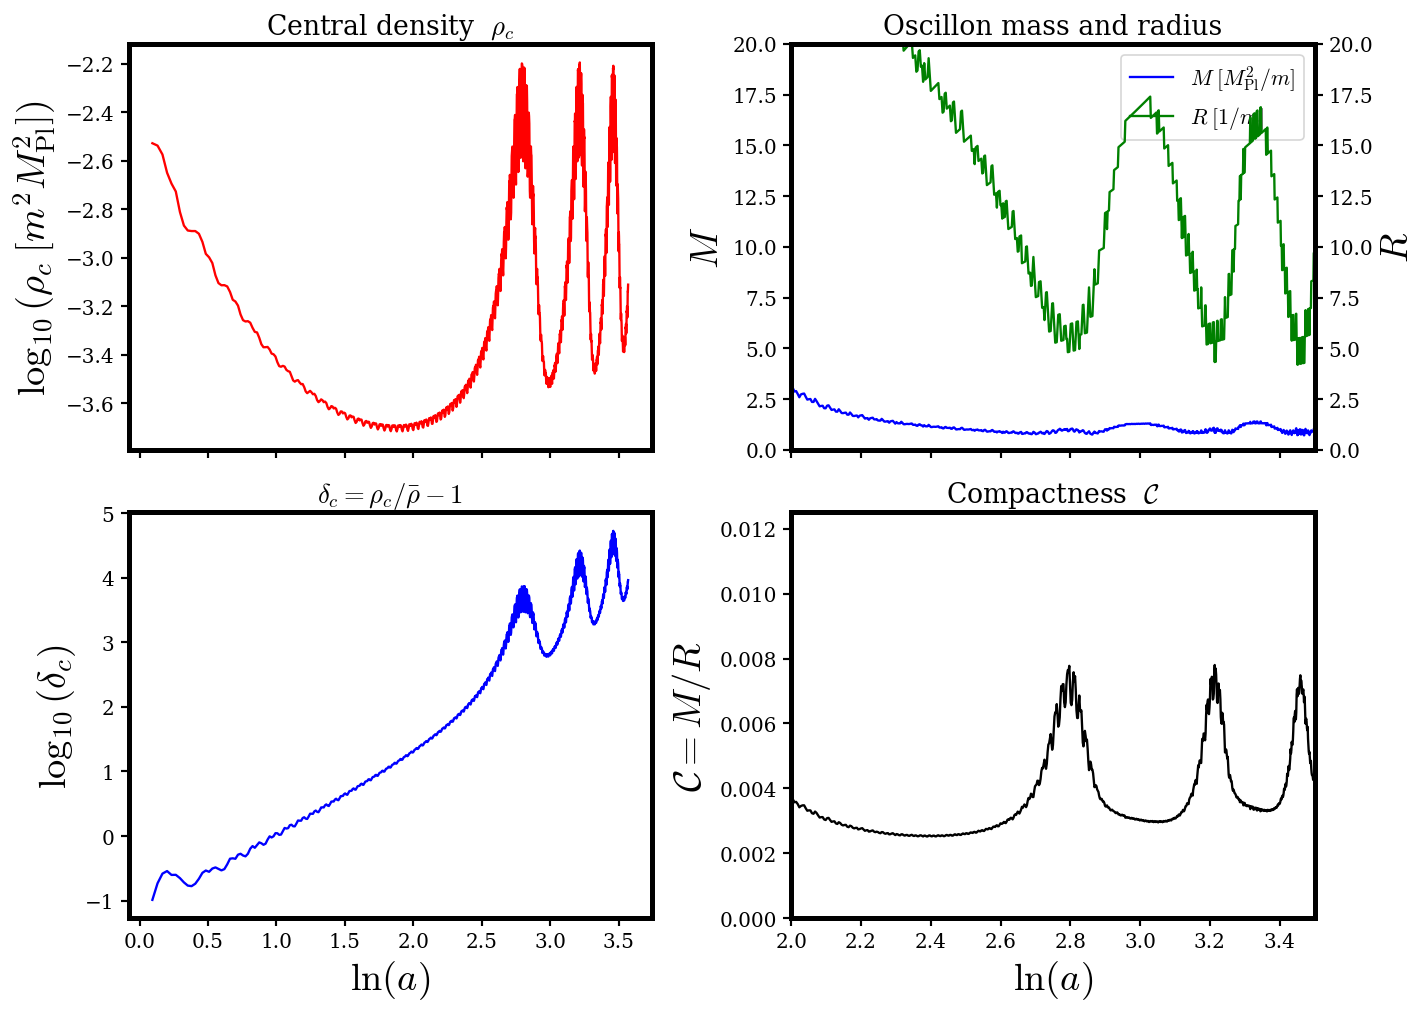

In [79]:
run = all_runs[PLOT2_KEY]
lgb_i, mu_i, beta_i, amp_i, width_i, g2_i = PLOT2_KEY

osc_shifted = {**run["osc"], "ln_a": run["shifted_ln_a"]}

# Custom 2x2 layout (re-arranged from plot_paper_diagnostics):
#   [0,0] log10(rho_c)   [0,1] M and R   (column 1 starts at ln(a)=2)
#   [1,0] log10(delta_c) [1,1] C         (column 1 starts at ln(a)=2)
# Columns share x via sharex='col' so stacked panels have identical x ranges.
x       = osc_shifted["ln_a"]
delta_c = osc_shifted["delta_c"]
rho_c   = osc_shifted["rho_c"]
M_arr   = osc_shifted["M"]
R_arr   = osc_shifted["R"]
C_arr   = osc_shifted["C"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex="col")

# [0,0] central density rho_c
ax = axes[0, 0]
pos_rho = rho_c > 0
y_rho = np.full_like(rho_c, np.nan)
y_rho[pos_rho] = np.log10(rho_c[pos_rho])
ax.plot(x, y_rho, "r-", lw=1.4)
ax.set_ylabel(r"$\log_{10}(\rho_c \; [m^2 M_{\rm Pl}^2])$")
ax.set_title(r"Central density  $\rho_c$")
#ax.grid(True, alpha=0.3)

# [0,1] oscillon mass and radius (starts at ln(a)=2)
ax_mr = axes[0, 1]
ax_mr.plot(x, M_arr, "b-", lw=1.4, label=r"$M \; [M_{\rm Pl}^2/m]$")
ax_mr_r = ax_mr.twinx()
ax_mr_r.plot(x, R_arr, "g-", lw=1.4, label=r"$R \; [1/m]$")
ax_mr.set_ylabel(r"$M$", color="black")
ax_mr_r.set_ylabel(r"$R$", color="black")
ax_mr_r.set_ylim(0,20)
ax_mr.set_ylim(0,20)
ax_mr.set_title("Oscillon mass and radius")
lines1, labels1 = ax_mr.get_legend_handles_labels()
lines2, labels2 = ax_mr_r.get_legend_handles_labels()
ax_mr.legend(lines1 + lines2, labels1 + labels2, fontsize=13, loc="best")
#ax_mr.grid(True, alpha=0.3)

# [1,0] density contrast delta_c
ax = axes[1, 0]
pos = delta_c > 0
y_d = np.full_like(delta_c, np.nan)
y_d[pos] = np.log10(delta_c[pos])
ax.plot(x, y_d, "b-", lw=1.4)
ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\log_{10}(\delta_c)$")
ax.set_title(r"$\delta_c = \rho_c / \bar\rho - 1$")
#ax.grid(True, alpha=0.3)

# [1,1] compactness C (starts at ln(a)=2)
ax = axes[1, 1]
ax.plot(x, C_arr, "k-", lw=1.4)
ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\mathcal{C} = M/R$")
ax.set_title(r"Compactness  $\mathcal{C}$")
ax.set_ylim(0, 1.25e-2)
#ax.grid(True, alpha=0.3)

# x-axis limits per column (column 1 starts at ln(a)=2). sharex='col' propagates.
axes[0, 1].set_xlim(2.0, 3.5)

beta_s = "linear" if beta_i is None else rf"\beta={int(beta_i)}"
"""
fig.suptitle(
    rf"$\lambda_{{\rm GB}}={lgb_i:g},\ \mu={mu_i},\ {beta_s},\ A={amp_i},\ R={width_i}$",
    fontsize=13,)
"""
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, PLOT2_NAME)
plt.show()

  saved MassRadiusCompactnessGR_3stack.pdf and MassRadiusCompactnessGR_3stack.png


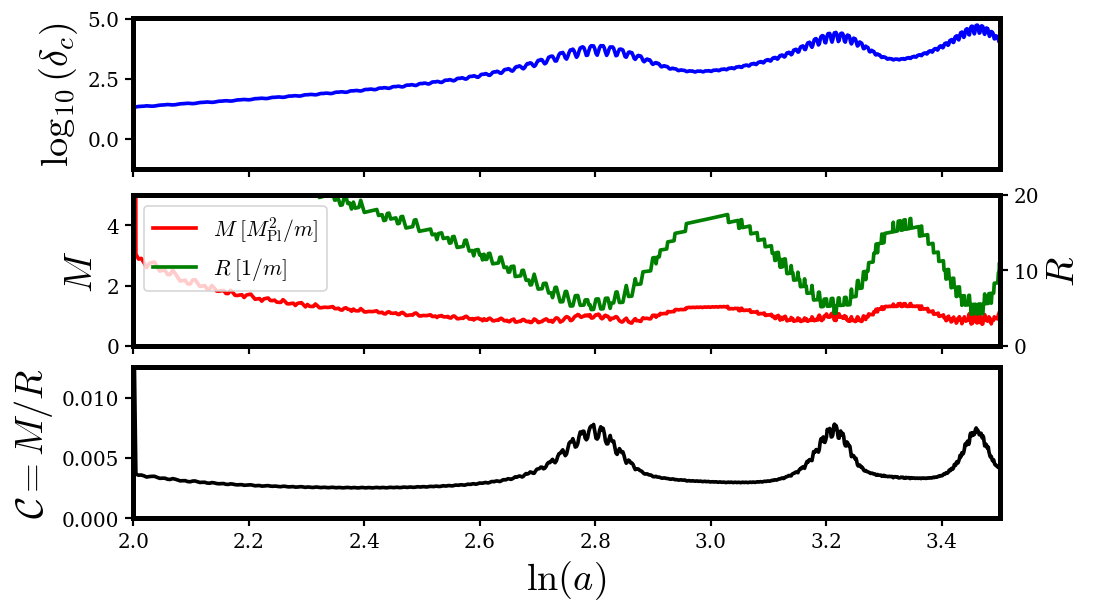

In [116]:
# Panel 2b — same data as Panel 2 (PLOT2_KEY), arranged as 3 stacked panels:
#   top:    log10(delta_c)   vs ln(a)
#   middle: M and R (twinx) vs ln(a)
#   bottom: compactness C    vs ln(a)
# All share x-range [0, 3.5]; vertical grey dotted line at ln(a)=2 marks
# the alignment / "oscillon formed" threshold.
x       = osc_shifted["ln_a"]
delta_c = osc_shifted["delta_c"]
M_arr   = osc_shifted["M"]
R_arr   = osc_shifted["R"]
C_arr   = osc_shifted["C"]

LNA_MIN, LNA_MAX = 2.0, 3.5
LNA_FORM         = 2.0

fig3, (ax_d, ax_mr, ax_c) = plt.subplots(
    3, 1, figsize=(9, 5), sharex=True, constrained_layout=True
)

pos_d = delta_c > 0
y_d   = np.full_like(delta_c, np.nan)
y_d[pos_d] = np.log10(delta_c[pos_d])
ax_d.plot(x, y_d, "b-", lw=2.2)
ax_d.set_ylabel(r"$\log_{10}(\delta_c)$")
#ax_d.set_title(r"$\delta_c = \rho_c / \bar\rho - 1$")


ax_mr.plot(x, M_arr, "r-", lw=2.2, label=r"$M \; [M_{\rm Pl}^2/m]$")
ax_mr_r = ax_mr.twinx()
ax_mr_r.plot(x, R_arr, "g-", lw=2.2, label=r"$R \; [1/m]$")
ax_mr.set_ylabel(r"$M$", color="black")
ax_mr_r.set_ylabel(r"$R$", color="black")
ax_mr.set_ylim(0, 5)
ax_mr_r.set_ylim(0, 20)
#ax_mr.set_title("Oscillon mass and radius")
lines1, labels1 = ax_mr.get_legend_handles_labels()
lines2, labels2 = ax_mr_r.get_legend_handles_labels()
ax_mr.legend(lines1 + lines2, labels1 + labels2,
             fontsize=13, loc="upper left")

ax_c.plot(x, C_arr, "k-", lw=2.2)
ax_c.set_xlabel(r"$\ln(a)$")
ax_c.set_ylabel(r"$\mathcal{C} = M/R$")
#ax_c.set_title(r"Compactness  $\mathcal{C}$")
ax_c.set_ylim(0, 1.25e-2)

for ax in (ax_d, ax_mr, ax_c):
    ax.axvline(LNA_FORM, color="grey", ls=":", lw=1.4, alpha=0.8)
    ax.set_xlim(LNA_MIN, LNA_MAX)

for ax in (ax_mr, ax_c):
    ax.axvspan(LNA_MIN, LNA_FORM, color="lightgrey", alpha=0.45, zorder=0)
    #ax.text(0.5 * (LNA_MIN + LNA_FORM),ax.get_ylim()[0] + 0.92 * (ax.get_ylim()[1] - ax.get_ylim()[0]),"oscillon not formed yet",ha="center", va="top",color="dimgrey", fontsize=13, style="italic")

save_fig(fig3, PLOT2_NAME + "_3stack")
plt.show()

  saved MassRadiusCompactnessGR_2stack.pdf and MassRadiusCompactnessGR_2stack.png


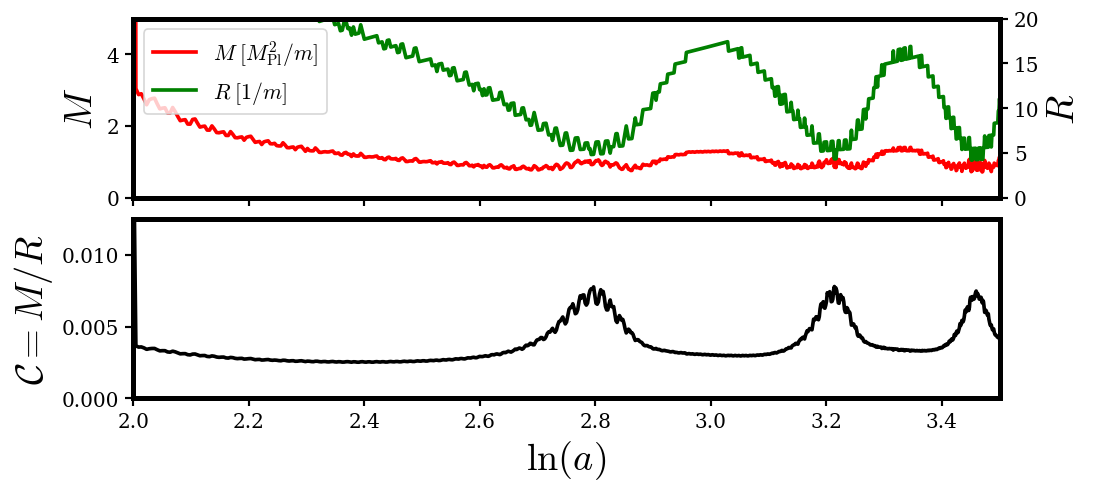

In [117]:
# Panel 2c — same as Panel 2b but with the top log10(delta_c) panel removed.
#   top:    M and R (twinx) vs ln(a)
#   bottom: compactness C    vs ln(a)
x       = osc_shifted["ln_a"]
M_arr   = osc_shifted["M"]
R_arr   = osc_shifted["R"]
C_arr   = osc_shifted["C"]

LNA_MIN, LNA_MAX = 2.0, 3.5
LNA_FORM         = 2.0

fig4, (ax_mr, ax_c) = plt.subplots(
    2, 1, figsize=(9, 4), sharex=True, constrained_layout=True
)

ax_mr.plot(x, M_arr, "r-", lw=2.2, label=r"$M \; [M_{\rm Pl}^2/m]$")
ax_mr_r = ax_mr.twinx()
ax_mr_r.plot(x, R_arr, "g-", lw=2.2, label=r"$R \; [1/m]$")
ax_mr.set_ylabel(r"$M$", color="black")
ax_mr_r.set_ylabel(r"$R$", color="black")
ax_mr.set_ylim(0, 5)
ax_mr_r.set_ylim(0, 20)
lines1, labels1 = ax_mr.get_legend_handles_labels()
lines2, labels2 = ax_mr_r.get_legend_handles_labels()
ax_mr.legend(lines1 + lines2, labels1 + labels2,
             fontsize=13, loc="upper left")

ax_c.plot(x, C_arr, "k-", lw=2.2)
ax_c.set_xlabel(r"$\ln(a)$")
ax_c.set_ylabel(r"$\mathcal{C} = M/R$")
ax_c.set_ylim(0, 1.25e-2)

for ax in (ax_mr, ax_c):
    ax.axvline(LNA_FORM, color="grey", ls=":", lw=1.4, alpha=0.8)
    ax.set_xlim(LNA_MIN, LNA_MAX)
    ax.axvspan(LNA_MIN, LNA_FORM, color="lightgrey", alpha=0.45, zorder=0)

save_fig(fig4, PLOT2_NAME + "_2stack")
plt.show()

## Panel 3 — Central vs background density (decoupling from the Hubble flow)

For each selected run, $\log_{10}\rho_c$ (solid) and $\log_{10}\bar\rho$ (dashed) vs aligned $\ln(a)$.
Where $\rho_c$ stops tracking $\bar\rho$ the configuration has decoupled from the Hubble flow.

In [95]:
### --- Panel 3 selection (edit me) ---
PLOT3_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2 = [0]
)
PLOT3_NAME = "rho_c_vs_rho_bar"

print(f"{len(PLOT3_KEYS)} run(s) selected for Panel 3:")
for k in PLOT3_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"])

1 run(s) selected for Panel 3:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0


  saved rho_c_vs_rho_bar.pdf and rho_c_vs_rho_bar.png


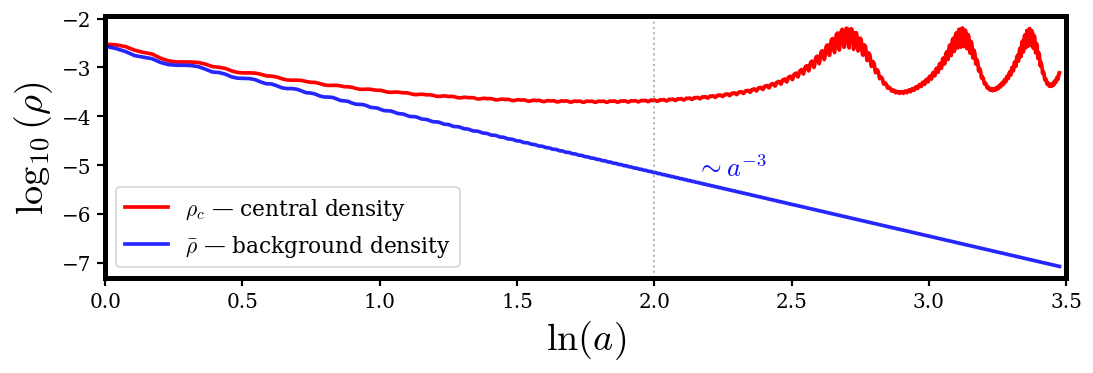

In [96]:
fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)
cmap = plt.cm.tab10
single_run = (len(PLOT3_KEYS) == 1)

for i, key in enumerate(PLOT3_KEYS):
    data = all_runs[key]
    osc  = data["osc"]
    lgb, mu, beta, amp, width, g2 = key

    if "rho_bar" not in osc:
        print(f"  skipping {key}: rho_bar not in diagnostics")
        continue

    #ln_a = data["shifted_ln_a"]
    ln_a = np.asarray(data["osc"]["ln_a"]) #WE USED THE RAW LN(A) FOR GR SINCE THE SHIFTING IS ONLY NEEDED IN MG

    rc   = np.asarray(osc["rho_c"])
    rb   = np.asarray(osc["rho_bar"])

    pos_c = rc >= 0
    pos_b = rb >= 0

    if single_run:
        color_c, color_b = "r", "b"
        lbl_c = r"$\rho_c$ — central density"
        lbl_b = r"$\bar{\rho}$ — background density"
    else:
        color_c = cmap(i % 10)
        color_b = color_c
        beta_s  = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        if lgb == 0.0:
            run_lbl = rf"GR, $\mu={mu}$"
        else:
            run_lbl = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"
        lbl_c = rf"$\rho_c$ (central density) ({run_lbl})"
        lbl_b = rf"$\bar\rho$ (background density) ({run_lbl})"

    ax.plot(ln_a[pos_c], np.log10(rc[pos_c]),color=color_c, lw=2.2, label=lbl_c)
    ax.plot(ln_a[pos_b], np.log10(rb[pos_b]),color=color_b, lw=2.2, ls="-", alpha=0.85, label=lbl_b)

ln_a_ref = np.linspace(1.5, 2.5, 100)
anchor_x = ln_a_ref[0] +2.4
log_rho_anchor = np.interp(anchor_x, ln_a[pos_b], np.log10(rb[pos_b]))
log_rho_ref = log_rho_anchor - 3.0 * (ln_a_ref - anchor_x) / np.log(10)
#ax.plot(ln_a_ref, log_rho_ref,color="black", ls="--", lw=1.5, alpha=0.9)

txt_x = ln_a_ref[len(ln_a_ref) // 2]+0.1
txt_y = -5.5#log_rho_anchor - 3.0 * (txt_x - anchor_x) / np.log(10)
ax.annotate(r"$\sim a^{-3}$",
            xy=(txt_x, txt_y),
            xytext=(8, 8), textcoords="offset points",
            color="blue", fontsize=16, alpha=0.95)

ax.axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)

ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\log_{10}(\rho)$")
ax.set_xlim(0,3.5)
#ax.set_title(r"Central density $\rho_c$ vs background $\bar{\rho}$")
ax.legend(fontsize=13, loc="best", frameon=True)
save_fig(fig, PLOT3_NAME)
plt.show()

---
## Further panels

Future panels follow the same two-cell pattern:

- **Selection cell** — set parameter lists and a `*_NAME` string used for the PDF filename.
- **Plot cell** — build the figure, then `save_fig(fig, NAME); plt.show()` so it is shown
  inline and saved to `GoodFigures/NAME.pdf` (with a `.png` mirror).

## Panel 5 — Density contrast $\delta_c$: with vs without backreaction

Compares $\log_{10}(\delta_c)$ vs $\ln(a)$ for the **same** physical setup
( $\mu = 0.08$, $\lambda_{\rm GB} = 0$, $g_2 = 0$, $a_{\rm mg}=b_{\rm mg}=0$,
$A=-0.02$, $R=3$, $\mathrm{d}r=1/24$, $T=800$ ) with two different gravity settings:

- **With backreaction**: `eight_pi_G = 1` in `bssn/tensoralgebra.py` (the existing run).
- **Without backreaction**: `eight_pi_G = 0` (the run currently submitted to wICE).
  This effectively evolves the scalar on a fixed FLRW background, mirroring what a
  linear / fixed-background code computes.

The black dashed line shows the matter-domination linear growth $\delta_c \propto a$
(slope $\log_{10}(e) \approx 0.4343$ in this plane), anchored to the no-BR curve's
first positive value.

Both runs are loaded directly from disk (not from `all_runs`), because the
notebook's loader keys on `(\lambda_{GB}, \mu, \beta, A, R, g_2)` and both runs collide
to the same key — only their `coupling` string differs (`"quadratic"` vs
`"quadratic_0_noBR"`).

with backreaction:
  dir          : /data/leuven/384/vsc38419/oscillon_runs/lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  solution.npy : True
  diagnostics  : True
no backreaction:
  dir          : /data/leuven/384/vsc38419/oscillon_runs/lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_noBR_g20
  solution.npy : True
  diagnostics  : True
  saved delta_c_with_vs_no_backreaction_mu0.08_amp-0.02.pdf and delta_c_with_vs_no_backreaction_mu0.08_amp-0.02.png


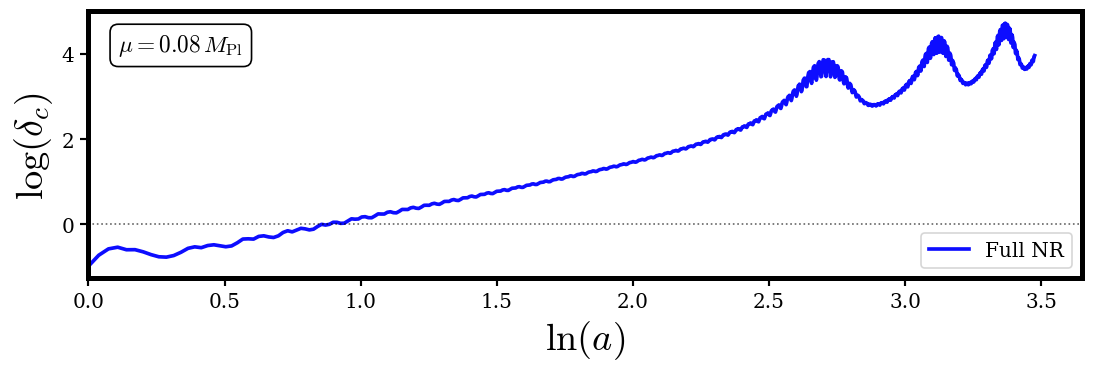

In [97]:
# ── Panel 5 selection (edit me if you change run parameters) ──────────────
# Pick ONE pair below by commenting/uncommenting.  Both pairs share the same
# physical parameters (mu=0.08, lgb=0, g2=0, a=b=0, R=3, dr=1/24, T=800);
# they only differ in the initial perturbation amplitude A.

# --- A = -0.02 ---
NOBR_TAG    = "lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_noBR_g20"
WITHBR_TAG  = "lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20"
P5_NAME     = "delta_c_with_vs_no_backreaction_mu0.08_amp-0.02"

# --- A = -0.0002 ---
#NOBR_TAG    = "lgb0_mu0.08_a0_b0_amp-0.0002_R3_dr0.0416667_quadratic_0_noBR_g20"
#WITHBR_TAG  = "lgb0_mu0.08_a0_b0_amp-0.0002_R3_dr0.0416667_quadratic_g20"
#P5_NAME     = "delta_c_with_vs_no_backreaction_mu0.08_amp-0.0002"

# Physical parameters (must match the runs above)
P5_LGB, P5_MU, P5_G2 = 0.0, 0.08, 0.0
P5_COUPLING_NOBR    = "quadratic_0_noBR"
P5_COUPLING_WITHBR  = "quadratic"


def _p5_load_or_compute_diag(run_dir, mu, coupling, lgb, g2):
    """Load diagnostics.npz from `run_dir`; compute if missing but solution.npy exists.
    Returns None if the simulation hasn't produced solution.npy yet.
    """
    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        return dict(np.load(diag_path, allow_pickle=True))

    sol_path = os.path.join(run_dir, "solution.npy")
    t_path   = os.path.join(run_dir, "t.npy")
    if not (os.path.exists(sol_path) and os.path.exists(t_path)):
        return None

    meta_path = os.path.join(run_dir, "metadata.npz")
    if os.path.exists(meta_path):
        meta = dict(np.load(meta_path, allow_pickle=True))
        run_r_max  = float(meta.get("r_max",  r_max))
        run_min_dr = float(meta.get("min_dr", 1/24))
        run_max_dr = float(meta.get("max_dr", max_dr))
    else:
        run_r_max, run_min_dr, run_max_dr = r_max, 1/24, max_dr

    sol_i   = np.load(sol_path)
    t_i     = np.load(t_path)
    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)
    params_i  = (lgb, a_mg, b_mg, chi0, coupling, g2)
    osc_d = get_oscillon_diagnostic(
        sol_i, t_i, grid_i, bg_i,
        ScalarMatter(scalar_mu, mu),
        params_i, surface_threshold=0.05, r_max_diag=100.0,
    )
    np.savez(diag_path, **osc_d)
    return osc_d


nobr_dir   = os.path.join(DATA_DIR, NOBR_TAG)
withbr_dir = os.path.join(DATA_DIR, WITHBR_TAG)

print("with backreaction:")
print(f"  dir          : {withbr_dir}")
print(f"  solution.npy : {os.path.exists(os.path.join(withbr_dir, 'solution.npy'))}")
print(f"  diagnostics  : {os.path.exists(os.path.join(withbr_dir, 'diagnostics.npz'))}")
print("no backreaction:")
print(f"  dir          : {nobr_dir}")
print(f"  solution.npy : {os.path.exists(os.path.join(nobr_dir,  'solution.npy'))}")
print(f"  diagnostics  : {os.path.exists(os.path.join(nobr_dir,  'diagnostics.npz'))}")

osc_with = _p5_load_or_compute_diag(withbr_dir, mu=P5_MU, coupling=P5_COUPLING_WITHBR,
                                     lgb=P5_LGB, g2=P5_G2)
osc_no   = _p5_load_or_compute_diag(nobr_dir,   mu=P5_MU, coupling=P5_COUPLING_NOBR,
                                     lgb=P5_LGB, g2=P5_G2)

if osc_with is None:
    print("\n[warn] with-backreaction run has no solution.npy yet — plot will be empty for that curve.")
if osc_no is None:
    print("\n[info] no-backreaction run has not produced solution.npy yet "
          "(simulation still in progress). Only the with-backreaction curve will be drawn.")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)

def _plot_logdelta(ax, osc, color, ls, lw, label, x_override=None):
    if osc is None:
        return
    ln_a = x_override if x_override is not None else np.asarray(osc["ln_a"])
    dc   = np.asarray(osc["delta_c"])
    pos = (dc > 0) & np.isfinite(dc)
    if not np.any(pos):
        return
    y = np.full_like(dc, np.nan, dtype=float)
    y[pos] = np.log10(dc[pos])
    ax.plot(ln_a, y, color=color, ls=ls, lw=lw, label=label, alpha=0.95)

# ── X-axis mode ───────────────────────────────────────────────────────────
# Toggle: "t" = coordinate time,  "ln_a" = with-BR ln(a) for both curves
#P5_XAXIS = "t"
P5_XAXIS = "ln_a"

if P5_XAXIS == "t":
    x_with = np.asarray(osc_with["t"]) if osc_with is not None else None
    x_no   = np.asarray(osc_no["t"])   if osc_no   is not None else None
    p5_xlabel = r"$t \; [1/m]$"
else:
    x_with = np.asarray(osc_with["ln_a"]) if osc_with is not None else None
    x_no   = x_with
    p5_xlabel = r"$\ln(a)$"

_plot_logdelta(ax, osc_with, color="blue", ls="-",  lw=2.2, label="Full NR",x_override=x_with)
#_plot_logdelta(ax, osc_no,   color="red",  ls="-", lw=2.2, label="no backreaction",x_override=x_no)

ax.axhline(0.0, color="k", ls=":", lw=1.0, alpha=0.6)

ax.set_xlabel(p5_xlabel)
ax.set_ylabel(r"$\log(\delta_c)$")
ax.set_xlim(left=0.0)
ax.legend(loc="lower right", frameon=True, fontsize=12)

ax.text(0.03, 0.92, rf"$\mu = {P5_MU:g}\,M_{{\rm Pl}}$",
        transform=ax.transAxes, fontsize=14, ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", lw=1.0))

save_fig(fig, P5_NAME)
plt.show()

## Panel 3+5 — Stacked $\rho_c, \bar\rho$ and $\delta_c$ vs $\ln(a)$

Combined view of Panel 3 (central vs background density) on top and Panel 5
(density contrast with backreaction) on the bottom, sharing the same
$\ln(a)$ axis.

Requires Panel 3 and Panel 5 cells above to have been executed so that
`PLOT3_KEYS`, `all_runs`, `osc_with`, `P5_MU`, and `ALIGN_LNA` are in scope.

In [24]:
P35_NAME = "rho_and_delta_c_stacked"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(9, 6), sharex=True, constrained_layout=True
)

if osc_with is not None:
    ln_a_w = np.asarray(osc_with["ln_a"])
    dc     = np.asarray(osc_with["delta_c"])
    pos    = (dc > 0) & np.isfinite(dc)
    y      = np.full_like(dc, np.nan, dtype=float)
    y[pos] = np.log10(dc[pos])
    ax_top.plot(ln_a_w, y, color="blue", lw=2.2, label="Full NR", alpha=0.95)
else:
    print("[warn] osc_with is None — top panel will be empty. Run Panel 5 first.")

ax_top.axhline(0.0, color="k",    ls=":", lw=1.0, alpha=0.6)
ax_top.axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
ax_top.set_ylabel(r"$\log_{10}(\delta_c)$")
ax_top.legend(loc="lower right", frameon=True, fontsize=12)

ax_top.text(0.03, 0.92, rf"$\mu = {P5_MU:g}\,M_{{\rm Pl}}$",
            transform=ax_top.transAxes, fontsize=14, ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", lw=1.0))

cmap = plt.cm.tab10
single_run = (len(PLOT3_KEYS) == 1)
last_ln_a_b = None
last_log_rb_b = None

for i, key in enumerate(PLOT3_KEYS):
    data = all_runs[key]
    osc  = data["osc"]
    lgb, mu, beta, amp, width, g2 = key

    if "rho_bar" not in osc:
        print(f"  skipping {key}: rho_bar not in diagnostics")
        continue

    ln_a = np.asarray(osc["ln_a"])
    rc   = np.asarray(osc["rho_c"])
    rb   = np.asarray(osc["rho_bar"])

    pos_c = rc >= 0
    pos_b = rb >= 0

    if single_run:
        color_c, color_b = "r", "b"
        lbl_c = r"$\rho_c$ — central density"
        lbl_b = r"$\bar{\rho}$ — background density"
    else:
        color_c = cmap(i % 10)
        color_b = color_c
        beta_s  = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        if lgb == 0.0:
            run_lbl = rf"GR, $\mu={mu}$"
        else:
            run_lbl = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"
        lbl_c = rf"$\rho_c$ ({run_lbl})"
        lbl_b = rf"$\bar\rho$ ({run_lbl})"

    ax_bot.plot(ln_a[pos_c], np.log10(rc[pos_c]), color=color_c, lw=2.2, label=lbl_c)
    ax_bot.plot(ln_a[pos_b], np.log10(rb[pos_b]), color=color_b, lw=2.2,
                ls="-", alpha=0.85, label=lbl_b)

    last_ln_a_b   = ln_a[pos_b]
    last_log_rb_b = np.log10(rb[pos_b])

ax_bot.axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
ax_bot.set_xlabel(r"$\ln(a)$")
ax_bot.set_ylabel(r"$\log_{10}(\rho)$")
ax_bot.legend(fontsize=11, loc="best", frameon=True)

if last_ln_a_b is not None and last_ln_a_b.size:
    ln_a_ref = np.linspace(1.5, 2.5, 100)
    anchor_x = ln_a_ref[0] + 2.4
    txt_x = ln_a_ref[len(ln_a_ref) // 2] + 0.1
    txt_y = -5.5
    ax_bot.annotate(r"$\sim a^{-3}$",
                    xy=(txt_x, txt_y),
                    xytext=(8, 8), textcoords="offset points",
                    color="blue", fontsize=16, alpha=0.95)

ax_bot.set_xlim(0.0, 3.5)

save_fig(fig, P35_NAME)
plt.show()

NameError: name 'osc_with' is not defined

## Panel 6 — Density-contrast profile $\delta(r)$

Snapshot plot of the spatial density-contrast profile

$$\delta(r,\, t) \;=\; \frac{\rho(r,\, t)}{\bar\rho(t)} \;-\; 1$$

against the radial coordinate $r$, evaluated at a set of aligned $\ln(a)$
snapshots.  This is the radial generalisation of the central density
contrast $\delta_c = \rho_c / \bar\rho - 1$ used in the earlier panels;
note that $\delta(r=0,\, t) \equiv \delta_c(t)$, so each curve passes
through $\delta_c$ on the y-axis at $r=0$.

Two display modes are available:

* `PLOT6_USE_OSC_RADIUS = False` — x-axis is the **physical radial coordinate**
  $r\,[1/m]$, capped at `PLOT6_R_MAX`.
* `PLOT6_USE_OSC_RADIUS = True`  — x-axis is **rescaled by the time-dependent
  oscillon radius** $R_{\rm osc}(t)$, i.e. $r/R_{\rm osc}(t)$, capped at
  `PLOT6_X_NORM_MAX`.  In this mode the oscillon "edge" sits at
  $r/R_{\rm osc}=1$ (marked with a thin grey dotted vertical line) and
  self-similar profiles collapse onto each other.

Edit `PLOT6_KEY`, `PLOT6_SNAPS`, `PLOT6_USE_OSC_RADIUS`, `PLOT6_R_MAX`,
`PLOT6_X_NORM_MAX` and `PLOT6_NAME` below.


In [25]:
PLOT6_KEY    = (0, 0.08, 0, -0.02, 3.0, 0)
#PLOT6_SNAPS  = [2.0, 2.25, 2.5, 3]
PLOT6_SNAPS  = [2.0,2.1,2.15,2.2, 2.25,2.3,2.35,2.4,2.45, 2.5,2.55,2.6,2.65]

PLOT6_USE_OSC_RADIUS = False
PLOT6_R_MAX          = 3
PLOT6_X_NORM_MAX     = 5.0

PLOT6_NAME   = "delta_profile_lgb0_mu0.08_amp-0.02"

if PLOT6_KEY not in all_runs:
    print(f"Key {PLOT6_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys()):
        print(f"  {k}  coupling={all_runs[k]['coupling']}")
else:
    print(f"Selected: {PLOT6_KEY}")
    print(f"  tag      = {all_runs[PLOT6_KEY]['tag']}")
    print(f"  coupling = {all_runs[PLOT6_KEY]['coupling']}")
    print(f"  shift    = {all_runs[PLOT6_KEY]['shift']:+.3f}")


Selected: (0, 0.08, 0, -0.02, 3.0, 0)
  tag      = lgb0.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0
  coupling = quadratic_0
  shift    = +0.093


  saved delta_profile_lgb0_mu0.08_amp-0.02.pdf and delta_profile_lgb0_mu0.08_amp-0.02.png


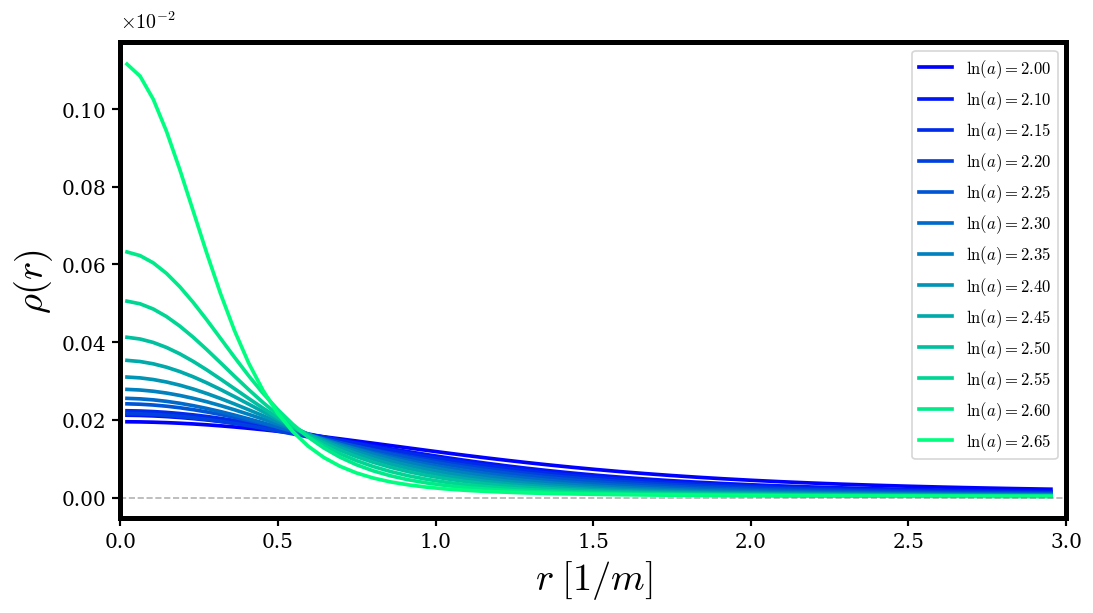

In [37]:
run    = all_runs[PLOT6_KEY]
osc    = run["osc"]
r_grid = np.asarray(osc["r"])
s_ln_a = np.asarray(run["shifted_ln_a"])

if "delta_rho" in osc:
    #delta_rho = np.asarray(osc["delta_rho"])
    delta_rho = np.asarray(osc["rho"])
else:
    rho     = np.asarray(osc["rho"])
    rho_bar = np.asarray(osc["rho_bar"])
    delta_rho = rho / np.maximum(rho_bar[:, None], 1e-30) - 1.0

R_osc_t = np.asarray(osc["R"])

snap_indices = [int(np.argmin(np.abs(s_ln_a - v))) for v in PLOT6_SNAPS]

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
cmap = plt.cm.winter
n    = len(snap_indices)

for j, idx in enumerate(snap_indices):
    color   = cmap(j / max(n - 1, 1))
    lna_val = s_ln_a[idx]
    delta_r = delta_rho[idx]

    if PLOT6_USE_OSC_RADIUS:
        R_osc = R_osc_t[idx]
        if R_osc <= 0:
            print(f"Skipping ln(a)={lna_val:.2f}: R_osc = {R_osc:.3g} (no oscillon yet)")
            continue
        x      = r_grid / R_osc
        x_mask = (r_grid >= 0) & (x <= PLOT6_X_NORM_MAX)
        lbl    = rf"$\ln(a) = {lna_val:.2f},\ R_{{\rm osc}} = {R_osc:.2f}$"
    else:
        x      = r_grid
        x_mask = (r_grid >= 0) & (r_grid <= PLOT6_R_MAX)
        lbl    = rf"$\ln(a) = {lna_val:.2f}$"

    ax.plot(x[x_mask], delta_r[x_mask],color=color, lw=2.2, label=lbl)

ax.axhline(0.0, color="grey", ls="--", lw=1.0, alpha=0.6)

if PLOT6_USE_OSC_RADIUS:
    ax.axvline(1.0, color="grey", ls=":", lw=1.2, alpha=0.7)
    ax.set_xlabel(r"$r / R_{\rm osc}(t)$")
    ax.set_xlim(0, PLOT6_X_NORM_MAX)
    save_suffix = "_vs_rOverR"
else:
    ax.set_xlabel(r"$r \; [1/m]$")
    ax.set_xlim(0, PLOT6_R_MAX)
    save_suffix = ""

#ax.set_ylabel(r"$\delta_c(r)$")
ax.set_ylabel(r"$\rho(r)$")

from matplotlib.ticker import FuncFormatter
_Y_SCALE = 1e-2
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _pos: f"{v / _Y_SCALE:.2f}"))
ax.annotate(r"$\times 10^{-2}$", xy=(0, 1), xycoords="axes fraction",
            xytext=(0, 6), textcoords="offset points",
            ha="left", va="bottom", fontsize=12)

ax.legend(fontsize=10, loc="best", frameon=True)
save_fig(fig, PLOT6_NAME + save_suffix)
plt.show()


## Panel 7 — 2D density-contrast slice $\delta(x, y)$

Renders the spherically-symmetric radial profile $\delta(r,\, t)$ as a 2D
heatmap on the $(x, y)$ plane by rotating it around the origin:

$$\delta(x, y) \;=\; \delta\!\bigl(\sqrt{x^2 + y^2},\, t\bigr).$$

This visualisation gives a "2D-slice" feel for a strictly 1D run; because
the underlying data is radial, the resulting image is necessarily
*concentric* (a single bullseye rather than several oscillons floating
around like in a true 2D/3D simulation).

The snapshot is picked by setting `PLOT7_LNA` to a value of (aligned)
$\ln(a)$ — the plot cell snaps to the closest available simulation
snapshot.

Edit `PLOT7_KEY`, `PLOT7_LNA`, `PLOT7_X_MAX`, `PLOT7_NPIX`, `PLOT7_CMAP`,
`PLOT7_VMIN`, `PLOT7_VMAX` and `PLOT7_NAME` below.

In [38]:
PLOT7_KEY   = (0, 0.08, 0, -0.02, 3.0, 0)
PLOT7_LNA   = 2.5
PLOT7_X_MAX = 1.5
PLOT7_NPIX  = 400
PLOT7_CMAP  = "jet"
PLOT7_VMIN  = None
PLOT7_VMAX  = None
PLOT7_NAME  = "delta_2D_lgb0_mu0.08_amp-0.02"

if PLOT7_KEY not in all_runs:
    print(f"Key {PLOT7_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys()):
        print(f"  {k}  coupling={all_runs[k]['coupling']}")
else:
    s_ln_a_tmp = np.asarray(all_runs[PLOT7_KEY]["shifted_ln_a"])
    idx_tmp    = int(np.argmin(np.abs(s_ln_a_tmp - PLOT7_LNA)))
    print(f"Selected: {PLOT7_KEY}")
    print(f"  tag                    = {all_runs[PLOT7_KEY]['tag']}")
    print(f"  shift                  = {all_runs[PLOT7_KEY]['shift']:+.3f}")
    print(f"  requested ln(a)        = {PLOT7_LNA}")
    print(f"  closest snapshot ln(a) = {s_ln_a_tmp[idx_tmp]:.3f}  (idx={idx_tmp})")

Selected: (0, 0.08, 0, -0.02, 3.0, 0)
  tag                    = lgb0.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0
  shift                  = +0.093
  requested ln(a)        = 2.5
  closest snapshot ln(a) = 2.501  (idx=311)


  saved delta_2D_lgb0_mu0.08_amp-0.02_lna2p50.pdf and delta_2D_lgb0_mu0.08_amp-0.02_lna2p50.png


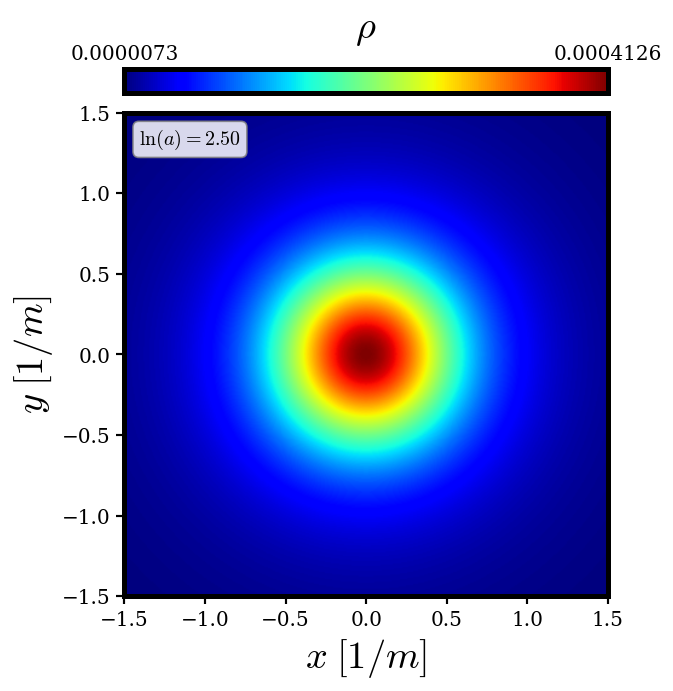

In [41]:
run    = all_runs[PLOT7_KEY]
osc    = run["osc"]
r_grid = np.asarray(osc["r"])
s_ln_a = np.asarray(run["shifted_ln_a"])

if "delta_rho" in osc:
    delta_rho = np.asarray(osc["rho"])
    #delta_rho = np.asarray(osc["rho"])
else:
    rho     = np.asarray(osc["rho"])
    rho_bar = np.asarray(osc["rho_bar"])
    delta_rho = rho / np.maximum(rho_bar[:, None], 1e-30) - 1.0

idx     = int(np.argmin(np.abs(s_ln_a - PLOT7_LNA)))
lna_val = s_ln_a[idx]
prof    = delta_rho[idx]

order    = np.argsort(r_grid)
r_sorted = r_grid[order]
p_sorted = prof[order]

n  = PLOT7_NPIX
xs = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
ys = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
X, Y = np.meshgrid(xs, ys)
R    = np.sqrt(X**2 + Y**2)

delta_2d = np.interp(R, r_sorted, p_sorted,
                     left=p_sorted[0], right=0.0)

vmin = float(np.nanmin(delta_2d)) if PLOT7_VMIN is None else PLOT7_VMIN
vmax = float(np.nanmax(delta_2d)) if PLOT7_VMAX is None else PLOT7_VMAX

fig, ax = plt.subplots(figsize=(5.5, 6.0), constrained_layout=True)
im = ax.imshow(
    delta_2d,
    extent=[-PLOT7_X_MAX, PLOT7_X_MAX, -PLOT7_X_MAX, PLOT7_X_MAX],
    origin="lower",
    cmap=PLOT7_CMAP,
    vmin=vmin, vmax=vmax,
    #vmin=vmin, vmax=200,
    aspect="equal",
    interpolation="bilinear",
)

ax.set_xlabel(r"$x \; [1/m]$")
ax.set_ylabel(r"$y \; [1/m]$")

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", location="top",
                    fraction=0.05, pad=0.02)
cbar.set_label(r"$\rho$")
cbar.set_ticks([vmin, vmax])
#cbar.set_ticks([vmin, 200])
cbar.ax.tick_params(direction="in")

ax.text(0.03, 0.97, rf"$\ln(a) = {lna_val:.2f}$",
        transform=ax.transAxes, va="top", ha="left", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", alpha=0.85, edgecolor="grey"))

save_fig(fig, PLOT7_NAME + f"_lna{lna_val:.2f}".replace(".", "p"))
plt.show()

  saved delta_2D_lgb0_mu0.08_amp-0.02_3d_lna2p50.pdf and delta_2D_lgb0_mu0.08_amp-0.02_3d_lna2p50.png


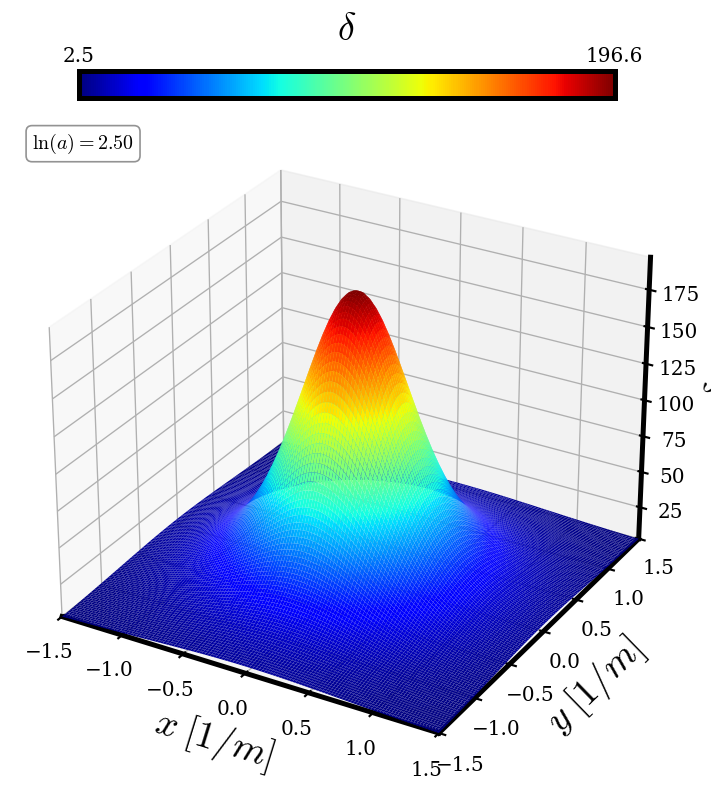

In [40]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

run    = all_runs[PLOT7_KEY]
osc    = run["osc"]
r_grid = np.asarray(osc["r"])
s_ln_a = np.asarray(run["shifted_ln_a"])

if "delta_rho" in osc:
    delta_rho = np.asarray(osc["delta_rho"])
else:
    rho     = np.asarray(osc["rho"])
    rho_bar = np.asarray(osc["rho_bar"])
    delta_rho = rho / np.maximum(rho_bar[:, None], 1e-30) - 1.0

idx     = int(np.argmin(np.abs(s_ln_a - PLOT7_LNA)))
lna_val = s_ln_a[idx]
prof    = delta_rho[idx]

order    = np.argsort(r_grid)
r_sorted = r_grid[order]
p_sorted = prof[order]

n  = PLOT7_NPIX
xs = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
ys = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
X, Y = np.meshgrid(xs, ys)
R    = np.sqrt(X**2 + Y**2)

delta_2d = np.interp(R, r_sorted, p_sorted,
                     left=p_sorted[0], right=0.0)

vmin = float(np.nanmin(delta_2d)) if PLOT7_VMIN is None else PLOT7_VMIN
vmax = float(np.nanmax(delta_2d)) if PLOT7_VMAX is None else PLOT7_VMAX

stride = max(1, n // 120)

fig = plt.figure(figsize=(7.0, 6.5), constrained_layout=True)
ax  = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X, Y, delta_2d,
    cmap=PLOT7_CMAP,
    vmin=vmin, vmax=vmax,
    rstride=stride, cstride=stride,
    linewidth=0, antialiased=True,
)

ax.set_xlabel(r"$x \; [1/m]$", labelpad=8)
ax.set_ylabel(r"$y \; [1/m]$", labelpad=8)
ax.set_zlabel(r"$\delta$",     labelpad=8)
ax.set_xlim(-PLOT7_X_MAX, PLOT7_X_MAX)
ax.set_ylim(-PLOT7_X_MAX, PLOT7_X_MAX)
ax.set_zlim(vmin, vmax)
ax.view_init(elev=28, azim=-60)

cbar = fig.colorbar(surf, ax=ax, orientation="horizontal", location="top",
                    fraction=0.04, pad=0.02, shrink=0.7)
cbar.set_label(r"$\delta$")
cbar.set_ticks([vmin, vmax])
cbar.ax.tick_params(direction="in")

ax.text2D(0.03, 0.97, rf"$\ln(a) = {lna_val:.2f}$",
          transform=ax.transAxes, va="top", ha="left", fontsize=12,
          bbox=dict(boxstyle="round,pad=0.3",
                    facecolor="white", alpha=0.85, edgecolor="grey"))

save_fig(fig, PLOT7_NAME + f"_3d_lna{lna_val:.2f}".replace(".", "p"))
plt.show()

  saved panel8_radial_and_2DD_lna2p50.pdf and panel8_radial_and_2DD_lna2p50.png


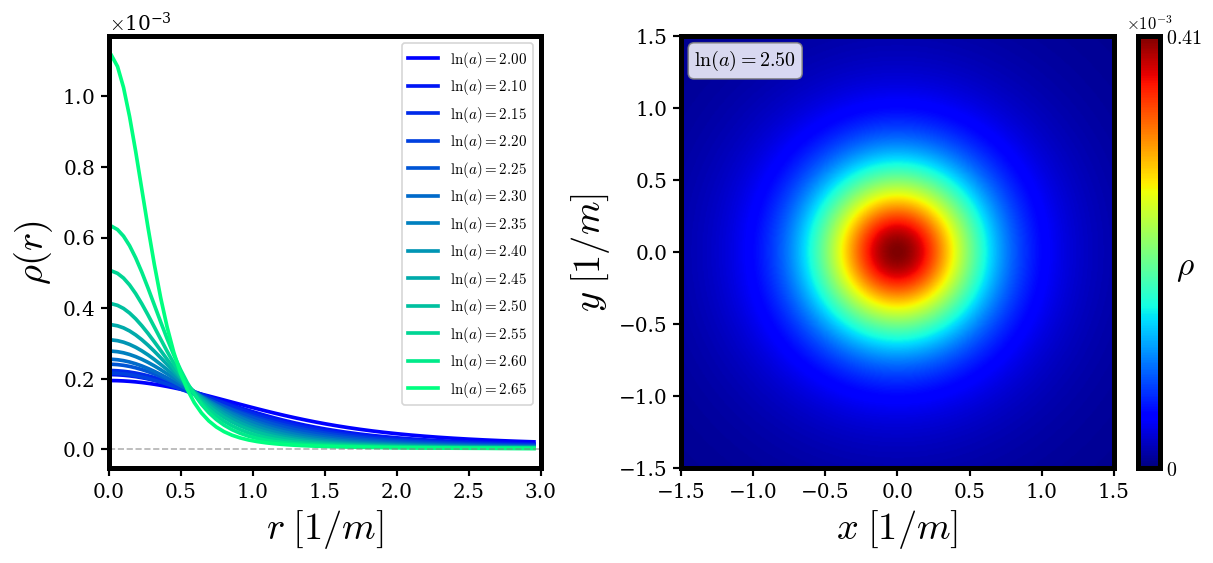

In [54]:
# Panel 8 — combined view: radial profiles (left) + rotated 2D slice (right).
# Uses the existing PLOT6_* and PLOT7_* selection variables, so re-run the
# Panel 6 and Panel 7 selection cells first if you change the parameters.

# ── Left-panel data: radial rho(r) profiles at PLOT6_SNAPS ─────────────────
run6    = all_runs[PLOT6_KEY]
osc6    = run6["osc"]
r6      = np.asarray(osc6["r"])
ln_a6   = np.asarray(run6["shifted_ln_a"])
field6  = np.asarray(osc6["rho"])
field6_label = r"$\rho(r)$"
R_osc_t6     = np.asarray(osc6["R"])
snap_idx6    = [int(np.argmin(np.abs(ln_a6 - v))) for v in PLOT6_SNAPS]

# ── Right-panel data: rotated 2D slice of delta(x, y) at PLOT7_LNA ─────────
run7   = all_runs[PLOT7_KEY]
osc7   = run7["osc"]
r7     = np.asarray(osc7["r"])
ln_a7  = np.asarray(run7["shifted_ln_a"])

if "delta_rho" in osc7:
    field7 = np.asarray(osc7["rho"])
else:
    rho     = np.asarray(osc7["rho"])
    rho_bar = np.asarray(osc7["rho_bar"])
    field7  = rho / np.maximum(rho_bar[:, None], 1e-30) - 1.0

idx7     = int(np.argmin(np.abs(ln_a7 - PLOT7_LNA)))
lna_val7 = ln_a7[idx7]
prof7    = field7[idx7]

order7    = np.argsort(r7)
r_sorted7 = r7[order7]
p_sorted7 = prof7[order7]

n  = PLOT7_NPIX
xs = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
ys = np.linspace(-PLOT7_X_MAX, PLOT7_X_MAX, n)
X, Y = np.meshgrid(xs, ys)
R    = np.sqrt(X**2 + Y**2)

delta_2d = np.interp(R, r_sorted7, p_sorted7,
                     left=p_sorted7[0], right=0.0)
vmin = float(np.nanmin(delta_2d)) if PLOT7_VMIN is None else PLOT7_VMIN
vmax = float(np.nanmax(delta_2d)) if PLOT7_VMAX is None else PLOT7_VMAX

# ── Side-by-side figure ───────────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(10, 5), constrained_layout=True,
)
axL.set_box_aspect(1)

cmap6 = plt.cm.winter
m     = len(snap_idx6)
for j, idx in enumerate(snap_idx6):
    color = cmap6(j / max(m - 1, 1))
    lna_v = ln_a6[idx]
    yprof = field6[idx]

    if PLOT6_USE_OSC_RADIUS:
        R_osc = R_osc_t6[idx]
        if R_osc <= 0:
            print(f"Skipping ln(a)={lna_v:.2f}: R_osc = {R_osc:.3g} (no oscillon yet)")
            continue
        x_axis = r6 / R_osc
        x_mask = (r6 >= 0) & (x_axis <= PLOT6_X_NORM_MAX)
        lbl    = rf"$\ln(a) = {lna_v:.2f},\ R_{{\rm osc}} = {R_osc:.2f}$"
    else:
        x_axis = r6
        x_mask = (r6 >= 0) & (r6 <= PLOT6_R_MAX)
        lbl    = rf"$\ln(a) = {lna_v:.2f}$"

    axL.plot(x_axis[x_mask], yprof[x_mask], color=color, lw=2.2, label=lbl)

axL.axhline(0.0, color="grey", ls="--", lw=1.0, alpha=0.6)
if PLOT6_USE_OSC_RADIUS:
    axL.axvline(1.0, color="grey", ls=":", lw=1.2, alpha=0.7)
    axL.set_xlabel(r"$r / R_{\rm osc}(t)$")
    axL.set_xlim(0, PLOT6_X_NORM_MAX)
else:
    axL.set_xlabel(r"$r \; [1/m]$")
    axL.set_xlim(0, PLOT6_R_MAX)
axL.set_ylabel(field6_label)
axL.legend(fontsize=9, loc="best", frameon=True)

from matplotlib.ticker import ScalarFormatter

class _FixedOrderFormatter(ScalarFormatter):
    def __init__(self, order=0, **kwargs):
        self._fixed_order = order
        super().__init__(**kwargs)
    def _set_order_of_magnitude(self):
        self.orderOfMagnitude = self._fixed_order

_PLOT8_ORDER = -3
_fmtL = _FixedOrderFormatter(order=_PLOT8_ORDER, useMathText=True)
_fmtL.set_scientific(True)
_fmtL.set_powerlimits((_PLOT8_ORDER, _PLOT8_ORDER))
axL.yaxis.set_major_formatter(_fmtL)

im = axR.imshow(
    delta_2d,
    extent=[-PLOT7_X_MAX, PLOT7_X_MAX, -PLOT7_X_MAX, PLOT7_X_MAX],
    origin="lower",
    cmap=PLOT7_CMAP,
    vmin=0, vmax=vmax,
    aspect="equal",
    interpolation="bilinear",
)
axR.set_xlabel(r"$x \; [1/m]$")
axR.set_ylabel(r"$y \; [1/m]$")

cbar = fig.colorbar(im, ax=axR, orientation="vertical", location="right",fraction=0.05, pad=0.02)
cbar.set_label(r"$\rho$", rotation=0, labelpad=-10, fontsize=20)
cbar.set_ticks([0, vmax])
cbar.set_ticklabels([r"$0$", rf"${vmax * 10**(-_PLOT8_ORDER):.2f}$"])
cbar.ax.set_title(rf"$\times 10^{{{_PLOT8_ORDER}}}$", fontsize=10, pad=4)
cbar.ax.tick_params(direction="in")

axR.text(0.03, 0.97, rf"$\ln(a) = {lna_val7:.2f}$",
         transform=axR.transAxes, va="top", ha="left", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white", alpha=0.85, edgecolor="grey"))

save_fig(fig, "panel8_radial_and_2DD" + f"_lna{lna_val7:.2f}".replace(".", "p"))
plt.show()

## Panel 4b — Compactness $\mathcal{C}$ vs $g_2$ (peak statistics, last 0.2 e-folds)

For each $(\lambda_{\rm GB}, g_2)$ run, the local maxima of $\mathcal{C}(t)$ are identified
inside the **last $\Delta\ln a = 0.2$ e-folds** of the aligned `shifted_ln_a` axis (the window
where the configuration has stabilised). The plotted point and error bar are

$$\langle\mathcal{C}\rangle = \overline{\mathcal{C}_{\rm peak}}, \qquad
  \sigma_{\mathcal{C}} = \mathrm{std}\bigl(\mathcal{C}_{\rm peak}\bigr).$$

This is the "peak-statistics" estimator: instead of mean $\pm$ std over the whole window
(which would mostly measure the breathing amplitude, not how well-determined the answer is),
the bar now reflects **cycle-to-cycle variation of the maximum compactness from one breath
to the next**. A virialised oscillon has nearly identical successive peaks and gives a small
bar; a still-settling or fragmenting one gives a large bar. Runs with fewer than two
interior peaks fall back to $\max\mathcal{C}$ in the window with a zero error bar (and are
flagged in the printout).

In [17]:
### --- Panel 4b selection (edit me) ---
P4B_MU       = 0.08
P4B_BETA     = 0
P4B_AMP      = -0.02
P4B_WIDTH    = 3.0

# Which lambda_GB curves to overlay (one curve per value).
P4B_LGB_SHOW = [0]

# Which g2 values appear on the x-axis (only those present in `all_runs` are used).
P4B_G2_SHOW  = [0,2,4,6, 8, 10, 12 ,14,16,18,20]

# Width of the averaging window (last `P4B_DLNA` e-folds of shifted_ln_a).
P4B_DLNA     = 0.5

P4B_NAME     = "compactness_vs_g2_last02efold"

print(f"lgb to plot: {P4B_LGB_SHOW}")
print(f"g2  to plot: {P4B_G2_SHOW}")
print(f"averaging window: last {P4B_DLNA} e-folds of shifted_ln_a")
print(f"filter:  beta={P4B_BETA}, mu={P4B_MU}, A={P4B_AMP}, R={P4B_WIDTH}")

lgb to plot: [0]
g2  to plot: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
averaging window: last 0.5 e-folds of shifted_ln_a
filter:  beta=0, mu=0.08, A=-0.02, R=3.0


lgb=0:
   g2=     0  n_peaks= 97   C_peak=4.4707e-03 +/- 1.37e-03
   g2=     2  n_peaks= 91   C_peak=4.7164e-03 +/- 1.35e-03
   g2=     4  n_peaks= 86   C_peak=5.3104e-03 +/- 1.49e-03
   g2=     6  n_peaks= 91   C_peak=5.9334e-03 +/- 1.63e-03
   g2=     8  n_peaks= 96   C_peak=6.1137e-03 +/- 1.52e-03
   g2=    10  n_peaks= 97   C_peak=6.8543e-03 +/- 1.61e-03
   g2=    12  n_peaks= 99   C_peak=6.9596e-03 +/- 1.57e-03
   g2=    14  n_peaks= 98   C_peak=7.5183e-03 +/- 1.67e-03
   g2=    16  n_peaks=102   C_peak=7.7774e-03 +/- 1.67e-03
   g2=    18  n_peaks=102   C_peak=7.9627e-03 +/- 1.61e-03
   g2=    20  n_peaks= 99   C_peak=8.2908e-03 +/- 1.63e-03
  saved compactness_vs_g2_last02efold.pdf and compactness_vs_g2_last02efold.png


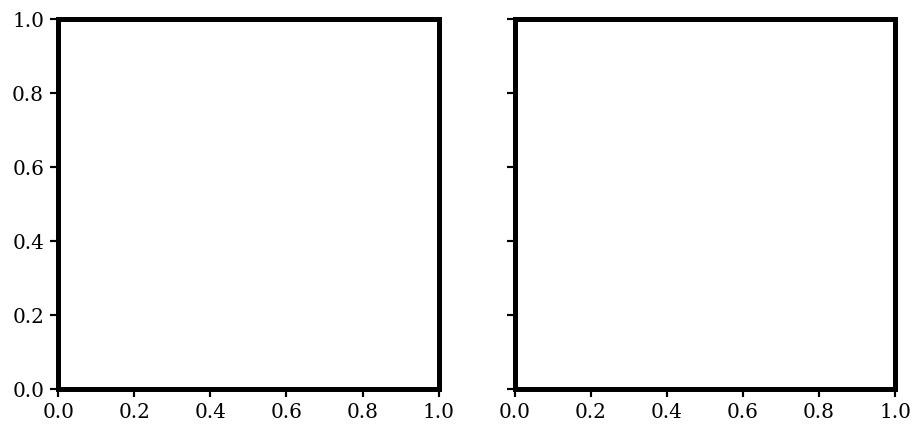

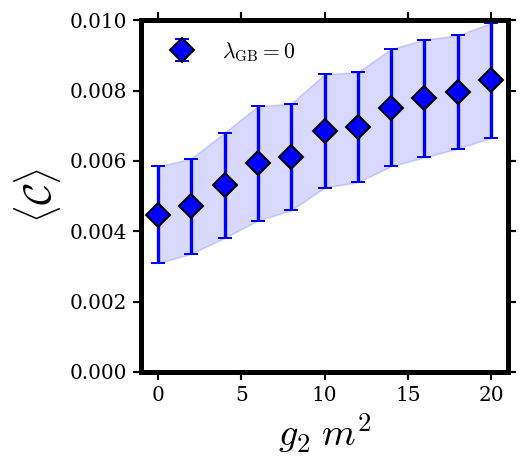

In [18]:
from collections import defaultdict
from scipy.signal import find_peaks


def _peak_stats_last_window(shifted_ln_a, C, dlna, prominence_rel=0.0,
                            min_separation=1):
    """Mean / std / count of local maxima of C(t) in the last `dlna` e-folds.

    Returns (peak_mean, peak_std, n_peaks). If fewer than one interior maximum
    is found, falls back to (max(C_window), 0.0, 0) so the run is still
    plotted with a zero error bar (and is flagged in the printout).

    Parameters
    ----------
    prominence_rel : float
        Minimum peak prominence as a fraction of the window's C-range. Set to
        a small value (e.g. 0.01) to ignore numerical ripples.
    min_separation : int
        Minimum spacing (in samples) between successive peaks.
    """
    sln = np.asarray(shifted_ln_a, dtype=float)
    C   = np.asarray(C,            dtype=float)
    finite = np.isfinite(sln) & np.isfinite(C)
    if not finite.any():
        return np.nan, np.nan, 0
    sln_f = sln[finite]
    C_f   = C[finite]
    lna_max = sln_f.max()
    mask = sln_f >= (lna_max - dlna)
    if not mask.any():
        return np.nan, np.nan, 0
    C_win = C_f[mask]
    if C_win.size < 3:
        return float(C_win.max()), 0.0, 0

    kw = {}
    if min_separation > 1:
        kw["distance"] = int(min_separation)
    if prominence_rel > 0.0:
        rng = float(C_win.max() - C_win.min())
        if rng > 0:
            kw["prominence"] = prominence_rel * rng

    peak_idx, _ = find_peaks(C_win, **kw)
    if peak_idx.size == 0:
        return float(C_win.max()), 0.0, 0
    peaks = C_win[peak_idx]
    return float(np.mean(peaks)), float(np.std(peaks)), int(peaks.size)


colors_lgb  = ["blue", "#f1c40f", "#8e44ad",
               "#e67e22", "#1abc9c", "#34495e", "#e74c3c", "#27ae60", "#2c3e50", "#c0392b"]
markers_lgb = ["D", "s", "D", "^", "v", "<", ">", "P", "X"]

lgb_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4B_MU or beta != P4B_BETA or amp != P4B_AMP or width != P4B_WIDTH:
        continue
    if lgb not in P4B_LGB_SHOW or g2 not in P4B_G2_SHOW:
        continue
    lgb_groups[lgb].append(key)

all_lgbs = sorted(lgb_groups.keys())

fig, ax = plt.subplots(figsize=(4.5,4))

for idx, lgb_val in enumerate(all_lgbs):
    color  = colors_lgb[idx % len(colors_lgb)]
    marker = markers_lgb[idx % len(markers_lgb)]

    points = []
    for key in lgb_groups[lgb_val]:
        d   = all_runs[key]
        sln = d["shifted_ln_a"]
        C   = np.asarray(d["osc"]["C"])

        C_peak_mean, C_peak_std, n_peaks = _peak_stats_last_window(sln, C, P4B_DLNA)
        if not np.isfinite(C_peak_mean):
            continue

        points.append((key[5], C_peak_mean, C_peak_std, n_peaks))

    if not points:
        continue

    points = sorted(points, key=lambda p: p[0])
    x      = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_err  = np.array([p[2] for p in points])

    label = rf"$\lambda_{{\rm GB}}={lgb_val:g}$"

    ax.fill_between(x, y_mean - y_err, y_mean + y_err, color=color, alpha=0.15)
    ax.errorbar(x, y_mean, yerr=y_err,
                fmt=marker, color=color,
                markeredgecolor="k", markeredgewidth=1.2,
                capsize=4, capthick=1.2, elinewidth=2, markersize=10,
                label=label)

    print(f"lgb={lgb_val:g}:")
    for g2v, Cm, Ce, n in points:
        if n == 0:
            tag = "  (fallback: 0 peaks, used max of window)"
        elif n == 1:
            tag = "  (1 peak only -> 0 error)"
        else:
            tag = ""
        print(f"   g2={g2v:>6g}  n_peaks={n:3d}   "
              f"C_peak={Cm:.4e} +/- {Ce:.2e}{tag}")

ax.set_xlabel(r"$g_2\;m^2$")
ax.set_ylabel(r"$\langle\mathcal{C}\rangle$")
ax.set_ylim(0, 0.01)
ax.tick_params(which="both", top=True, right=True)
ax.legend(loc="best", frameon=False)
fig.tight_layout()
save_fig(fig, P4B_NAME)
plt.show()

## Panel 4c — Compactness $\mathcal{C}$ vs $\lambda_{\rm GB}$ (peak statistics, last 0.2 e-folds)

Same estimator as Panel 4b, but the x-axis is now $\lambda_{\rm GB}$ and each curve
corresponds to a fixed $g_2$. In the **last $\Delta\ln a = 0.2$ e-folds** of the aligned
`shifted_ln_a` axis, the local maxima of $\mathcal{C}(t)$ are identified, and

$$\langle\mathcal{C}\rangle = \overline{\mathcal{C}_{\rm peak}}, \qquad
  \sigma_{\mathcal{C}} = \mathrm{std}\bigl(\mathcal{C}_{\rm peak}\bigr).$$

The error bar measures cycle-to-cycle scatter of the maximum compactness between successive
breaths, not the full oscillation amplitude.

In [19]:
### --- Panel 4c selection (edit me) ---
P4C_MU       = 0.08
P4C_BETA     = 0
P4C_AMP      = -0.02
P4C_WIDTH    = 3.0

# Which g2 curves to overlay (one curve per value).
P4C_G2_SHOW  = [0]

# Which lambda_GB values appear on the x-axis (only those present in `all_runs` are used).
P4C_LGB_SHOW = [0, 1, 2, 3,4,5,6,7,8, 9, 10]

# Width of the averaging window (last `P4C_DLNA` e-folds of shifted_ln_a).
P4C_DLNA     = 0.7

P4C_NAME     = "compactness_vs_lgb_last02efold"

print(f"g2  to plot: {P4C_G2_SHOW}")
print(f"lgb to plot: {P4C_LGB_SHOW}")
print(f"averaging window: last {P4C_DLNA} e-folds of shifted_ln_a")
print(f"filter:  beta={P4C_BETA}, mu={P4C_MU}, A={P4C_AMP}, R={P4C_WIDTH}")

g2  to plot: [0]
lgb to plot: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
averaging window: last 0.7 e-folds of shifted_ln_a
filter:  beta=0, mu=0.08, A=-0.02, R=3.0


g2=0:
   lgb=     0  n_peaks=124   C_peak=4.1908e-03 +/- 1.33e-03
   lgb=     1  n_peaks=122   C_peak=4.3089e-03 +/- 1.39e-03
   lgb=     2  n_peaks=123   C_peak=4.6753e-03 +/- 1.57e-03
   lgb=     3  n_peaks=116   C_peak=4.8300e-03 +/- 1.58e-03
   lgb=     4  n_peaks=122   C_peak=4.9646e-03 +/- 1.54e-03
   lgb=     5  n_peaks=116   C_peak=5.1373e-03 +/- 1.59e-03
   lgb=     6  n_peaks=121   C_peak=5.0494e-03 +/- 1.56e-03
   lgb=     7  n_peaks=119   C_peak=5.1705e-03 +/- 1.58e-03
   lgb=     8  n_peaks=117   C_peak=5.2793e-03 +/- 1.60e-03
   lgb=     9  n_peaks=121   C_peak=5.5558e-03 +/- 1.73e-03
   lgb=    10  n_peaks=115   C_peak=5.5645e-03 +/- 1.74e-03
  saved compactness_vs_lgb_last02efold.pdf and compactness_vs_lgb_last02efold.png


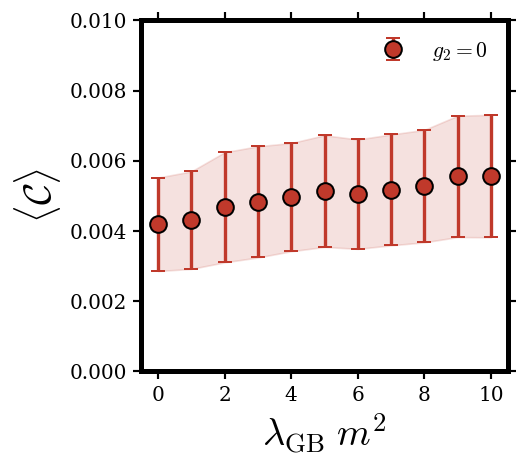

In [20]:
from collections import defaultdict
from scipy.signal import find_peaks

# `_peak_stats_last_window` is defined in Panel 4b; re-define here so this cell
# is self-contained if Panel 4b has not been executed in this session.
try:
    _peak_stats_last_window  # type: ignore[name-defined]
except NameError:
    def _peak_stats_last_window(shifted_ln_a, C, dlna, prominence_rel=0.0,
                                min_separation=1):
        """Mean / std / count of local maxima of C(t) in the last `dlna` e-folds."""
        sln = np.asarray(shifted_ln_a, dtype=float)
        C   = np.asarray(C,            dtype=float)
        finite = np.isfinite(sln) & np.isfinite(C)
        if not finite.any():
            return np.nan, np.nan, 0
        sln_f = sln[finite]
        C_f   = C[finite]
        lna_max = sln_f.max()
        mask = sln_f >= (lna_max - dlna)
        if not mask.any():
            return np.nan, np.nan, 0
        C_win = C_f[mask]
        if C_win.size < 3:
            return float(C_win.max()), 0.0, 0
        kw = {}
        if min_separation > 1:
            kw["distance"] = int(min_separation)
        if prominence_rel > 0.0:
            rng = float(C_win.max() - C_win.min())
            if rng > 0:
                kw["prominence"] = prominence_rel * rng
        peak_idx, _ = find_peaks(C_win, **kw)
        if peak_idx.size == 0:
            return float(C_win.max()), 0.0, 0
        peaks = C_win[peak_idx]
        return float(np.mean(peaks)), float(np.std(peaks)), int(peaks.size)


colors_g2  = [ "#c0392b", "#2980b9", "#f1c40f", "#8e44ad",
              "#e67e22", "#1abc9c", "#34495e", "#e74c3c", "#27ae60","#2c3e50"]
markers_g2 = ["o", "s", "D", "^", "v", "<", ">", "P", "X"]

g2_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4C_MU or beta != P4C_BETA or amp != P4C_AMP or width != P4C_WIDTH:
        continue
    if g2 not in P4C_G2_SHOW or lgb not in P4C_LGB_SHOW:
        continue
    g2_groups[g2].append(key)

all_g2s = sorted(g2_groups.keys())

fig, ax = plt.subplots(figsize=(4.5,4))

for idx, g2_val in enumerate(all_g2s):
    color  = colors_g2[idx % len(colors_g2)]
    marker = markers_g2[idx % len(markers_g2)]

    points = []
    for key in g2_groups[g2_val]:
        d   = all_runs[key]
        sln = d["shifted_ln_a"]
        C   = np.asarray(d["osc"]["C"])

        C_peak_mean, C_peak_std, n_peaks = _peak_stats_last_window(sln, C, P4C_DLNA)
        if not np.isfinite(C_peak_mean):
            continue

        points.append((key[0], C_peak_mean, C_peak_std, n_peaks))

    if not points:
        continue

    points = sorted(points, key=lambda p: p[0])
    x      = np.array([p[0] for p in points])
    y_mean = np.array([p[1] for p in points])
    y_err  = np.array([p[2] for p in points])

    label = rf"$g_2={g2_val:g}$"

    ax.fill_between(x, y_mean - y_err, y_mean + y_err, color=color, alpha=0.15)
    ax.errorbar(x, y_mean, yerr=y_err,
                fmt=marker, color=color,
                markeredgecolor="k", markeredgewidth=1.2,
                capsize=4, capthick=1.2, elinewidth=2, markersize=10,
                label=label)

    print(f"g2={g2_val:g}:")
    for lgbv, Cm, Ce, n in points:
        if n == 0:
            tag = "  (fallback: 0 peaks, used max of window)"
        elif n == 1:
            tag = "  (1 peak only -> 0 error)"
        else:
            tag = ""
        print(f"   lgb={lgbv:>6g}  n_peaks={n:3d}   "
              f"C_peak={Cm:.4e} +/- {Ce:.2e}{tag}")

ax.set_xlabel(r"$\lambda_{\rm GB}\;m^2$")
ax.set_ylabel(r"$\langle\mathcal{C}\rangle$")
ax.set_ylim(0, 0.01)
ax.tick_params(which="both", top=True, right=True)
ax.legend(loc="best", frameon=False)
fig.tight_layout()
save_fig(fig, P4C_NAME)
plt.show()

## Panel 4d — Side-by-side $\mathcal{C}$ vs $\lambda_{\rm GB}$ and $\mathcal{C}$ vs $g_2$

Combines Panels 4c (left, $\mathcal{C}$ vs $\lambda_{\rm GB}$, one curve per $g_2$) and
4b (right, $\mathcal{C}$ vs $g_2$, one curve per $\lambda_{\rm GB}$) in a single 1×2
figure with a shared y-axis. Both panels use the same peak-statistics estimator
(`_peak_stats_last_window`) from Panel 4b and the existing `P4B_*` / `P4C_*` selection
variables, so editing either selection cell automatically updates this panel as well.

  saved compactness_vs_lgb_and_g2.pdf and compactness_vs_lgb_and_g2.png


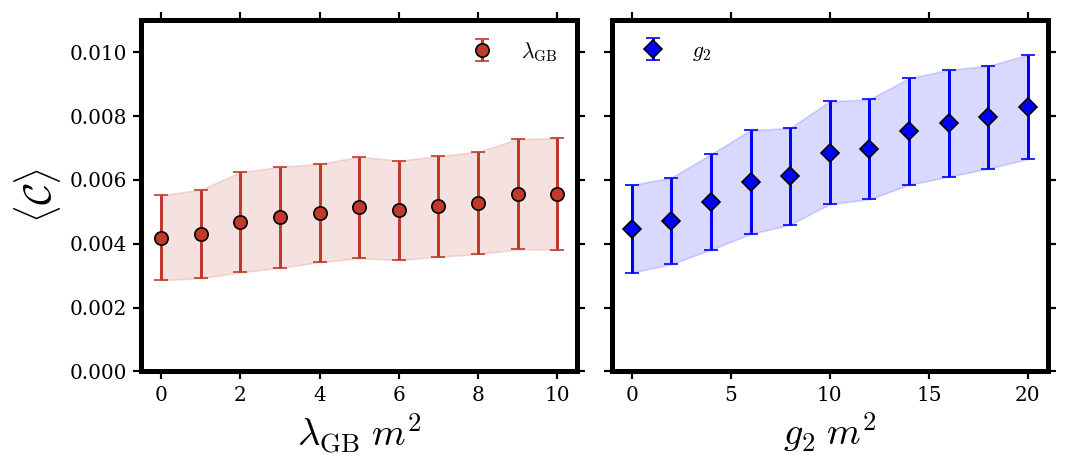

In [21]:
from collections import defaultdict
from scipy.signal import find_peaks
# Reuse `_peak_stats_last_window` from Panel 4b; re-define defensively so this
# cell stands on its own if Panel 4b has not been executed in this session.
try:
    _peak_stats_last_window  # type: ignore[name-defined]
except NameError:
    def _peak_stats_last_window(shifted_ln_a, C, dlna, prominence_rel=0.0,
                                min_separation=1):
        sln = np.asarray(shifted_ln_a, dtype=float)
        C   = np.asarray(C,            dtype=float)
        finite = np.isfinite(sln) & np.isfinite(C)
        if not finite.any():
            return np.nan, np.nan, 0
        sln_f = sln[finite]
        C_f   = C[finite]
        lna_max = sln_f.max()
        mask = sln_f >= (lna_max - dlna)
        if not mask.any():
            return np.nan, np.nan, 0
        C_win = C_f[mask]
        if C_win.size < 3:
            return float(C_win.max()), 0.0, 0
        kw = {}
        if min_separation > 1:
            kw["distance"] = int(min_separation)
        if prominence_rel > 0.0:
            rng = float(C_win.max() - C_win.min())
            if rng > 0:
                kw["prominence"] = prominence_rel * rng
        peak_idx, _ = find_peaks(C_win, **kw)
        if peak_idx.size == 0:
            return float(C_win.max()), 0.0, 0
        peaks = C_win[peak_idx]
        return float(np.mean(peaks)), float(np.std(peaks)), int(peaks.size)


# Same palettes/markers used in Panels 4b and 4c.
_colors_lgb_d  = ["blue", "#f1c40f", "#8e44ad", "#e67e22", "#1abc9c",
                  "#34495e", "#e74c3c", "#27ae60", "#2c3e50", "#c0392b"]
_markers_lgb_d = ["D", "s", "D", "^", "v", "<", ">", "P", "X"]

_colors_g2_d   = ["#c0392b", "#2980b9", "#f1c40f", "#8e44ad", "#e67e22",
                  "#1abc9c", "#34495e", "#e74c3c", "#27ae60", "#2c3e50"]
_markers_g2_d  = ["o", "s", "D", "^", "v", "<", ">", "P", "X"]


def _collect_points(groups, dlna, key_index):
    """For each group, return a sorted list of (x, C_peak_mean, C_peak_std)."""
    out = {}
    for grp_val, keys in groups.items():
        pts = []
        for key in keys:
            d = all_runs[key]
            Cm, Ce, n = _peak_stats_last_window(
                d["shifted_ln_a"], np.asarray(d["osc"]["C"]), dlna)
            if not np.isfinite(Cm):
                continue
            pts.append((key[key_index], Cm, Ce))
        if pts:
            out[grp_val] = sorted(pts, key=lambda p: p[0])
    return out


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

# ── Left panel: C vs lambda_GB, one curve per g2 (uses Panel 4c selection) ──
g2_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4C_MU or beta != P4C_BETA or amp != P4C_AMP or width != P4C_WIDTH:
        continue
    if g2 not in P4C_G2_SHOW or lgb not in P4C_LGB_SHOW:
        continue
    g2_groups[g2].append(key)

g2_points = _collect_points(g2_groups, P4C_DLNA, key_index=0)
for idx, g2_val in enumerate(sorted(g2_points.keys())):
    pts    = g2_points[g2_val]
    color  = _colors_g2_d[idx % len(_colors_g2_d)]
    marker = _markers_g2_d[idx % len(_markers_g2_d)]
    x  = np.array([p[0] for p in pts])
    y  = np.array([p[1] for p in pts])
    ye = np.array([p[2] for p in pts])
    ax_l.fill_between(x, y - ye, y + ye, color=color, alpha=0.15)
    ax_l.errorbar(x, y, yerr=ye, fmt=marker, color=color,
                  markeredgecolor="k", markeredgewidth=1.0,
                  capsize=4, capthick=1.0, elinewidth=1.8, markersize=8,
                  #label=rf"$g_2={g2_val:g}$")
                  label=rf"$\lambda_{{\rm GB}}$")

ax_l.set_xlabel(r"$\lambda_{\rm GB}\;m^2$")
ax_l.set_ylabel(r"$\langle\mathcal{C}\rangle$")
ax_l.set_ylim(0, 0.011)
ax_l.tick_params(which="both", top=True, right=True)
ax_l.legend(loc="best", frameon=False)

# ── Right panel: C vs g2, one curve per lambda_GB (uses Panel 4b selection) ──
lgb_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4B_MU or beta != P4B_BETA or amp != P4B_AMP or width != P4B_WIDTH:
        continue
    if lgb not in P4B_LGB_SHOW or g2 not in P4B_G2_SHOW:
        continue
    lgb_groups[lgb].append(key)

lgb_points = _collect_points(lgb_groups, P4B_DLNA, key_index=5)
for idx, lgb_val in enumerate(sorted(lgb_points.keys())):
    pts    = lgb_points[lgb_val]
    color  = _colors_lgb_d[idx % len(_colors_lgb_d)]
    marker = _markers_lgb_d[idx % len(_markers_lgb_d)]
    x  = np.array([p[0] for p in pts])
    y  = np.array([p[1] for p in pts])
    ye = np.array([p[2] for p in pts])
    ax_r.fill_between(x, y - ye, y + ye, color=color, alpha=0.15)
    ax_r.errorbar(x, y, yerr=ye, fmt=marker, color=color,
                  markeredgecolor="k", markeredgewidth=1.0,
                  capsize=4, capthick=1.0, elinewidth=1.8, markersize=8,
                  #label=rf"$\lambda_{{\rm GB}}={lgb_val:g}$")
                  label=rf"$g_2$")

ax_r.set_xlabel(r"$g_2\;m^2$")
ax_r.tick_params(which="both", top=True, right=True)
ax_r.legend(loc="best", frameon=False)

fig.tight_layout()
save_fig(fig, "compactness_vs_lgb_and_g2")
plt.show()

  saved radius_min_vs_lgb_and_g2.pdf and radius_min_vs_lgb_and_g2.png


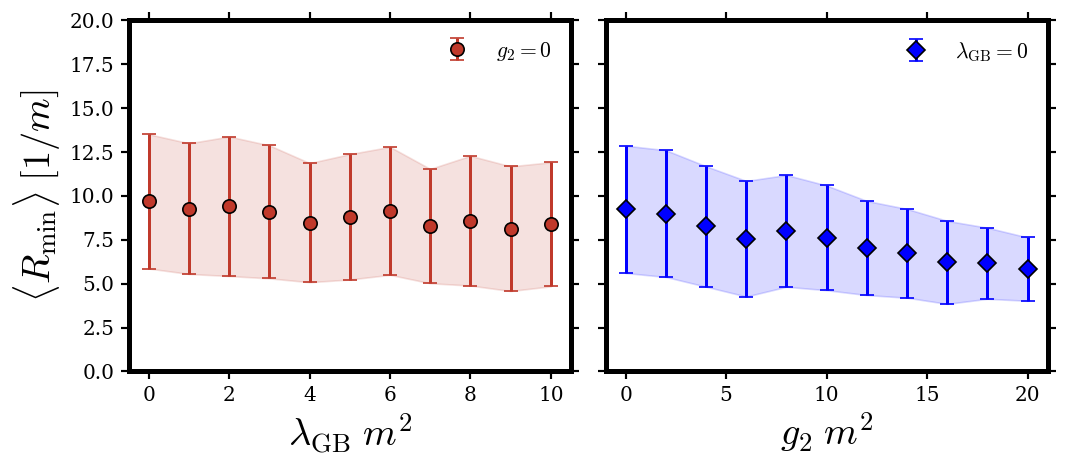

In [23]:
# Panel 4d-R — Same layout as Panel 4d (side-by-side: vs lambda_GB and vs g2)
# but plotting the oscillon radius R(t) trough (minima) statistics instead of
# the compactness maxima. Reuses the Panel 4b / 4c selection variables and the
# same palettes/markers, so it stays visually consistent with Panel 4d.

from collections import defaultdict
from scipy.signal import find_peaks


def _trough_stats_last_window(shifted_ln_a, C, dlna, prominence_rel=0.0,
                              min_separation=1):
    """Mean / std / count of local minima of C(t) in the last `dlna` e-folds.

    Mirror of `_peak_stats_last_window` but detects troughs by running
    `find_peaks` on `-C_window`. Falls back to `min(C_window)` with zero error
    when no interior minimum is found.
    """
    sln = np.asarray(shifted_ln_a, dtype=float)
    C   = np.asarray(C,            dtype=float)
    finite = np.isfinite(sln) & np.isfinite(C)
    if not finite.any():
        return np.nan, np.nan, 0
    sln_f = sln[finite]
    C_f   = C[finite]
    lna_max = sln_f.max()
    mask = sln_f >= (lna_max - dlna)
    if not mask.any():
        return np.nan, np.nan, 0
    C_win = C_f[mask]
    if C_win.size < 3:
        return float(C_win.min()), 0.0, 0

    kw = {}
    if min_separation > 1:
        kw["distance"] = int(min_separation)
    if prominence_rel > 0.0:
        rng = float(C_win.max() - C_win.min())
        if rng > 0:
            kw["prominence"] = prominence_rel * rng

    trough_idx, _ = find_peaks(-C_win, **kw)
    if trough_idx.size == 0:
        return float(C_win.min()), 0.0, 0
    troughs = C_win[trough_idx]
    return float(np.mean(troughs)), float(np.std(troughs)), int(troughs.size)


def _collect_points_R(groups, dlna, key_index):
    """For each group, return a sorted list of (x, R_min_mean, R_min_std)."""
    out = {}
    for grp_val, keys in groups.items():
        pts = []
        for key in keys:
            d = all_runs[key]
            Rm, Re, n = _trough_stats_last_window(
                d["shifted_ln_a"], np.asarray(d["osc"]["R"]), dlna)
            if not np.isfinite(Rm):
                continue
            pts.append((key[key_index], Rm, Re))
        if pts:
            out[grp_val] = sorted(pts, key=lambda p: p[0])
    return out


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

# ── Left panel: R vs lambda_GB, one curve per g2 (uses Panel 4c selection) ──
g2_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4C_MU or beta != P4C_BETA or amp != P4C_AMP or width != P4C_WIDTH:
        continue
    if g2 not in P4C_G2_SHOW or lgb not in P4C_LGB_SHOW:
        continue
    g2_groups[g2].append(key)

g2_points = _collect_points_R(g2_groups, P4C_DLNA, key_index=0)
for idx, g2_val in enumerate(sorted(g2_points.keys())):
    pts    = g2_points[g2_val]
    color  = _colors_g2_d[idx % len(_colors_g2_d)]
    marker = _markers_g2_d[idx % len(_markers_g2_d)]
    x  = np.array([p[0] for p in pts])
    y  = np.array([p[1] for p in pts])
    ye = np.array([p[2] for p in pts])
    ax_l.fill_between(x, y - ye, y + ye, color=color, alpha=0.15)
    ax_l.errorbar(x, y, yerr=ye, fmt=marker, color=color,
                  markeredgecolor="k", markeredgewidth=1.0,
                  capsize=4, capthick=1.0, elinewidth=1.8, markersize=8,
                  label=rf"$g_2={g2_val:g}$")

ax_l.set_xlabel(r"$\lambda_{\rm GB}\;m^2$")
ax_l.set_ylabel(r"$\langle R_{\min} \rangle \; [1/m]$")
ax_l.tick_params(which="both", top=True, right=True)
ax_l.legend(loc="best", frameon=False)

# ── Right panel: R vs g2, one curve per lambda_GB (uses Panel 4b selection) ──
lgb_groups = defaultdict(list)
for key in all_runs:
    lgb, mu, beta, amp, width, g2 = key
    if mu != P4B_MU or beta != P4B_BETA or amp != P4B_AMP or width != P4B_WIDTH:
        continue
    if lgb not in P4B_LGB_SHOW or g2 not in P4B_G2_SHOW:
        continue
    lgb_groups[lgb].append(key)

lgb_points = _collect_points_R(lgb_groups, P4B_DLNA, key_index=5)
for idx, lgb_val in enumerate(sorted(lgb_points.keys())):
    pts    = lgb_points[lgb_val]
    color  = _colors_lgb_d[idx % len(_colors_lgb_d)]
    marker = _markers_lgb_d[idx % len(_markers_lgb_d)]
    x  = np.array([p[0] for p in pts])
    y  = np.array([p[1] for p in pts])
    ye = np.array([p[2] for p in pts])
    ax_r.fill_between(x, y - ye, y + ye, color=color, alpha=0.15)
    ax_r.errorbar(x, y, yerr=ye, fmt=marker, color=color,
                  markeredgecolor="k", markeredgewidth=1.0,
                  capsize=4, capthick=1.0, elinewidth=1.8, markersize=8,
                  label=rf"$\lambda_{{\rm GB}}={lgb_val:g}$")

ax_r.set_xlabel(r"$g_2\;m^2$")
ax_r.tick_params(which="both", top=True, right=True)
ax_r.legend(loc="best", frameon=False)
ax_r.set_ylim(0,20)
fig.tight_layout()
save_fig(fig, "radius_min_vs_lgb_and_g2")
plt.show()

## Panel 4a — Max compactness heatmap over $(\lambda_{\rm GB},\, g_2)$

2D heatmap (discrete blocks) of the maximum compactness $\max_{\ln(a)>2}\mathcal{C}$ for each
available run with $\beta=0$ at the chosen $(\mu, A, R)$. The plot is filled from the runs already
loaded into `all_runs` (so only 1/24 resolution since `FILTER_DR=1/24`); missing cells are shown in
grey and listed under the plot as a TODO list of runs you may want to compute.

Both axes default to integer step (`0, 1, 2, ..., 20`). Change `P4A_STEP_LGB` / `P4A_STEP_G2` to
`2`, `5`, etc. to thin the grid.

In [82]:
### --- Panel 4a selection (edit me) ---
P4A_MU     = 0.08
P4A_BETA   = 0
P4A_AMP    = -0.02
P4A_WIDTH  = 3.0

P4A_LGB_MIN, P4A_LGB_MAX = 0, 8
P4A_G2_MIN,  P4A_G2_MAX  = 0, 20
P4A_STEP_LGB = 2    # 1, 2, 5, ...
P4A_STEP_G2  = 2     # 1, 2, 5, ...

P4A_LNA_MIN  = 2.0   # max compactness measured on shifted_ln_a > this
P4A_CMAP     = "Blues"
P4A_VMIN     = None  # log-norm lower bound; None = auto from data
P4A_VMAX     = None  # log-norm upper bound; None = auto from data
P4A_NLEVELS  = 8     # number of discrete colour blocks (cells + colourbar)

P4A_NAME = "compactness_heatmap_lgb_g2"

P4A_LGB_VALUES = np.arange(P4A_LGB_MIN, P4A_LGB_MAX + P4A_STEP_LGB, P4A_STEP_LGB)
P4A_G2_VALUES  = np.arange(P4A_G2_MIN,  P4A_G2_MAX  + P4A_STEP_G2,  P4A_STEP_G2)

print(f"lgb grid ({len(P4A_LGB_VALUES)} pts): {list(P4A_LGB_VALUES)}")
print(f"g2  grid ({len(P4A_G2_VALUES)} pts): {list(P4A_G2_VALUES)}")
print(f"filter:  beta={P4A_BETA}, mu={P4A_MU}, A={P4A_AMP}, R={P4A_WIDTH}, dr=1/24 (from loader)")

lgb grid (5 pts): [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
g2  grid (11 pts): [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20)]
filter:  beta=0, mu=0.08, A=-0.02, R=3.0, dr=1/24 (from loader)


Filled 55 / 55 cells.
  saved compactness_heatmap_lgb_g2.pdf and compactness_heatmap_lgb_g2.png


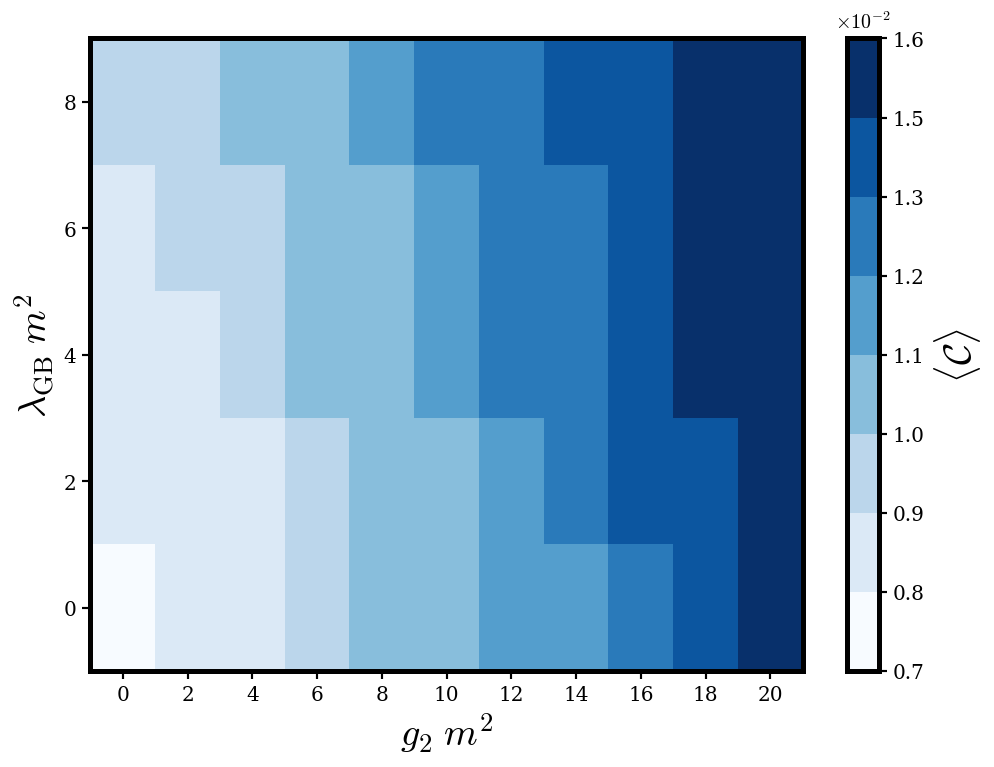


All requested cells are filled.


In [94]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FuncFormatter
from collections import defaultdict

ny, nx = len(P4A_LGB_VALUES), len(P4A_G2_VALUES)
Z = np.full((ny, nx), np.nan)

missing_no_run     = []
missing_no_late_C  = []
for i, lgb in enumerate(P4A_LGB_VALUES):
    for j, g2 in enumerate(P4A_G2_VALUES):
        key = (float(lgb), float(P4A_MU), float(P4A_BETA),
               float(P4A_AMP), float(P4A_WIDTH), float(g2))
        if key not in all_runs:
            missing_no_run.append((int(lgb), float(g2)))
            continue
        d   = all_runs[key]
        sln = d["shifted_ln_a"]
        C   = np.asarray(d["osc"]["C"])
        m   = sln > P4A_LNA_MIN
        if m.any() and np.isfinite(C[m]).any():
            Z[i, j] = float(np.nanmax(C[m]))
        else:
            missing_no_late_C.append((int(lgb), float(g2)))

filled = int(np.isfinite(Z).sum())
print(f"Filled {filled} / {ny*nx} cells.")

# Cell edges (half-step on each side of every grid point)
def _edges(vals, step):
    v = np.asarray(vals, dtype=float)
    return np.concatenate([v - step / 2.0, v[-1:] + step / 2.0])
g2_edges  = _edges(P4A_G2_VALUES,  P4A_STEP_G2)
lgb_edges = _edges(P4A_LGB_VALUES, P4A_STEP_LGB)

finite = Z[np.isfinite(Z) & (Z > 0)]
#vmin = P4A_VMIN if P4A_VMIN is not None else (float(finite.min()) if finite.size else 1e-4)
#vmax = P4A_VMAX if P4A_VMAX is not None else (float(finite.max()) if finite.size else 1e-1)

# Log-spaced discrete levels -> discrete cells AND discrete colourbar blocks.
levels = np.logspace(np.log10(vmin), np.log10(vmax), P4A_NLEVELS + 1)
cmap   = plt.get_cmap(P4A_CMAP, P4A_NLEVELS).copy()
cmap.set_bad("black")
norm   = BoundaryNorm(boundaries=levels, ncolors=P4A_NLEVELS)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
pc = ax.pcolormesh(g2_edges, lgb_edges, Z, shading="flat",
                   norm=norm, cmap=cmap)
_CBAR_SCALE = 1e-2
cbar = fig.colorbar(pc, ax=ax, ticks=levels, spacing="uniform",
                    format=FuncFormatter(lambda v, _pos: f"{v / _CBAR_SCALE:.1f}"))
#cbar.set_label(r"$\max\;\mathcal{C}$")
cbar.set_label(r"$\langle\mathcal{C}\rangle$")
cbar.ax.set_title(r"$\times 10^{-2}$", fontsize=12, pad=6)

ax.set_xlabel(r"$g_2\;m^2$")
ax.set_ylabel(r"$\lambda_{\rm GB}\;m^2$")
#ax.set_title(rf"Max compactness vs $(\lambda_{{\rm GB}},\, g_2)$; "rf"$\beta={P4A_BETA},\ \mu={P4A_MU},\ A={P4A_AMP},\ R={P4A_WIDTH}$")
ax.set_xticks(P4A_G2_VALUES)
ax.set_yticks(P4A_LGB_VALUES)
ax.set_aspect("auto")
ax.grid(False)

fig.tight_layout()
save_fig(fig, P4A_NAME)
plt.show()

# Suggested runs: missing (lgb, g2) cells
if missing_no_run or missing_no_late_C:
    print("\n--- Suggested runs to compute (1/24 resolution) ---")
    if missing_no_run:
        by_lgb = defaultdict(list)
        for lgb, g2 in missing_no_run:
            by_lgb[lgb].append(g2)
        print(f"\nMissing entirely ({len(missing_no_run)} runs):")
        for lgb in sorted(by_lgb):
            print(f"  lgb={lgb:>3d}: g2 = {by_lgb[lgb]}")
    if missing_no_late_C:
        print(f"\nRun exists but has no data for shifted_ln_a > {P4A_LNA_MIN} ({len(missing_no_late_C)} runs):")
        for lgb, g2 in sorted(missing_no_late_C):
            print(f"  lgb={lgb:>3d}, g2={g2:g}")
else:
    print("\nAll requested cells are filled.")

  saved panel4a_spatial_EFT_lgb0_g220_lna2p50.pdf and panel4a_spatial_EFT_lgb0_g220_lna2p50.png


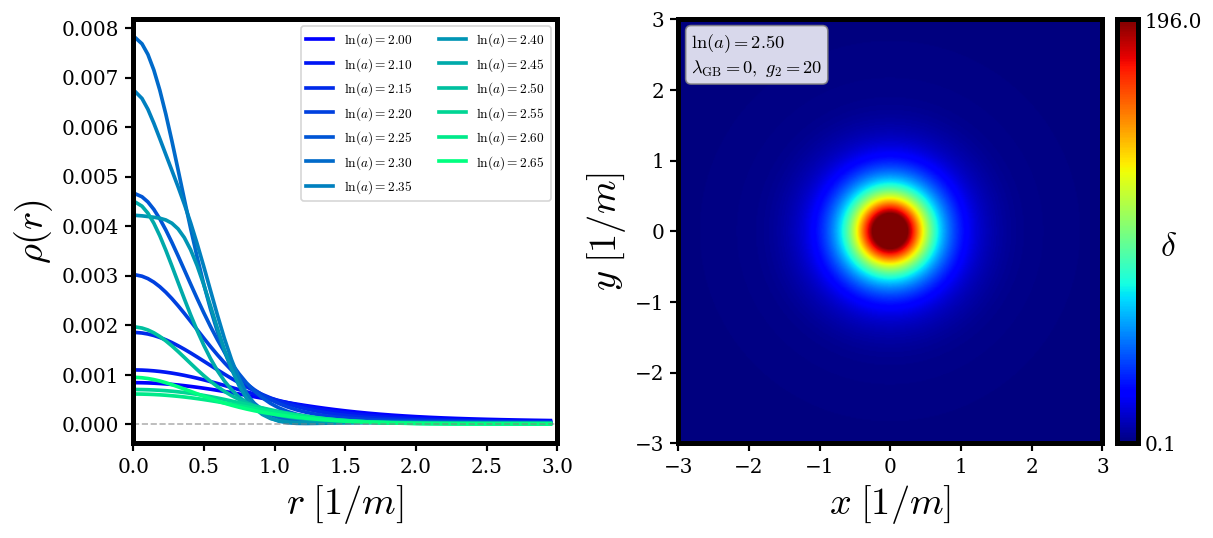

In [63]:
# Panel 4a-spatial — Panel 8-style view (radial rho(r) + 2D delta(x,y)) for one
# (lambda_GB, g2) cell of the heatmap above, so we can inspect the spatial
# distribution when EFT terms are switched on.
#
# Edit P4A8_LGB / P4A8_G2 to pick any cell of the Panel 4a grid. The other
# parameters (mu, beta, amp, width) are reused from the Panel 4a selection.

P4A8_LGB     = 0       # pick a non-zero EFT corner from the heatmap
P4A8_G2      = 20
P4A8_LNA_2D  = 2.5     # ln(a) at which to draw the 2D slice
P4A8_SNAPS   = [2.0, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65]
P4A8_R_MAX   = 3.0
P4A8_X_MAX   = 3.0
P4A8_NPIX    = 400
P4A8_CMAP    = "jet"
P4A8_VMIN    = None
P4A8_VMAX    = None
P4A8_USE_OSC_RADIUS = False
P4A8_X_NORM_MAX     = 5.0

key_eft = (float(P4A8_LGB), float(P4A_MU), float(P4A_BETA),
           float(P4A_AMP),  float(P4A_WIDTH), float(P4A8_G2))

if key_eft not in all_runs:
    print(f"Key {key_eft} not found in all_runs. "
          f"Available (lgb, g2) at mu={P4A_MU}, beta={P4A_BETA}, "
          f"A={P4A_AMP}, R={P4A_WIDTH}:")
    for k in sorted(all_runs.keys()):
        if (k[1], k[2], k[3], k[4]) == (P4A_MU, P4A_BETA, P4A_AMP, P4A_WIDTH):
            print(f"  lgb={k[0]:g}, g2={k[5]:g}")
else:
    run_eft = all_runs[key_eft]
    osc_eft = run_eft["osc"]
    r_eft   = np.asarray(osc_eft["r"])
    ln_a_e  = np.asarray(run_eft["shifted_ln_a"])

    # ── Left panel: radial rho(r) profiles at P4A8_SNAPS ──────────────────
    rho_eft   = np.asarray(osc_eft["rho"])
    R_osc_e   = np.asarray(osc_eft["R"])
    snap_idx  = [int(np.argmin(np.abs(ln_a_e - v))) for v in P4A8_SNAPS]

    # ── Right panel: 2D slice of delta(x, y) at P4A8_LNA_2D ───────────────
    if "delta_rho" in osc_eft:
        field2 = np.asarray(osc_eft["delta_rho"])
    else:
        rho_bar_e = np.asarray(osc_eft["rho_bar"])
        field2    = rho_eft / np.maximum(rho_bar_e[:, None], 1e-30) - 1.0

    idx2D    = int(np.argmin(np.abs(ln_a_e - P4A8_LNA_2D)))
    lna_2D   = ln_a_e[idx2D]
    prof2D   = field2[idx2D]

    order_e  = np.argsort(r_eft)
    r_sort_e = r_eft[order_e]
    p_sort_e = prof2D[order_e]

    n_pix = P4A8_NPIX
    xs = np.linspace(-P4A8_X_MAX, P4A8_X_MAX, n_pix)
    ys = np.linspace(-P4A8_X_MAX, P4A8_X_MAX, n_pix)
    X_e, Y_e = np.meshgrid(xs, ys)
    R_e      = np.sqrt(X_e**2 + Y_e**2)

    delta_2d_e = np.interp(R_e, r_sort_e, p_sort_e,
                           left=p_sort_e[0], right=0.0)
    vmin = float(np.nanmin(delta_2d_e)) if P4A8_VMIN is None else P4A8_VMIN
    vmax = float(np.nanmax(delta_2d_e)) if P4A8_VMAX is None else P4A8_VMAX

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 5),
                                   constrained_layout=True)
    axL.set_box_aspect(1)

    cmap_L = plt.cm.winter
    m_snap = len(snap_idx)
    for j, idx in enumerate(snap_idx):
        color = cmap_L(j / max(m_snap - 1, 1))
        lna_v = ln_a_e[idx]
        yprof = rho_eft[idx]

        if P4A8_USE_OSC_RADIUS:
            R_osc = R_osc_e[idx]
            if R_osc <= 0:
                print(f"Skipping ln(a)={lna_v:.2f}: R_osc = {R_osc:.3g}")
                continue
            x_axis = r_eft / R_osc
            x_mask = (r_eft >= 0) & (x_axis <= P4A8_X_NORM_MAX)
            lbl    = rf"$\ln(a) = {lna_v:.2f},\ R_{{\rm osc}} = {R_osc:.2f}$"
        else:
            x_axis = r_eft
            x_mask = (r_eft >= 0) & (r_eft <= P4A8_R_MAX)
            lbl    = rf"$\ln(a) = {lna_v:.2f}$"

        axL.plot(x_axis[x_mask], yprof[x_mask], color=color, lw=2.2, label=lbl)

    axL.axhline(0.0, color="grey", ls="--", lw=1.0, alpha=0.6)
    if P4A8_USE_OSC_RADIUS:
        axL.axvline(1.0, color="grey", ls=":", lw=1.2, alpha=0.7)
        axL.set_xlabel(r"$r / R_{\rm osc}(t)$")
        axL.set_xlim(0, P4A8_X_NORM_MAX)
    else:
        axL.set_xlabel(r"$r \; [1/m]$")
        axL.set_xlim(0, P4A8_R_MAX)
    axL.set_ylabel(r"$\rho(r)$")
    axL.legend(fontsize=8, loc="best", frameon=True, ncol=2)

    im = axR.imshow(
        delta_2d_e,
        extent=[-P4A8_X_MAX, P4A8_X_MAX, -P4A8_X_MAX, P4A8_X_MAX],
        origin="lower",
        cmap=P4A8_CMAP,
        #vmin=vmin, vmax=vmax,
        vmin=vmin, vmax=196.6,
        aspect="equal",
        interpolation="bilinear",
    )
    axR.set_xlabel(r"$x \; [1/m]$")
    axR.set_ylabel(r"$y \; [1/m]$")

    cbar = fig.colorbar(im, ax=axR, orientation="vertical",
                        location="right", fraction=0.05, pad=0.02)
    cbar.set_label(r"$\delta$", rotation=0, labelpad=-20, fontsize=20)
    #cbar.set_ticks([vmin, vmax])
    cbar.set_ticks([vmin, 196])
    cbar.ax.tick_params(direction="in")

    axR.text(
        0.03, 0.97,
        rf"$\ln(a) = {lna_2D:.2f}$" "\n"
        rf"$\lambda_{{\rm GB}} = {P4A8_LGB:g},\ g_2 = {P4A8_G2:g}$",
        transform=axR.transAxes, va="top", ha="left", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", alpha=0.85, edgecolor="grey"),
    )

    tag = f"_lgb{P4A8_LGB:g}_g2{P4A8_G2:g}_lna{lna_2D:.2f}".replace(".", "p")
    save_fig(fig, "panel4a_spatial_EFT" + tag)
    plt.show()

## Panel 4 — Compactness, weak-coupling and $g_2$ hyperbolicity

Three stacked panels sharing the x-axis (aligned $\ln(a)$, fixed to $[2,\,3.5]$):
1. Compactness $\mathcal{C}$
2. Weak-coupling condition $\max_r \sqrt{|\lambda'|}\,L^{-1}$ (and $\sqrt{|g_2|}\,\tilde L^{-1}$ dashed where $g_2 \neq 0$)
3. $g_2$ hyperbolicity: $\min_r$ of $\det(g^{\rm eff}_{\mu\nu})/\det(g_{\mu\nu})$

GR (`lgb=0, g2=0`) is drawn as a thick black line. EFT diagnostics are computed (and cached
on disk) only for the selected runs. Set `FORCE_EFT_RECOMPUTE = True` to overwrite the
cached `eft_diagnostics.npz`.

In [90]:
### --- Panel 4 selection (edit me) ---
PLOT4_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [250],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0,5,10],
)
"""
PLOT4_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0, 10, 20],
)
"""
PLOT4_NAME = "rho_C_WCC_hyp"

PLOT4_USE_TAB_COLORS = False   # False = blue ramp; True = tab10 cycle (tab:blue, orange, green, ...)

# Optional: highlight a specific run in a distinct color, plotted behind the others.
# Set to a key tuple e.g. (0, 0.08, 250, -0.02, 3.0, 10) or None to disable.
#PLOT4_HIGHLIGHT_KEY   = None
PLOT4_HIGHLIGHT_KEY   = (0, 0.08, 250, -0.02, 3.0, 35)
PLOT4_HIGHLIGHT_COLOR = "red"
PLOT4_HIGHLIGHT_LW    = 2
PLOT4_HIGHLIGHT_ALPHA = 0.5

R_WCC_MAX           = 100.0   # only consider r in (0, R_WCC_MAX] for WCC / hyperbolicity maxima
FORCE_EFT_RECOMPUTE = False   # True = ignore any cached eft_diagnostics.npz and recompute

# Middle panel (weak-coupling condition) y-axis options.
PLOT4_WCC_LOG          = True            # True -> log y; False -> linear y
PLOT4_WCC_YLIM_LOG     = (1e-3, 1e1)     # used when PLOT4_WCC_LOG is True
PLOT4_WCC_YLIM_LINEAR  = (0.0, 1.2)      # used when PLOT4_WCC_LOG is False

print(f"{len(PLOT4_KEYS)} run(s) selected for Panel 4:")
for k in PLOT4_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"], " g2=", k[5])

# Compute / load EFT diagnostics only for the selected runs
for k in PLOT4_KEYS:
    d = all_runs[k]
    if "eft" in d and not FORCE_EFT_RECOMPUTE:
        continue
    run_dir  = d["run_dir"]
    eft_path = os.path.join(run_dir, "eft_diagnostics.npz")
    if os.path.exists(eft_path) and not FORCE_EFT_RECOMPUTE:
        d["eft"] = dict(np.load(eft_path, allow_pickle=True))
        print(f"  [EFT] loaded cache for {d['tag']}")
    else:
        sol_i    = np.load(os.path.join(run_dir, "solution.npy"))
        matter_i = ScalarMatter(scalar_mu, d["mu"])
        sv_i     = StateVector(matter_i)
        spacing_i = CubicSpacing(**CubicSpacing.get_parameters(
            d["run_r_max"], d["run_min_dr"], d["run_max_dr"]))
        grid_i   = Grid(spacing_i, sv_i)
        bg_i     = FlatSphericalBackground(grid_i.r)
        lgb_k, mu_k, beta_k, amp_k, width_k, g2_k = k
        params = (lgb_k, a_mg, b_mg, chi0, d["coupling"], g2_k)
        eft = get_eft_diagnostic(
            sol_i, d["t"], grid_i, bg_i,
            ScalarMatter(scalar_mu, d["mu"]),
            params,
        )
        np.savez(eft_path, **eft)
        d["eft"] = eft
        del sol_i
        verb = "recomputed" if FORCE_EFT_RECOMPUTE else "computed"
        print(f"  [EFT] {verb} & cached for {d['tag']}")

3 run(s) selected for Panel 4:
  (0.0, 0.08, 250.0, -0.02, 3.0, 0.0)  coupling= quadratic  g2= 0.0
  (0.0, 0.08, 250.0, -0.02, 3.0, 5.0)  coupling= quadratic  g2= 5.0
  (0.0, 0.08, 250.0, -0.02, 3.0, 10.0)  coupling= quadratic  g2= 10.0


  saved rho_C_WCC_hyp.pdf and rho_C_WCC_hyp.png


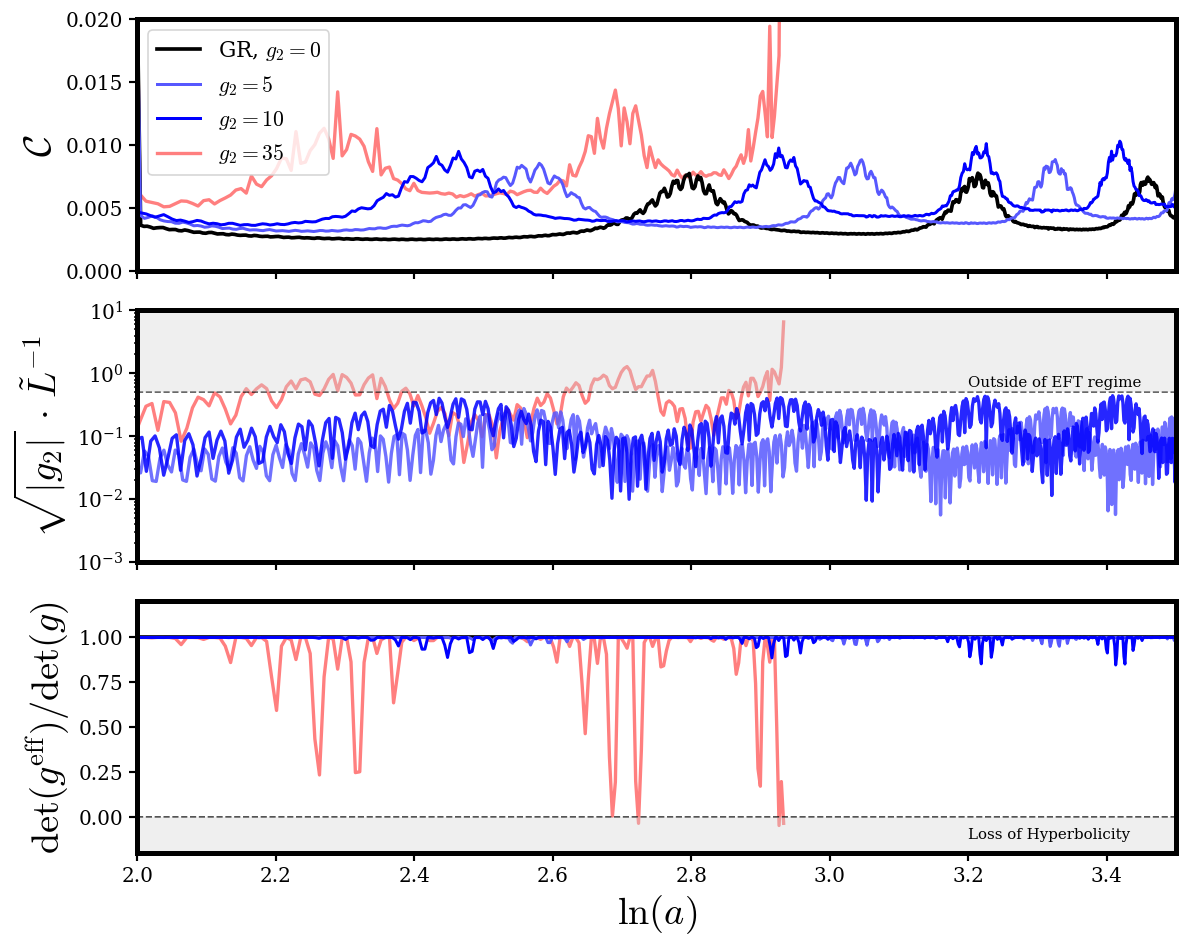

In [91]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Curves coloured by g2 magnitude: light blue = weak g2, dark blue = strong g2.
# The darkest shade is the matplotlib named colour "blue" (matching the blue
# used in Panel 4d's right axes) and is assigned to the *highest* selected g2.
# GR (lgb=0, g2=0) still overrides to black.
from matplotlib.colors import LinearSegmentedColormap as _LSC
_unique_g2  = sorted({k[5] for k in PLOT4_KEYS})
_BLUES_RAMP = _LSC.from_list("_g2_blues", ["#fafbfc", "blue"])
_TAB10 = plt.cm.tab10

def _color_for_g2(g2_val):
    if PLOT4_USE_TAB_COLORS:
        rank = _unique_g2.index(g2_val)
        return _TAB10(rank % 10)
    if len(_unique_g2) <= 1:
        return _BLUES_RAMP(1.0)
    rank = _unique_g2.index(g2_val)
    frac = 0.30 + 0.70 * rank / (len(_unique_g2) - 1)
    return _BLUES_RAMP(frac)

if len(PLOT4_KEYS) == 0:
    print("No keys selected for Panel 4.")
else:
    first = all_runs[PLOT4_KEYS[0]]
    r0    = first["eft"]["r"] if ("eft" in first) else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX) if r0 is not None else None

    # Draw highlighted run first (behind everything) if requested
    _highlight_legend_handle = None
    if PLOT4_HIGHLIGHT_KEY is not None and PLOT4_HIGHLIGHT_KEY in all_runs:
        _hk  = PLOT4_HIGHLIGHT_KEY
        _hr  = all_runs[_hk]
        _ho  = _hr["osc"]
        _he  = _hr.get("eft", None)
        _hx  = _hr["shifted_ln_a"]
        _hlgb, _hmu, _hbeta, _hamp, _hwidth, _hg2 = _hk
        _hlbl = rf"$g_2={_hg2:g}$"
        _hl, = axes[0].plot(_hx, _ho["C"], color=PLOT4_HIGHLIGHT_COLOR,
                     lw=PLOT4_HIGHLIGHT_LW, alpha=PLOT4_HIGHLIGHT_ALPHA,
                     zorder=1)
        _highlight_legend_handle = (_hl, _hlbl)
        if _he is not None and r_mask is not None:
            _hwc = np.nanmax(_he["wc_lambda_bare"][:, r_mask], axis=1)
            axes[1].plot(_hx, _hwc, color=PLOT4_HIGHLIGHT_COLOR,
                         lw=PLOT4_HIGHLIGHT_LW, alpha=PLOT4_HIGHLIGHT_ALPHA,
                         zorder=1)
            if _hg2 != 0 and "wc_g2_bare" in _he:
                _hwcg2 = np.nanmax(_he["wc_g2_bare"][:, r_mask], axis=1)
                axes[1].plot(_hx, _hwcg2, color=PLOT4_HIGHLIGHT_COLOR,
                             lw=PLOT4_HIGHLIGHT_LW, alpha=PLOT4_HIGHLIGHT_ALPHA,
                             ls="-", zorder=1)
        if _he is not None and "disc_g2" in _he and r_mask is not None:
            _hdisc = np.nanmin(_he["disc_g2"][:, r_mask], axis=1)
            axes[2].plot(_hx, _hdisc, color=PLOT4_HIGHLIGHT_COLOR,
                         lw=PLOT4_HIGHLIGHT_LW, alpha=PLOT4_HIGHLIGHT_ALPHA,
                         zorder=1)

    for i, key in enumerate(PLOT4_KEYS):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)
        lgb, mu, beta, amp, width, g2 = key

        is_gr = (lgb == 0.0 and g2 == 0.0)
        beta_str = rf", \beta={int(beta)}" if (beta is not None and beta != 250) else ""
        g2_str   = rf"g_2={g2:g}"
        if is_gr:
            label = rf"GR, ${g2_str}$"
        else:
            label = rf"${g2_str}$"
        if is_gr:
            color = "k"
        elif PLOT4_USE_TAB_COLORS:
            color = _TAB10(i % 10)
        else:
            color = _color_for_g2(g2)
        lw    = 2.2 if is_gr else 1.8

        x = run["shifted_ln_a"]

        # Panel 0: compactness
        axes[0].plot(x, osc["C"], color=color, lw=lw, label=label, zorder=5)

        # Panel 1: weak-coupling conditions (need eft data)
        if eft is not None and r_mask is not None:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[1].plot(x, wc_lam, color=color, lw=lw, label=label, zorder=5)
            if g2 != 0 and "wc_g2_bare" in eft:
                wc_g2 = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)
                axes[1].plot(x, wc_g2, color=color, lw=2, ls="-", alpha=0.85, zorder=5)

        # Panel 2: g2 hyperbolicity
        if eft is not None and "disc_g2" in eft and r_mask is not None:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[2].plot(x, disc_g2_min, color=color, lw=lw, label=label, zorder=5)

    axes[0].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[0].set_ylabel(r"$\mathcal{C}$")
    #axes[0].set_title(r"Compactness $\mathcal{C}$")
    #axes[0].grid(False, alpha=0.3)
    axes[0].set_ylim(0, 0.02)

    #axes[1].axhline(1.0, color="k", lw=1.0, ls=":", alpha=0.7)
    axes[1].axhline(0.5, color="k", lw=1.0, ls="--", alpha=0.7)
    axes[1].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    #axes[1].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\, \tilde L^{-1}$")
    #axes[1].set_ylabel(r"$\max_r\,\sqrt{|g_2|}\,\cdot\, \tilde L^{-1}$")
    axes[1].set_ylabel(r"$\sqrt{|g_2|}\,\cdot\, \tilde L^{-1}$")


    #axes[1].set_title(r"Weak-coupling condition") #(GB length scale $L^{-1}$; $g_2$ length scale $\tilde L^{-1}$, dashed)")
    if PLOT4_WCC_LOG:
        axes[1].set_yscale("log")
        axes[1].set_ylim(*PLOT4_WCC_YLIM_LOG)
    else:
        axes[1].set_yscale("linear")
        axes[1].set_ylim(*PLOT4_WCC_YLIM_LINEAR)
    #axes[1].grid(False, alpha=0.3)

    axes[2].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[2].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[2].set_ylabel(r"$\det(g^{\rm eff})/\det(g)$")
    #axes[2].set_title(r"$g_2$ hyperbolicity") # (min over $r$)")

    #axes[1].axhline(0.5, color="k", lw=1.0, ls="--", alpha=0.7)
    axes[1].axhspan(0.5, 10, facecolor="lightgrey", alpha=0.35, zorder=10)
    from matplotlib.transforms import blended_transform_factory
    _trans1 = blended_transform_factory(axes[1].transAxes, axes[1].transData)
    axes[1].text(0.8, 0.70, "Outside of EFT regime", transform=_trans1,va="center", ha="left", fontsize=9, color="black", zorder=11)

    axes[2].axhspan(0, -1, facecolor="lightgrey", alpha=0.35, zorder=10)
    from matplotlib.transforms import blended_transform_factory
    _trans1 = blended_transform_factory(axes[2].transAxes, axes[2].transData)
    axes[2].text(0.8, -0.1, "Loss of Hyperbolicity", transform=_trans1,va="center", ha="left", fontsize=9, color="black", zorder=11)
    



    axes[2].set_ylim(-0.2,1.2)
    #axes[2].grid(False, alpha=0.3)

    axes[2].set_xlabel(r"$\ln(a)$")
    # shared x across all three rows via sharex=True
    axes[0].set_xlim(2, 3.5)

    # Build legend: main curves sorted by g2, then highlighted run last
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _highlight_legend_handle is not None:
        _leg_handles = _handles
        _leg_labels  = _labels
        _leg_handles.append(_highlight_legend_handle[0])
        _leg_labels.append(_highlight_legend_handle[1])
    else:
        _leg_handles = _handles
        _leg_labels  = _labels
    axes[0].legend(_leg_handles, _leg_labels, fontsize=13, ncol=1, loc="upper left")
    #axes[1].legend(fontsize=13, ncol=1, loc="upper left")
    #axes[2].legend(fontsize=13, ncol=1, loc="upper left")

    # Ensure axes borders (spines) are drawn on top of all data
    for ax in axes:
        ax.set_axisbelow(False)
        for spine in ax.spines.values():
            spine.set_zorder(20)

    fig.tight_layout()
    save_fig(fig, PLOT4_NAME)
    plt.show()

## Panel 4-GB — Compactness, weak-coupling and GB hyperbolicity

Sister of Panel 4 but for the **Gauss-Bonnet** sector. Three stacked panels sharing
the x-axis (aligned $\ln(a)$, fixed to $[2,\,3.5]$):

1. Compactness $\mathcal{C}$
2. GB weak-coupling condition $\max_r \sqrt{|\lambda'|}\,L^{-1}$ (from `wc_lambda_bare`)
3. GB hyperbolicity: $\min_r \det(M_{\rm eff})$ (from `disc_GB`)

GR (`lgb=0, g2=0`) is drawn as a thick black line. Per-curve labels show $\lambda_{\rm GB}$
(the varied parameter). EFT diagnostics are computed (and cached on disk) only for the
selected runs. Set `FORCE_EFT_RECOMPUTE_GB = True` to overwrite the cached
`eft_diagnostics.npz`.

In [58]:
### --- Panel 4-GB selection (edit me) ---
PLOT4GB_KEYS = select_runs(
    #lgb   = [0,2,5, 8, 9, 10, 11, 12],
    lgb   = [0,2,5,11],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0],
)
PLOT4GB_NAME = "rho_C_WCC_GB_hyp"

PLOT4GB_USE_TAB_COLORS = False   # False = red ramp; True = tab10 cycle (tab:blue, orange, green, ...)

# Optional: highlight a specific run in a distinct color, plotted behind the others.
# Set to a key tuple e.g. (5, 0.08, 0, -0.02, 3.0, 0) or None to disable.
PLOT4GB_HIGHLIGHT_KEY   = None
PLOT4GB_HIGHLIGHT_COLOR = "red"
PLOT4GB_HIGHLIGHT_LW    = 3.0
PLOT4GB_HIGHLIGHT_ALPHA = 0.5

R_WCC_MAX_GB           = 100.0   # only consider r in (0, R_WCC_MAX_GB] for WCC / hyperbolicity maxima
FORCE_EFT_RECOMPUTE_GB = False   # True = ignore any cached eft_diagnostics.npz and recompute

# Middle panel (GB weak-coupling condition) y-axis options.
PLOT4GB_WCC_LOG          = True            # True -> log y; False -> linear y
PLOT4GB_WCC_YLIM_LOG     = (1e-3, 1e1)     # used when PLOT4GB_WCC_LOG is True
PLOT4GB_WCC_YLIM_LINEAR  = (0.0, 1.2)      # used when PLOT4GB_WCC_LOG is False

print(f"{len(PLOT4GB_KEYS)} run(s) selected for Panel 4-GB:")
for k in PLOT4GB_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"], " lgb=", k[0])

# Compute / load EFT diagnostics only for the selected runs
for k in PLOT4GB_KEYS:
    d = all_runs[k]
    if "eft" in d and not FORCE_EFT_RECOMPUTE_GB:
        continue
    run_dir  = d["run_dir"]
    eft_path = os.path.join(run_dir, "eft_diagnostics.npz")
    if os.path.exists(eft_path) and not FORCE_EFT_RECOMPUTE_GB:
        d["eft"] = dict(np.load(eft_path, allow_pickle=True))
        print(f"  [EFT] loaded cache for {d['tag']}")
    else:
        sol_i    = np.load(os.path.join(run_dir, "solution.npy"))
        matter_i = ScalarMatter(scalar_mu, d["mu"])
        sv_i     = StateVector(matter_i)
        spacing_i = CubicSpacing(**CubicSpacing.get_parameters(
            d["run_r_max"], d["run_min_dr"], d["run_max_dr"]))
        grid_i   = Grid(spacing_i, sv_i)
        bg_i     = FlatSphericalBackground(grid_i.r)
        lgb_k, mu_k, beta_k, amp_k, width_k, g2_k = k
        params = (lgb_k, a_mg, b_mg, chi0, d["coupling"], g2_k)
        eft = get_eft_diagnostic(
            sol_i, d["t"], grid_i, bg_i,
            ScalarMatter(scalar_mu, d["mu"]),
            params,
        )
        np.savez(eft_path, **eft)
        d["eft"] = eft
        del sol_i
        verb = "recomputed" if FORCE_EFT_RECOMPUTE_GB else "computed"
        print(f"  [EFT] {verb} & cached for {d['tag']}")

4 run(s) selected for Panel 4-GB:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0  lgb= 0.0
  (2.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0  lgb= 2.0
  (5.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0  lgb= 5.0
  (11.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0  lgb= 11.0
  [EFT] loaded cache for lgb2.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0


  saved rho_C_WCC_GB_hyp.pdf and rho_C_WCC_GB_hyp.png


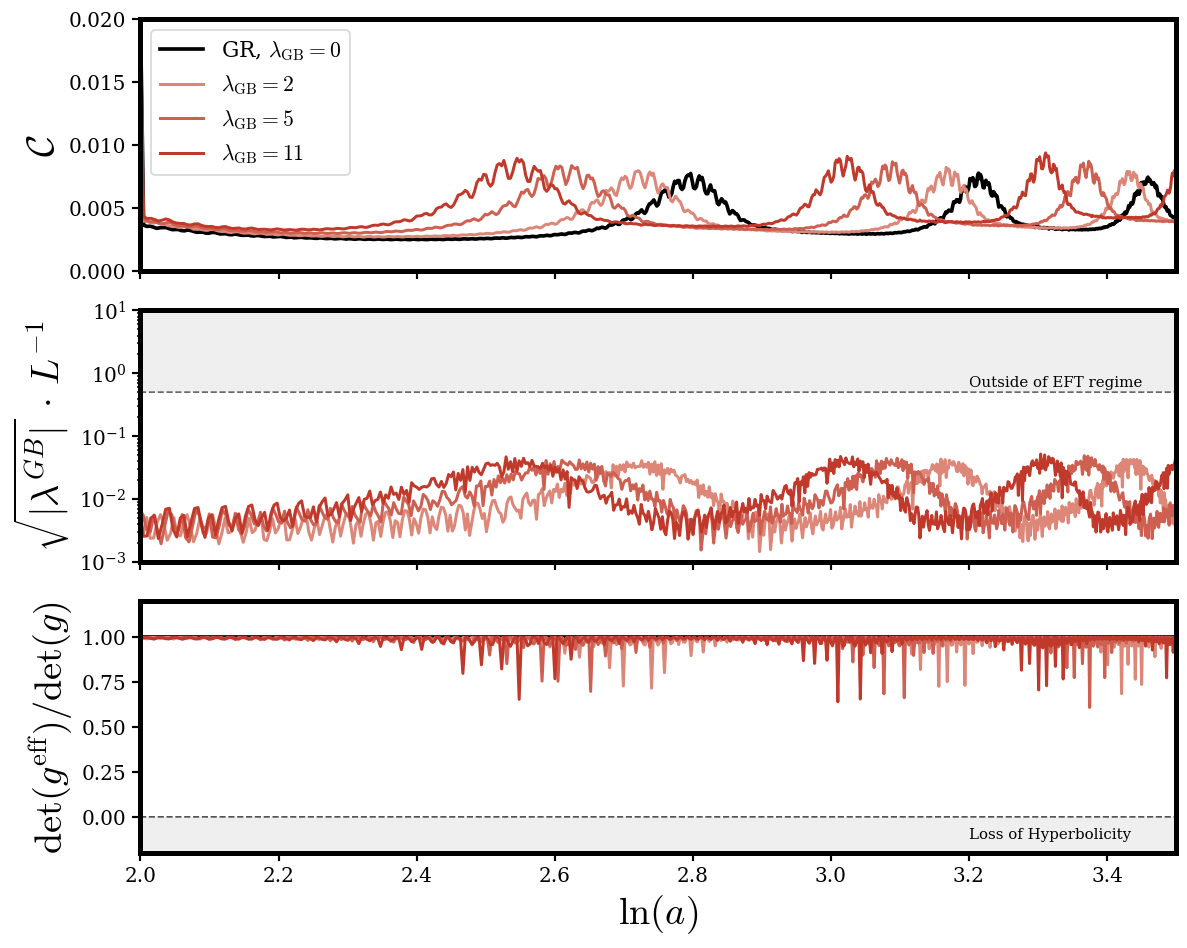

In [75]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Curves coloured by |lambda_GB|: light red = weak GB, dark red = strong GB.
# The darkest shade is "#c0392b" (matching the red used in Panel 4d's left
# axes) and is assigned to the *highest* selected |lambda_GB|. Ranking uses
# (|lgb|, lgb) so that lgb=0 is lightest and ties between +lgb and -lgb of
# the same magnitude are broken by sign. GR (lgb=0, g2=0) overrides to black.
from matplotlib.colors import LinearSegmentedColormap as _LSC
_unique_lgb = sorted({k[0] for k in PLOT4GB_KEYS}, key=lambda v: (abs(v), v))
_REDS_RAMP  = _LSC.from_list("_lgb_reds", ["#fee0d2", "#c0392b"])
_TAB10_GB   = plt.cm.tab10

def _color_for_lgb(lgb_val):
    if PLOT4GB_USE_TAB_COLORS:
        rank = _unique_lgb.index(lgb_val)
        return _TAB10_GB(rank % 10)
    if len(_unique_lgb) <= 1:
        return _REDS_RAMP(1.0)
    rank = _unique_lgb.index(lgb_val)
    frac = 0.30 + 0.70 * rank / (len(_unique_lgb) - 1)
    return _REDS_RAMP(frac)

if len(PLOT4GB_KEYS) == 0:
    print("No keys selected for Panel 4-GB.")
else:
    first = all_runs[PLOT4GB_KEYS[0]]
    r0    = first["eft"]["r"] if ("eft" in first) else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX_GB) if r0 is not None else None

    # Draw highlighted run first (behind everything) if requested
    _highlight_legend_handle_gb = None
    if PLOT4GB_HIGHLIGHT_KEY is not None and PLOT4GB_HIGHLIGHT_KEY in all_runs:
        _hk  = PLOT4GB_HIGHLIGHT_KEY
        _hr  = all_runs[_hk]
        _ho  = _hr["osc"]
        _he  = _hr.get("eft", None)
        _hx  = _hr["shifted_ln_a"]
        _hlgb, _hmu, _hbeta, _hamp, _hwidth, _hg2 = _hk
        _hlbl = rf"$\lambda_{{\rm GB}}={_hlgb:g}$"
        _hl, = axes[0].plot(_hx, _ho["C"], color=PLOT4GB_HIGHLIGHT_COLOR,
                     lw=PLOT4GB_HIGHLIGHT_LW, alpha=PLOT4GB_HIGHLIGHT_ALPHA,
                     zorder=1)
        _highlight_legend_handle_gb = (_hl, _hlbl)
        if _he is not None and r_mask is not None and "wc_lambda_bare" in _he:
            _hwc = np.nanmax(_he["wc_lambda_bare"][:, r_mask], axis=1)
            axes[1].plot(_hx, _hwc, color=PLOT4GB_HIGHLIGHT_COLOR,
                         lw=PLOT4GB_HIGHLIGHT_LW, alpha=PLOT4GB_HIGHLIGHT_ALPHA,
                         zorder=1)
        if _he is not None and "disc_GB" in _he and r_mask is not None:
            _hdisc = np.nanmin(_he["disc_GB"][:, r_mask], axis=1)
            axes[2].plot(_hx, _hdisc, color=PLOT4GB_HIGHLIGHT_COLOR,
                         lw=PLOT4GB_HIGHLIGHT_LW, alpha=PLOT4GB_HIGHLIGHT_ALPHA,
                         zorder=1)

    for i, key in enumerate(PLOT4GB_KEYS):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)
        lgb, mu, beta, amp, width, g2 = key

        is_gr   = (lgb == 0.0 and g2 == 0.0)
        lgb_str = rf"\lambda_{{\rm GB}}={lgb:g}"
        if is_gr:
            label = rf"GR, ${lgb_str}$"
        else:
            label = rf"${lgb_str}$"
        if is_gr:
            color = "k"
        elif PLOT4GB_USE_TAB_COLORS:
            color = _TAB10_GB(i % 10)
        else:
            color = _color_for_lgb(lgb)
        lw    = 2.2 if is_gr else 1.8

        x = run["shifted_ln_a"]

        # Panel 0: compactness
        axes[0].plot(x, osc["C"], color=color, lw=lw, label=label, zorder=5)

        # Panel 1: GB weak-coupling condition  max_r sqrt(|lambda'|) * L^{-1}
        if eft is not None and r_mask is not None and "wc_lambda_bare" in eft:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[1].plot(x, wc_lam, color=color, lw=lw, label=label, zorder=5)

        # Panel 2: GB hyperbolicity  min_r det(M_eff)
        if eft is not None and "disc_GB" in eft and r_mask is not None:
            disc_GB_min = np.nanmin(eft["disc_GB"][:, r_mask], axis=1)
            axes[2].plot(x, disc_GB_min, color=color, lw=lw, label=label, zorder=5)

    axes[0].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[0].set_ylabel(r"$\mathcal{C}$")
    axes[0].set_ylim(0, 0.02)
    #axes[0].set_ylim(0, 0.05)

    #axes[1].axhline(1.0, color="k", lw=1.0, ls=":", alpha=0.7)
    axes[1].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    #axes[1].set_ylabel(r"$\max_r\,\sqrt{|\lambda^{GB}|}\,\cdot\, L^{-1}$")
    axes[1].set_ylabel(r"$\sqrt{|\lambda^{GB}|}\,\cdot\, L^{-1}$")
    if PLOT4GB_WCC_LOG:
        axes[1].set_yscale("log")
        axes[1].set_ylim(*PLOT4GB_WCC_YLIM_LOG)
    else:
        axes[1].set_yscale("linear")
        axes[1].set_ylim(*PLOT4GB_WCC_YLIM_LINEAR)

    axes[2].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[2].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[2].set_ylim(-0.2,1.2)
    #axes[2].set_ylabel(r"$\min_r\,\det(M_{\rm eff})$")
    axes[2].set_ylabel(r"$\det(g^{\rm eff})/\det(g)$")
    axes[1].axhline(0.5, color="k", lw=1.0, ls="--", alpha=0.7)
    axes[1].axhspan(0.5, 10, facecolor="lightgrey", alpha=0.35, zorder=10)
    from matplotlib.transforms import blended_transform_factory
    _trans1 = blended_transform_factory(axes[1].transAxes, axes[1].transData)
    axes[1].text(0.8, 0.70, "Outside of EFT regime", transform=_trans1,va="center", ha="left", fontsize=9, color="black", zorder=11)

    axes[2].axhspan(0, -1, facecolor="lightgrey", alpha=0.35, zorder=10)
    from matplotlib.transforms import blended_transform_factory
    _trans1 = blended_transform_factory(axes[2].transAxes, axes[2].transData)
    axes[2].text(0.8, -0.1, "Loss of Hyperbolicity", transform=_trans1,va="center", ha="left", fontsize=9, color="black", zorder=11)
    #axes[1].axhline(0.1, color="k", lw=1.0, ls="--", alpha=0.7)
    # disc_GB scale differs from g2 det(g_eff); leave y-axis auto. Uncomment
    # the next line if you want a fixed range:
    # axes[2].set_ylim(0, 1.6)

    axes[2].set_xlabel(r"$\ln(a)$")
    axes[0].set_xlim(2, 3.5)

    # Build legend: main curves first, then highlighted run last
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _highlight_legend_handle_gb is not None:
        _handles.append(_highlight_legend_handle_gb[0])
        _labels.append(_highlight_legend_handle_gb[1])
    axes[0].legend(_handles, _labels, fontsize=13, ncol=1, loc="upper left")
    #axes[1].legend(fontsize=13, ncol=1, loc="upper left")
    #axes[2].legend(fontsize=13, ncol=1, loc="upper left")

    # Ensure axes borders (spines) are drawn on top of all data
    for ax in axes:
        ax.set_axisbelow(False)
        for spine in ax.spines.values():
            spine.set_zorder(20)

    fig.tight_layout()
    save_fig(fig, PLOT4GB_NAME)
    plt.show()

## Panel 4-MIX — Mixed $\lambda_{\rm GB}$ + $g_2$ runs with a unified EFT length scale

Sister of Panels 4 and 4-GB for runs where **both** $\lambda_{\rm GB}$ and $g_2$ are
non-zero. Three stacked panels (shared x-axis, aligned $\ln(a) \in [2,\,3.5]$):

1. Compactness $\mathcal{C}$
2. **Unified weak-coupling condition.** The EFT length scale is taken as the
   *shortest* of the two natural scales,
   $$L_{\rm eff}^{-1}(t, r) \;=\; \max\bigl(L^{-1}(t, r),\, \tilde L^{-1}(t, r)\bigr),$$
   and **both** couplings are compared against the same $L_{\rm eff}^{-1}$:
   $$\sqrt{|\lambda'|}\, L_{\rm eff}^{-1} \quad\text{(solid)},\qquad
     \sqrt{|g_2|}\, L_{\rm eff}^{-1} \quad\text{(dashed)}.$$
   Each is maximised over $r$ inside `R_WCC_MAX_MIX`. The reference horizontal
   line at $1$ marks the EFT validity bound for both channels.
3. Hyperbolicity diagnostics together: $\min_r \det(M_{\rm eff})$ (GB, solid)
   and $\min_r \det(g^{\rm eff})/\det(g)$ ($g_2$, dashed).

Curves are coloured in shades of purple — neither pure-blue ($g_2$) nor pure-red
(GB) — to signal the mixed regime. GR (`lgb=0, g2=0`) stays thick black.

In [37]:
### --- Panel 4-MIX selection (edit me) ---
PLOT4MIX_KEYS = select_runs(
    lgb   = [8],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [8],
)
PLOT4MIX_NAME = "rho_C_WCC_unified_hyp"

R_WCC_MAX_MIX           = 100.0   # only consider r in (0, R_WCC_MAX_MIX] for WCC / hyperbolicity
FORCE_EFT_RECOMPUTE_MIX = False   # True = ignore cached eft_diagnostics.npz and recompute

print(f"{len(PLOT4MIX_KEYS)} run(s) selected for Panel 4-MIX:")
for k in PLOT4MIX_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"], " (lgb, g2) =", (k[0], k[5]))

# Compute / load EFT diagnostics only for the selected runs
for k in PLOT4MIX_KEYS:
    d = all_runs[k]
    if "eft" in d and not FORCE_EFT_RECOMPUTE_MIX:
        continue
    run_dir  = d["run_dir"]
    eft_path = os.path.join(run_dir, "eft_diagnostics.npz")
    if os.path.exists(eft_path) and not FORCE_EFT_RECOMPUTE_MIX:
        d["eft"] = dict(np.load(eft_path, allow_pickle=True))
        print(f"  [EFT] loaded cache for {d['tag']}")
    else:
        sol_i    = np.load(os.path.join(run_dir, "solution.npy"))
        matter_i = ScalarMatter(scalar_mu, d["mu"])
        sv_i     = StateVector(matter_i)
        spacing_i = CubicSpacing(**CubicSpacing.get_parameters(
            d["run_r_max"], d["run_min_dr"], d["run_max_dr"]))
        grid_i   = Grid(spacing_i, sv_i)
        bg_i     = FlatSphericalBackground(grid_i.r)
        lgb_k, mu_k, beta_k, amp_k, width_k, g2_k = k
        params = (lgb_k, a_mg, b_mg, chi0, d["coupling"], g2_k)
        eft = get_eft_diagnostic(
            sol_i, d["t"], grid_i, bg_i,
            ScalarMatter(scalar_mu, d["mu"]),
            params,
        )
        np.savez(eft_path, **eft)
        d["eft"] = eft
        del sol_i
        verb = "recomputed" if FORCE_EFT_RECOMPUTE_MIX else "computed"
        print(f"  [EFT] {verb} & cached for {d['tag']}")

1 run(s) selected for Panel 4-MIX:
  (8.0, 0.08, 0.0, -0.02, 3.0, 8.0)  coupling= quadratic_0  (lgb, g2) = (8.0, 8.0)
  [EFT] computed & cached for lgb8_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_g28


  (lgb=8, g2=8):  L^-1 wins in 98.9% of (t,r),  L_tilde^-1 wins in  1.1%  ->  L^-1 (GB) dominates
     at WCC-binding radius:  lambda' channel uses L^-1 in 93.2% of t,  g2 channel uses L^-1 in 98.0% of t
  saved rho_C_WCC_unified_hyp.pdf and rho_C_WCC_unified_hyp.png


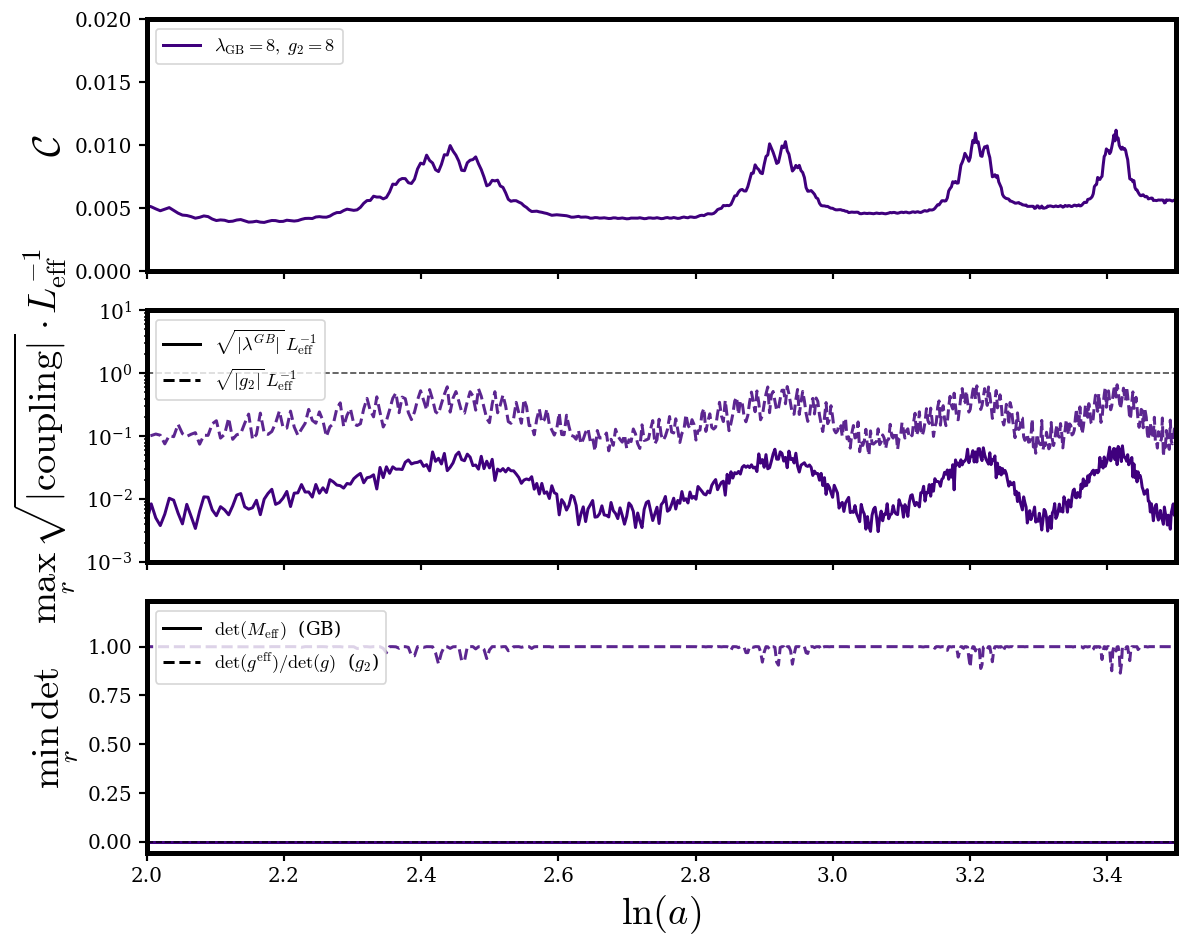

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Mixed lgb + g2 regime: use a multi-stop purple ramp (ColorBrewer-style) so
# adjacent runs are visually distinct even when several curves are overlaid.
# Within a run: solid = lambda' channel; dashed = g2 channel (panels 1 and 2).
from matplotlib.colors import LinearSegmentedColormap as _LSC
from matplotlib.lines  import Line2D
_PURPLES_RAMP = _LSC.from_list(
    "_mix_purples",
    ["#dadaeb", "#9e9ac8", "#6a51a3", "#3f007d"],
)

# Sort selected keys by a combined "coupling strength" (max(|lgb|, |g2|), then
# |lgb|, then |g2|) so that the darkest purple is the strongest mixed run.
_keys_sorted = sorted(
    PLOT4MIX_KEYS,
    key=lambda k: (max(abs(k[0]), abs(k[5])), abs(k[0]), abs(k[5])),
)
_n_mix = len(_keys_sorted)

def _color_for_mix(idx):
    if _n_mix <= 1:
        return _PURPLES_RAMP(1.0)
    frac = 0.20 + 0.80 * idx / (_n_mix - 1)
    return _PURPLES_RAMP(frac)


if _n_mix == 0:
    print("No keys selected for Panel 4-MIX.")
else:
    first = all_runs[_keys_sorted[0]]
    r0    = first["eft"]["r"] if ("eft" in first) else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX_MIX) if r0 is not None else None

    for idx, key in enumerate(_keys_sorted):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)
        lgb, mu, beta, amp, width, g2 = key

        is_gr = (lgb == 0.0 and g2 == 0.0)
        label = (rf"GR" if is_gr else
                 rf"$\lambda_{{\rm GB}}={lgb:g},\;g_2={g2:g}$")
        color = "k" if is_gr else _color_for_mix(idx)
        lw    = 2.2 if is_gr else 1.8

        x = run["shifted_ln_a"]

        # Panel 0: compactness
        axes[0].plot(x, osc["C"], color=color, lw=lw, label=label)

        # Panel 1: unified weak-coupling condition. L_eff^{-1} = max(L^{-1}, L_tilde^{-1}).
        if eft is not None and r_mask is not None and all(
            k_ in eft for k_ in ("L_inv", "L_tilde_inv", "lambda_prime_bare", "g2_bare")
        ):
            L_inv_full     = eft["L_inv"]
            L_tilde_inv_f  = eft["L_tilde_inv"]
            L_eff_inv      = np.maximum(L_inv_full, L_tilde_inv_f)  # (T, N)
            wc_lam_unified = np.sqrt(np.maximum(eft["lambda_prime_bare"], 0.0)) * L_eff_inv
            wc_g2_unified  = np.sqrt(np.maximum(eft["g2_bare"],            0.0)) * L_eff_inv

            wc_lam_max = np.nanmax(wc_lam_unified[:, r_mask], axis=1)
            wc_g2_max  = np.nanmax(wc_g2_unified[:,  r_mask], axis=1)
            axes[1].plot(x, wc_lam_max, color=color, lw=lw, ls="-",  label=label)
            axes[1].plot(x, wc_g2_max,  color=color, lw=lw, ls="--", alpha=0.85)

            # ── Which length scale is actually setting L_eff^{-1}? ──
            # Global statistic over the (t, r in r_mask) region.
            L_inv_m  = L_inv_full[:,    r_mask]
            L_til_m  = L_tilde_inv_f[:, r_mask]
            frac_GB  = float(np.mean(L_inv_m > L_til_m))
            frac_g2  = float(np.mean(L_til_m > L_inv_m))
            if frac_GB > 0.8:
                verdict = "L^-1 (GB) dominates"
            elif frac_g2 > 0.8:
                verdict = "L_tilde^-1 (g2) dominates"
            else:
                verdict = "mixed (neither dominates >80%)"
            # Same check, but only at the radius that *binds* each WCC channel
            # (i.e. where sqrt(|coupling|)*L_eff^{-1} is maximised) per time.
            T_steps   = L_inv_m.shape[0]
            t_idx_    = np.arange(T_steps)
            r_idx_lam = np.nanargmax(wc_lam_unified[:, r_mask], axis=1)
            r_idx_g2  = np.nanargmax(wc_g2_unified[:,  r_mask], axis=1)
            bind_lam_GB = float(np.mean(
                L_inv_m[t_idx_, r_idx_lam] > L_til_m[t_idx_, r_idx_lam]))
            bind_g2_GB  = float(np.mean(
                L_inv_m[t_idx_, r_idx_g2]  > L_til_m[t_idx_, r_idx_g2]))
            print(
                f"  (lgb={lgb:g}, g2={g2:g}):  "
                f"L^-1 wins in {frac_GB:5.1%} of (t,r),  "
                f"L_tilde^-1 wins in {frac_g2:5.1%}  ->  {verdict}\n"
                f"     at WCC-binding radius:  "
                f"lambda' channel uses L^-1 in {bind_lam_GB:5.1%} of t,  "
                f"g2 channel uses L^-1 in {bind_g2_GB:5.1%} of t"
            )

        # Panel 2: hyperbolicity — disc_GB (solid) and disc_g2 (dashed) together.
        if eft is not None and r_mask is not None:
            if "disc_GB" in eft:
                disc_GB_min = np.nanmin(eft["disc_GB"][:, r_mask], axis=1)
                axes[2].plot(x, disc_GB_min, color=color, lw=lw, ls="-",  label=label)
            if "disc_g2" in eft:
                disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
                axes[2].plot(x, disc_g2_min, color=color, lw=lw, ls="--", alpha=0.85)

    axes[0].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[0].set_ylabel(r"$\mathcal{C}$")
    axes[0].set_ylim(0, 0.02)

    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.7)
    axes[1].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[1].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\, L_{\rm eff}^{-1}$")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-3, 1e1)

    axes[2].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[2].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[2].set_ylabel(r"$\min_r\,\det$")

    axes[2].set_xlabel(r"$\ln(a)$")
    axes[0].set_xlim(2, 3.5)

    # Per-run colour legend on the compactness panel.
    axes[0].legend(fontsize=11, ncol=1, loc="upper left")

    # Linestyle legends on the WCC and hyperbolicity panels (coupling channel).
    style_wcc = [
        Line2D([0], [0], color="k", ls="-",  lw=1.8,
               label=r"$\sqrt{|\lambda^{GB}|}\,L_{\rm eff}^{-1}$"),
        Line2D([0], [0], color="k", ls="--", lw=1.8,
               label=r"$\sqrt{|g_2|}\,L_{\rm eff}^{-1}$"),
    ]
    axes[1].legend(handles=style_wcc, fontsize=11, loc="upper left")

    style_hyp = [
        Line2D([0], [0], color="k", ls="-",  lw=1.8,
               label=r"$\det(M_{\rm eff})$  (GB)"),
        Line2D([0], [0], color="k", ls="--", lw=1.8,
               label=r"$\det(g^{\rm eff})/\det(g)$  ($g_2$)"),
    ]
    axes[2].legend(handles=style_hyp, fontsize=11, loc="upper left")

    fig.tight_layout()
    save_fig(fig, PLOT4MIX_NAME)
    plt.show()

## Panel 4-MIX-L — Mixed runs: compactness, unified WCC and the two inverse EFT length scales

Identical to Panel 4-MIX in panels 0 and 1, but the bottom panel now reports the two
**inverse** EFT length scales as functions of $\ln(a)$:

- $\max_r L^{-1}(t, r)$ — the largest GB inverse length scale (solid)
- $\max_r \tilde L^{-1}(t, r)$ — the largest $g_2$ inverse length scale (dashed)

both restricted to $r \le R_{\rm WCC,\,MIX}$. The max-over-$r$ corresponds to the
*shortest* available length scale, so the two curves shown here are exactly the
quantities competing in $L_{\rm eff}^{-1} = \max(L^{-1}, \tilde L^{-1})$ used in panel 1.
For each run, whichever curve sits higher is the scale that wins the max and sets
$L_{\rm eff}^{-1}$. The panel reuses `PLOT4MIX_KEYS`, `R_WCC_MAX_MIX` etc.; re-run the
Panel 4-MIX selection cell first if you change the parameters.

  saved rho_C_WCC_unified_hyp_lengthscales.pdf and rho_C_WCC_unified_hyp_lengthscales.png


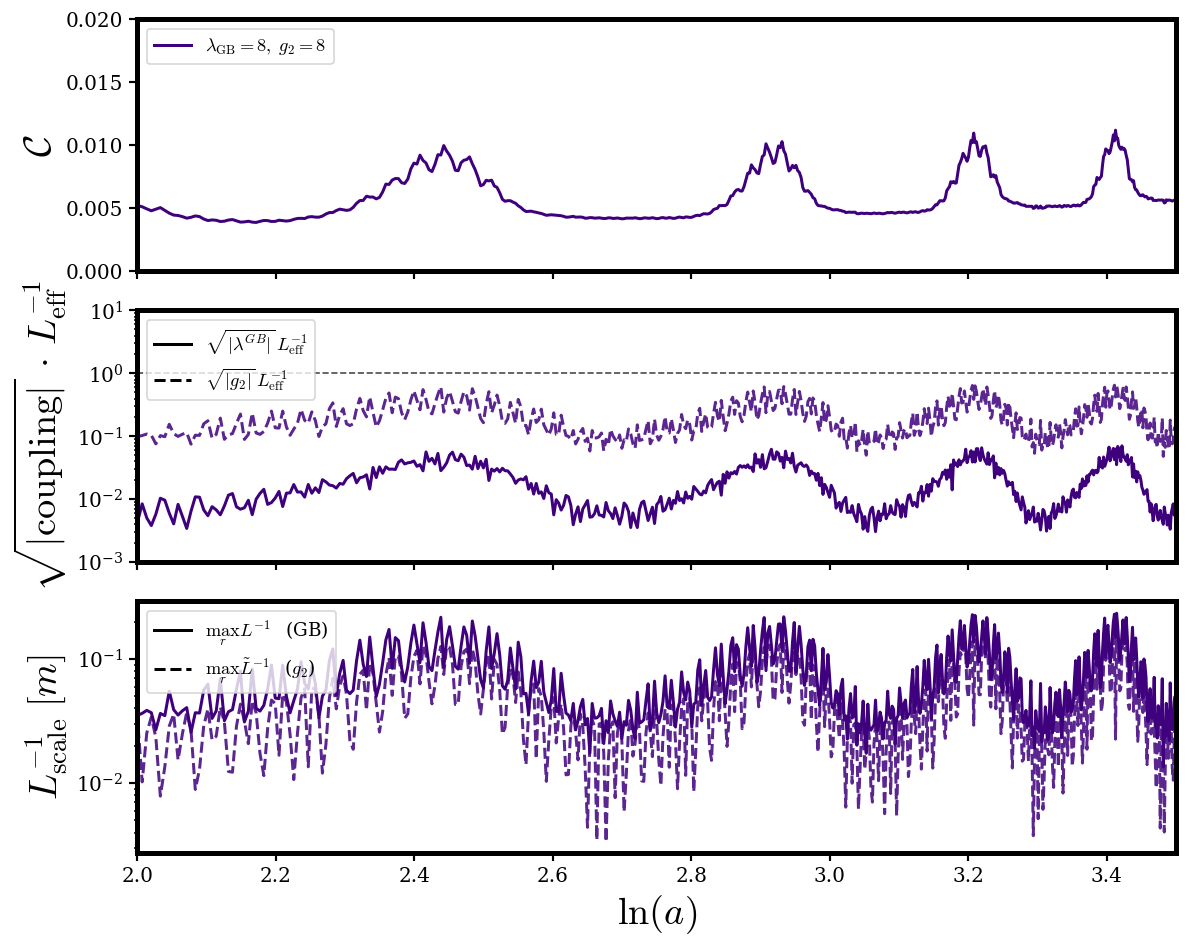

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Reuse Panel 4-MIX selection (PLOT4MIX_KEYS) and helpers. Both `_PURPLES_RAMP`
# and `_color_for_mix` come from the Panel 4-MIX plot cell; re-define them here
# defensively so this cell stands on its own if that cell was not executed.
from matplotlib.colors import LinearSegmentedColormap as _LSC
from matplotlib.lines  import Line2D

try:
    _PURPLES_RAMP        # type: ignore[name-defined]
    _color_for_mix       # type: ignore[name-defined]
    _keys_sorted         # type: ignore[name-defined]
    _n_mix               # type: ignore[name-defined]
except NameError:
    _PURPLES_RAMP = _LSC.from_list(
        "_mix_purples",
        ["#dadaeb", "#9e9ac8", "#6a51a3", "#3f007d"],
    )
    _keys_sorted = sorted(
        PLOT4MIX_KEYS,
        key=lambda k: (max(abs(k[0]), abs(k[5])), abs(k[0]), abs(k[5])),
    )
    _n_mix = len(_keys_sorted)

    def _color_for_mix(idx):
        if _n_mix <= 1:
            return _PURPLES_RAMP(1.0)
        frac = 0.20 + 0.80 * idx / (_n_mix - 1)
        return _PURPLES_RAMP(frac)


if _n_mix == 0:
    print("No keys selected for Panel 4-MIX-L.")
else:
    first = all_runs[_keys_sorted[0]]
    r0    = first["eft"]["r"] if ("eft" in first) else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX_MIX) if r0 is not None else None

    for idx, key in enumerate(_keys_sorted):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)
        lgb, mu, beta, amp, width, g2 = key

        is_gr = (lgb == 0.0 and g2 == 0.0)
        label = (rf"GR" if is_gr else
                 rf"$\lambda_{{\rm GB}}={lgb:g},\;g_2={g2:g}$")
        color = "k" if is_gr else _color_for_mix(idx)
        lw    = 2.2 if is_gr else 1.8

        x = run["shifted_ln_a"]

        # Panel 0: compactness
        axes[0].plot(x, osc["C"], color=color, lw=lw, label=label)

        # Panel 1: unified weak-coupling condition. L_eff^{-1} = max(L^{-1}, L_tilde^{-1}).
        if eft is not None and r_mask is not None and all(
            k_ in eft for k_ in ("L_inv", "L_tilde_inv", "lambda_prime_bare", "g2_bare")
        ):
            L_eff_inv      = np.maximum(eft["L_inv"], eft["L_tilde_inv"])
            wc_lam_unified = np.sqrt(np.maximum(eft["lambda_prime_bare"], 0.0)) * L_eff_inv
            wc_g2_unified  = np.sqrt(np.maximum(eft["g2_bare"],            0.0)) * L_eff_inv

            wc_lam_max = np.nanmax(wc_lam_unified[:, r_mask], axis=1)
            wc_g2_max  = np.nanmax(wc_g2_unified[:,  r_mask], axis=1)
            axes[1].plot(x, wc_lam_max, color=color, lw=lw, ls="-",  label=label)
            axes[1].plot(x, wc_g2_max,  color=color, lw=lw, ls="--", alpha=0.85)

        # Panel 2: the two inverse EFT length scales (shortest length <=> largest
        # L^{-1}, so take the max over r_mask). These are exactly the two scales
        # competing inside L_eff^{-1} = max(L^{-1}, tilde L^{-1}) in panel 1.
        if eft is not None and r_mask is not None:
            if "L_inv" in eft:
                L_inv_max_t = np.nanmax(eft["L_inv"][:, r_mask], axis=1)
                axes[2].plot(x, L_inv_max_t, color=color, lw=lw, ls="-",  label=label)
            if "L_tilde_inv" in eft:
                L_til_inv_max_t = np.nanmax(eft["L_tilde_inv"][:, r_mask], axis=1)
                axes[2].plot(x, L_til_inv_max_t, color=color, lw=lw, ls="--", alpha=0.85)

    axes[0].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[0].set_ylabel(r"$\mathcal{C}$")
    axes[0].set_ylim(0, 0.02)

    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.7)
    axes[1].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    #axes[1].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\, L_{\rm eff}^{-1}$")
    axes[1].set_ylabel(r"$\sqrt{|\mathrm{coupling}|}\,\cdot\, L_{\rm eff}^{-1}$")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-3, 1e1)

    axes[2].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[2].set_ylabel(r"$L_{\rm scale}^{-1}\;[m]$")
    axes[2].set_yscale("log")

    axes[2].set_xlabel(r"$\ln(a)$")
    axes[0].set_xlim(2, 3.5)

    # Per-run colour legend on the compactness panel.
    axes[0].legend(fontsize=11, ncol=1, loc="upper left")

    # Linestyle legends: WCC channel on axes[1], length-scale identity on axes[2].
    style_wcc = [
        Line2D([0], [0], color="k", ls="-",  lw=1.8,
               label=r"$\sqrt{|\lambda^{GB}|}\,L_{\rm eff}^{-1}$"),
        Line2D([0], [0], color="k", ls="--", lw=1.8,
               label=r"$\sqrt{|g_2|}\,L_{\rm eff}^{-1}$"),
    ]
    axes[1].legend(handles=style_wcc, fontsize=11, loc="upper left")

    style_lengths = [
        Line2D([0], [0], color="k", ls="-",  lw=1.8,
               label=r"$\max_r L^{-1}$  (GB)"),
        Line2D([0], [0], color="k", ls="--", lw=1.8,
               label=r"$\max_r \tilde L^{-1}$  ($g_2$)"),
    ]
    axes[2].legend(handles=style_lengths, fontsize=11, loc="upper left")

    fig.tight_layout()
    save_fig(fig, PLOT4MIX_NAME + "_lengthscales")
    plt.show()

## Panel 6 — GW spectrum benchmark (Antusch-Cefala-Orani 2017, Fig. 2)

Reproduces the paper's Fig. 2 ($w=0$, single cosine oscillon source, integrated to $a_f=3$) using the
`Omega_GW` semi-analytic model from `bssn.GWSignal`. One curve per asymmetry $\Delta$ in the
list below; the spectrum is plotted vs $k_{\rm phys}/\omega_{\rm osc}$ in log-log space.

In [76]:
### --- Panel 6 selection (edit me) ---
from bssn.GWSignal import Omega_GW

# Paper defaults (Antusch-Cefala-Orani 2017, eqs. 4.6-4.7), in units m_Pl = 1
P6_A_PAPER     = 0.05
P6_OMEGA_PAPER = 1.0
P6_R_PAPER     = 1.0
P6_H0_PAPER    = 0.002
P6_V_PAPER     = (100.0 * P6_R_PAPER) ** 3
P6_N_PAPER     = 1
P6_W_PAPER     = 0.0          # matter dominated (paper Fig. 2)
P6_A_F_TARGET  = 3.0          # paper integrates Fig. 2 to a_f = 3

P6_N_ANGLES = 30              # paper uses ~30
P6_N_TAU    = 5000            # raise to 10000 for better low-k resolution
P6_SEED     = 42
P6_NK       = 120             # number of comoving k-grid points

# Which asymmetry values to plot (one curve each)
P6_DELTAS = [0.4]
P6_COLORS = ['C3']            # one entry per delta in P6_DELTAS

P6_NAME = "GW_spectrum_benchmark"

# Invert eq. 4.13 to find t_end such that a(t_end) = A_F_TARGET (matter dom.)
#   a(t) = (9/4)^{1/3} * (2/3 + H0 t)^{2/3}
_pref6 = (9.0 / 4.0) ** (1.0 / 3.0)
P6_T_END = ((P6_A_F_TARGET / _pref6) ** 1.5 - 2.0 / 3.0) / P6_H0_PAPER

# Comoving k-grid covers k_phys/omega_osc in [0.4, 3.0]; default in Omega_GW
# would cut off the peak at k_phys/omega_osc ~ 2.
P6_K_GRID = np.logspace(
    np.log10(0.4 * P6_OMEGA_PAPER * P6_A_F_TARGET),
    np.log10(3.0 * P6_OMEGA_PAPER * P6_A_F_TARGET),
    P6_NK,
)

print(f"Panel 6: {len(P6_DELTAS)} spectrum/spectra; t_end = {P6_T_END:.2e} (a_f target = {P6_A_F_TARGET})")
assert len(P6_COLORS) >= len(P6_DELTAS), "need at least one colour per Delta"

Panel 6: 1 spectrum/spectra; t_end = 1.40e+03 (a_f target = 3.0)


  saved GW_field_power_spectrum.pdf and GW_field_power_spectrum.png


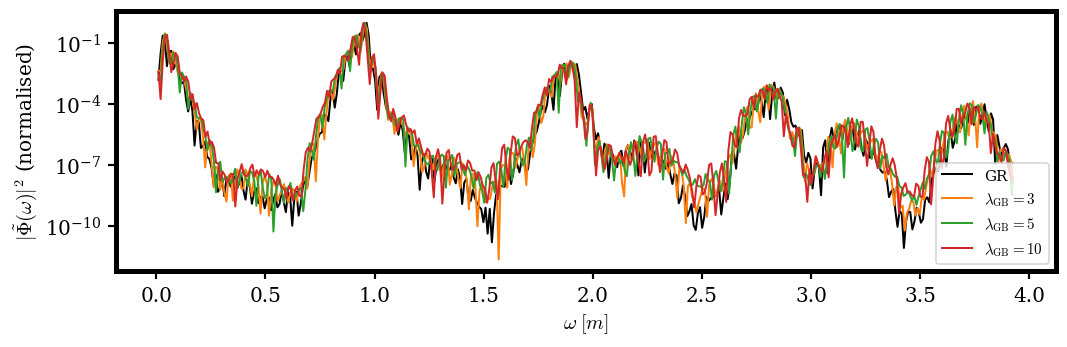


GR  field harmonics  (fundamental omega_0 = 0.0292):
      omega_0: omega = 0.0292,  omega_n/omega_1 = 1.000,  A_n/A_dom = 0.485
    2*omega_0: omega = 0.9051,  omega_n/omega_1 = 31.000,  A_n/A_dom = 0.319
    3*omega_0: omega = 0.9343,  omega_n/omega_1 = 32.000,  A_n/A_dom = 0.550
    4*omega_0: omega = 0.9635,  omega_n/omega_1 = 33.000,  A_n/A_dom = 1.000

$\lambda_{\rm GB}=3$  field harmonics  (fundamental omega_0 = 0.0390):
      omega_0: omega = 0.0390,  omega_n/omega_1 = 1.000,  A_n/A_dom = 0.550
    2*omega_0: omega = 0.9160,  omega_n/omega_1 = 23.500,  A_n/A_dom = 0.498
    3*omega_0: omega = 0.9550,  omega_n/omega_1 = 24.500,  A_n/A_dom = 1.000

$\lambda_{\rm GB}=5$  field harmonics  (fundamental omega_0 = 0.0390):
      omega_0: omega = 0.0390,  omega_n/omega_1 = 1.000,  A_n/A_dom = 0.540
    2*omega_0: omega = 0.9171,  omega_n/omega_1 = 23.500,  A_n/A_dom = 0.475
    3*omega_0: omega = 0.9561,  omega_n/omega_1 = 24.500,  A_n/A_dom = 1.000

$\lambda_{\rm GB}=10$  field harmo

In [77]:
# Field power spectrum |Phi(omega)|^2 (no squaring), overlaid for every selected run.
# Built inline because OscillonRun.fft_source_spectrum squares Phi before the FFT.
# Uses select_runs(...) like the other panels.
from bssn.GWSignal import OscillonRun, PHI_MIN
from matplotlib import cm

### --- Field-spectrum selection (edit me) ---
PLOT_FPS_KEYS = select_runs(
    lgb   = [0,3,5,10],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0],
)

FPS_STABLE_WINDOW = (2.0, 3.5)
FPS_N_HARMONICS   = 5        # mirrors PSPS_N_HARMONICS in the cell below
FPS_PROM_RATIO    = 0.05     # 5% prominence cut, same as fft_source_spectrum default
FPS_NAME          = "GW_field_power_spectrum"


def _fps_field_spectrum(run):
    """|FFT(Phi - PHI_MIN)|^2 over the stable window; returns (omega, amp, amp_norm)."""
    mask = run._stable_mask()
    if np.sum(mask) < 16:
        mask = np.ones_like(mask)
    t   = run.t[mask]
    sig = run.u_r0_t[mask] - PHI_MIN
    sig = sig - np.mean(sig)                       # remove DC (asymmetric potential)
    n   = sig.size
    sig_w  = sig * np.hanning(n)                   # Hann window -> reduce spectral leakage
    dt     = float(np.mean(np.diff(t)))
    freqs  = np.fft.rfftfreq(n, d=dt)
    amps   = np.abs(np.fft.rfft(sig_w)) ** 2
    omegas = 2.0 * np.pi * freqs                   # angular frequency, units of m
    omegas, amps = omegas[1:], amps[1:]            # drop the zero-frequency bin
    amps_norm = amps / max(amps.max(), 1e-30)
    return omegas, amps, amps_norm


def _fps_find_peaks(omegas, amps, n_harmonics, prominence_ratio):
    """Local maxima above prominence_ratio*max, top-N by amplitude."""
    peaks = []
    if amps.size >= 3:
        local = (amps[1:-1] > amps[:-2]) & (amps[1:-1] > amps[2:])
        idx_local = np.where(local)[0] + 1
        if idx_local.size:
            amp_max = amps[idx_local].max()
            idx_strong = idx_local[amps[idx_local] > prominence_ratio * amp_max]
            order = np.argsort(amps[idx_strong])[::-1][:n_harmonics]
            for i in idx_strong[order]:
                peaks.append((omegas[i], amps[i]))
    if not peaks:
        i = int(np.argmax(amps))
        peaks.append((omegas[i], amps[i]))
    return np.asarray(peaks)


def _fps_label(key):
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "GR"
    if lgb != 0.0 and g2 != 0.0:
        return rf"$\lambda_{{\rm GB}}={lgb:g},\ g_2={g2:g}$"
    if lgb != 0.0:
        return rf"$\lambda_{{\rm GB}}={lgb:g}$"
    return rf"$g_2={g2:g}$"


def _fps_color(idx, key):
    """GR -> black; everything else cycles through tab10 in selection order."""
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "k"
    return cm.tab10(idx % 10)


if len(PLOT_FPS_KEYS) == 0:
    print("No keys selected for field-spectrum panel.")
else:
    # Build OscillonRun objects from each selected run's run_dir.
    fps_runs = {}
    for k in PLOT_FPS_KEYS:
        d   = all_runs[k]
        run = OscillonRun(d["run_dir"], label=_fps_label(k),
                          stable_window=FPS_STABLE_WINDOW)
        _ = run.extract_all(verbose=False)
        fps_runs[k] = run

    # Backwards-compat aliases for the source-spectrum cell below.
    _gr_keys   = [k for k in PLOT_FPS_KEYS if (k[0] == 0.0 and k[5] == 0.0)]
    _esgb_keys = [k for k in PLOT_FPS_KEYS if not (k[0] == 0.0 and k[5] == 0.0)]
    if _gr_keys:
        fps_gr_run = fps_runs[_gr_keys[0]]
    if _esgb_keys:
        fps_esgb_run = fps_runs[_esgb_keys[0]]

    # Compute spectra and plot.
    fps_data = {k: _fps_field_spectrum(fps_runs[k]) for k in PLOT_FPS_KEYS}

    fig, ax = plt.subplots(figsize=(9, 3))
    for idx, k in enumerate(PLOT_FPS_KEYS):
        omegas, _, amps_norm = fps_data[k]
        ax.semilogy(omegas, amps_norm, lw=1.2,
                    color=_fps_color(idx, k), label=fps_runs[k].label)

    ax.set_xlabel(r"$\omega \;[m]$", fontsize=12)
    ax.set_ylabel(r"$|\tilde{\Phi}(\omega)|^2$ (normalised)", fontsize=12)
    #ax.set_title(r"Field power spectrum  $|\tilde{\Phi}(\omega)|^2$")
    ax.legend(fontsize=9)
    fig.tight_layout()
    save_fig(fig, FPS_NAME)
    plt.grid(False)
    plt.show()

    # Harmonic table per run: top-N peaks (by amplitude), re-sorted by omega so
    # omega_n/omega_1 tells us whether they're integer multiples of the fundamental.
    for k in PLOT_FPS_KEYS:
        omegas_f, amps_f, _ = fps_data[k]
        peaks_top = _fps_find_peaks(omegas_f, amps_f, FPS_N_HARMONICS, FPS_PROM_RATIO)
        peaks_ord = peaks_top[np.argsort(peaks_top[:, 0])]
        omega_1   = float(peaks_ord[0, 0])
        A_dom     = float(peaks_top[np.argmax(peaks_top[:, 1]), 1])
        print(f"\n{fps_runs[k].label}  field harmonics  "
              f"(fundamental omega_0 = {omega_1:.4f}):")
        for n, (omega_n, amp_n) in enumerate(peaks_ord):
            label_str   = "omega_0" if n == 0 else f"{n+1}*omega_0"
            ratio_omega = omega_n / omega_1
            ratio_amp   = (amp_n / A_dom) ** 0.5
            print(f"  {label_str:>11s}: omega = {omega_n:.4f},  "
                  f"omega_n/omega_1 = {ratio_omega:.3f},  "
                  f"A_n/A_dom = {ratio_amp:.3f}")

  saved GW_source_power_spectrum.pdf and GW_source_power_spectrum.png


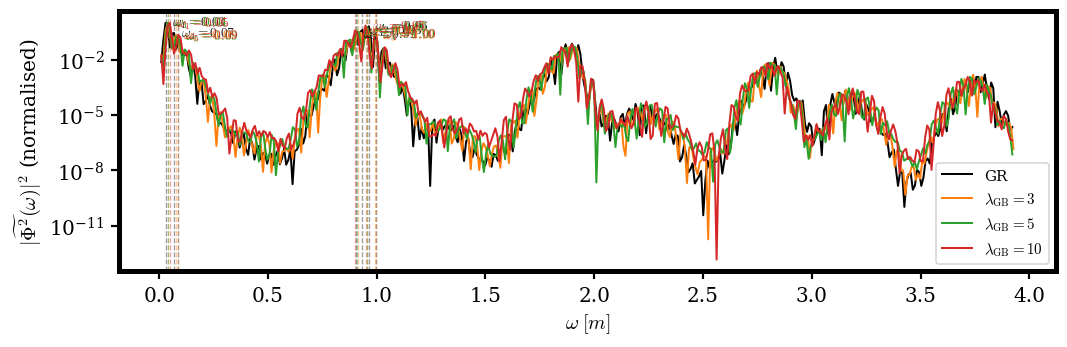


GR  harmonics:
  omega_1 = 0.0292,  A_n/A_1 = 1.000,  GW weight (A_n/A_1)^4 = 1.0000
  omega_2 = 0.9635,  A_n/A_1 = 0.808,  GW weight (A_n/A_1)^4 = 0.4256
  omega_3 = 0.9343,  A_n/A_1 = 0.641,  GW weight (A_n/A_1)^4 = 0.1691
  omega_4 = 0.0681,  A_n/A_1 = 0.532,  GW weight (A_n/A_1)^4 = 0.0802
  omega_5 = 0.9051,  A_n/A_1 = 0.498,  GW weight (A_n/A_1)^4 = 0.0617

$\lambda_{\rm GB}=3$  harmonics:
  omega_1 = 0.0390,  A_n/A_1 = 1.000,  GW weight (A_n/A_1)^4 = 1.0000
  omega_2 = 0.9550,  A_n/A_1 = 0.743,  GW weight (A_n/A_1)^4 = 0.3042
  omega_3 = 0.9160,  A_n/A_1 = 0.572,  GW weight (A_n/A_1)^4 = 0.1073
  omega_4 = 0.0780,  A_n/A_1 = 0.466,  GW weight (A_n/A_1)^4 = 0.0470
  omega_5 = 0.9939,  A_n/A_1 = 0.452,  GW weight (A_n/A_1)^4 = 0.0417

$\lambda_{\rm GB}=5$  harmonics:
  omega_1 = 0.0390,  A_n/A_1 = 1.000,  GW weight (A_n/A_1)^4 = 1.0000
  omega_2 = 0.9561,  A_n/A_1 = 0.772,  GW weight (A_n/A_1)^4 = 0.3558
  omega_3 = 0.9074,  A_n/A_1 = 0.583,  GW weight (A_n/A_1)^4 = 0.1156
  omeg

In [78]:
# Source power spectrum |Phi^2(omega)|^2 overlaid for every selected run.
# Uses select_runs(...) like the other panels.
from bssn.GWSignal import OscillonRun
from matplotlib import cm

### --- Source-spectrum selection (edit me) ---
PLOT_PSPS_KEYS = select_runs(
    lgb   = [0, 3, 5, 10],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0],
)

PSPS_STABLE_WINDOW = (2.0, 3.5)
PSPS_N_HARMONICS   = 5
PSPS_NAME          = "GW_source_power_spectrum"


def _psps_label(key):
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "GR"
    if lgb != 0.0 and g2 != 0.0:
        return rf"$\lambda_{{\rm GB}}={lgb:g},\ g_2={g2:g}$"
    if lgb != 0.0:
        return rf"$\lambda_{{\rm GB}}={lgb:g}$"
    return rf"$g_2={g2:g}$"


def _psps_color(idx, key):
    """GR -> black; everything else cycles through tab10 in selection order."""
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "k"
    return cm.tab10(idx % 10)


if len(PLOT_PSPS_KEYS) == 0:
    print("No keys selected for source-spectrum panel.")
else:
    # Re-use already-loaded runs from the field-spectrum / Panel 7 cells when
    # the same key has already been built; otherwise build fresh OscillonRuns.
    psps_runs = {}
    for k in PLOT_PSPS_KEYS:
        try:
            psps_runs[k] = fps_runs[k]    # type: ignore[name-defined]
            continue
        except (NameError, KeyError):
            pass
        try:
            psps_runs[k] = p7_runs[k]     # type: ignore[name-defined]
            continue
        except (NameError, KeyError):
            pass
        d   = all_runs[k]
        run = OscillonRun(d["run_dir"], label=_psps_label(k),
                          stable_window=PSPS_STABLE_WINDOW)
        _ = run.extract_all(verbose=False)
        psps_runs[k] = run
    # Refresh labels so they match the auto-generated style even when the
    # OscillonRun was originally built with a different label (e.g. Panel 7).
    for k, run in psps_runs.items():
        run.label = _psps_label(k)

    # Backwards-compat aliases used by the field-spectrum cell above's fallback chain.
    _gr_keys   = [k for k in PLOT_PSPS_KEYS if (k[0] == 0.0 and k[5] == 0.0)]
    _esgb_keys = [k for k in PLOT_PSPS_KEYS if not (k[0] == 0.0 and k[5] == 0.0)]
    if _gr_keys:
        psps_gr_run = psps_runs[_gr_keys[0]]
    if _esgb_keys:
        psps_esgb_run = psps_runs[_esgb_keys[0]]

    fig, ax = plt.subplots(figsize=(9, 3))
    for idx, k in enumerate(PLOT_PSPS_KEYS):
        psps_runs[k].plot_source_power_spectrum(
            ax=ax, n_harmonics=PSPS_N_HARMONICS, color=_psps_color(idx, k),
        )

    #ax.set_title(r"Source power spectrum  $|\widetilde{\Phi^2}(\omega)|^2$")
    fig.tight_layout()
    save_fig(fig, PSPS_NAME)
    plt.grid(False)
    plt.show()

    for k in PLOT_PSPS_KEYS:
        run = psps_runs[k]
        omegas, amps, peaks = run.fft_source_spectrum(n_harmonics=PSPS_N_HARMONICS)
        A_dominant = peaks[0, 1]   # dominant peak power
        print(f"\n{run.label}  harmonics:")
        for i, (omega_n, amp_n) in enumerate(peaks):
            ratio = (amp_n / A_dominant) ** 0.5   # sqrt: amps are power
            print(f"  omega_{i+1} = {omega_n:.4f},  A_n/A_1 = {ratio:.3f},  "
                  f"GW weight (A_n/A_1)^4 = {ratio**4:.4f}")

  saved GW_spectrum_benchmark.pdf and GW_spectrum_benchmark.png


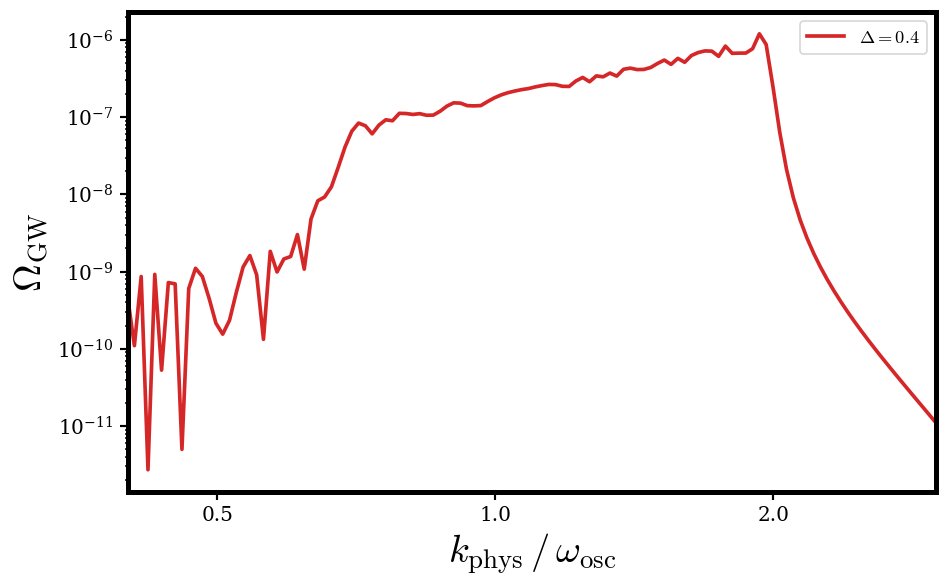

In [94]:
p6_results = {}

for Delta_p in P6_DELTAS:
    res = Omega_GW(
        A=P6_A_PAPER, R=P6_R_PAPER,
        omega_source=P6_OMEGA_PAPER, H0=P6_H0_PAPER,
        w=P6_W_PAPER, Delta=Delta_p, N=P6_N_PAPER, V=P6_V_PAPER,
        n_angles=P6_N_ANGLES, n_tau=P6_N_TAU,
        k_grid=P6_K_GRID,
        tau_window=(0.0, P6_T_END),
        seed=P6_SEED,
        harmonics='cosine',
    )
    p6_results[Delta_p] = res

print(f"Computed Omega_GW for {len(p6_results)} Delta values: {list(p6_results.keys())}")

  saved GW_spectrum_benchmark.pdf and GW_spectrum_benchmark.png


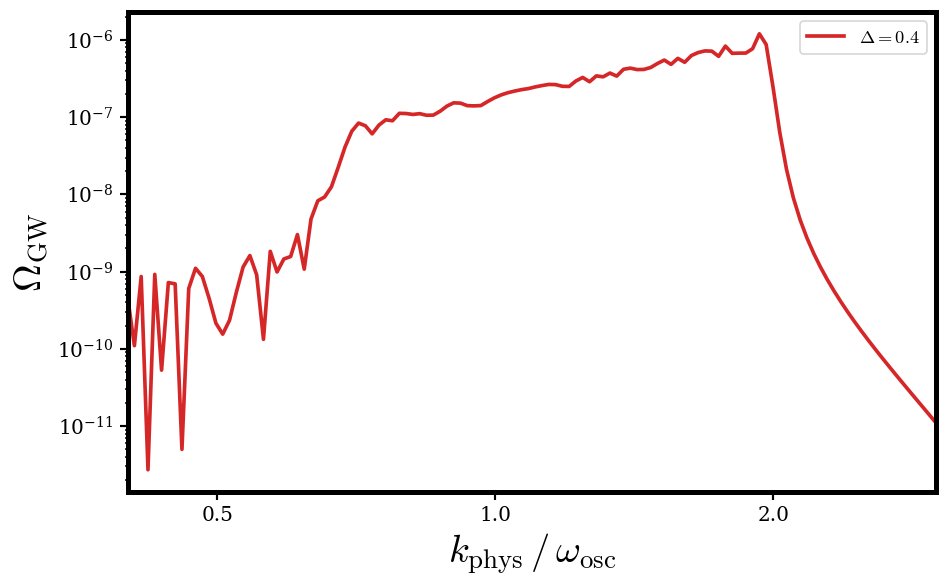

In [95]:
from matplotlib.ticker import ScalarFormatter, FixedLocator

fig, ax = plt.subplots(figsize=(8, 5))

for Delta_p, color in zip(P6_DELTAS, P6_COLORS):
    res = p6_results[Delta_p]
    ax.loglog(res['k_phys'] / P6_OMEGA_PAPER, res['Omega_GW'],
              color=color, lw=2.2, label=fr"$\Delta = {Delta_p}$")

ax.set_xlabel(r"$k_{\rm phys}\,/\,\omega_{\rm osc}$")
ax.set_ylabel(r"$\Omega_{\rm GW}$")
ax.set_xlim(0.4, 3.0)
ax.xaxis.set_major_locator(FixedLocator([0.5, 1.0, 2.0]))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(fontsize=11, loc='best', frameon=True)

fig.tight_layout()
save_fig(fig, P6_NAME)
plt.show()

## Panel 7 — GW spectrum: GR vs EsGB

Compares the stochastic GW spectrum $\Omega_{\rm GW}(k)$ from one GR run and one EsGB run,
using the semi-analytic pipeline in `bssn.GWSignal`. Each run is loaded with `OscillonRun`,
which extracts $(A,\, R,\, \omega_{\rm source},\, H_0)$ plus the dominant Fourier harmonics
of $\phi^2$. The spectra are plotted vs $k_{\rm phys}/\omega_{\rm source}$ in log-log space
with vertical lines marking the Gaussian UV cutoffs $k_{\rm phys}/\omega = 2/(\omega R)$
for each run.

In [34]:
### --- Panel 7 selection (edit me) ---
from bssn.GWSignal import (
    Omega_GW,
    OscillonRun,
    background_a_of_t,
    DEFAULT_DELTA,
)

PLOT7_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,13,15,16,18,20],
)

P7_STABLE_WINDOW = (2.0, 3.6)
P7_DELTA    = DEFAULT_DELTA
P7_N_OSC    = 1
P7_N_ANGLES = 20
P7_N_TAU    = 500
P7_SEED     = 42
P7_N_HUBBLE = 3            # number of Hubble times the oscillon lives
P7_N_K      = 200
P7_KMAX_FAC = 3.0          # k_max_phys = P7_KMAX_FAC * (2 / R)

P7_NAME = "GW_spectrum_GR_vs_EsGB"

# Build an OscillonRun for every selected key, re-using the run_dir already
# discovered by the top-of-notebook loader.
p7_runs = {}
for k in PLOT7_KEYS:
    d = all_runs[k]
    lgb, mu, beta, amp, width, g2 = k
    is_gr = (lgb == 0.0 and g2 == 0.0)
    if is_gr:
        run_label = "GR"
    elif lgb != 0.0 and g2 != 0.0:
        run_label = rf"$\lambda_{{\rm GB}}={lgb:g},\ g_2={g2:g}$"
    elif lgb != 0.0:
        run_label = rf"$\lambda_{{\rm GB}}={lgb:g}$"
    else:
        run_label = rf"$g_2={g2:g}$"
    run = OscillonRun(d["run_dir"], label=run_label,
                      stable_window=P7_STABLE_WINDOW)
    _ = run.extract_all(verbose=False)
    p7_runs[k] = run

# Backwards-compat aliases so the source / field power-spectrum cells above
# can keep reusing Panel 7's loaded runs.
_gr_keys   = [k for k in PLOT7_KEYS if (k[0] == 0.0 and k[5] == 0.0)]
_esgb_keys = [k for k in PLOT7_KEYS if not (k[0] == 0.0 and k[5] == 0.0)]
if _gr_keys:
    p7_gr_run = p7_runs[_gr_keys[0]]
if _esgb_keys:
    p7_esgb_run = p7_runs[_esgb_keys[0]]

print(f"{len(PLOT7_KEYS)} run(s) selected for Panel 7:")
for k, run in p7_runs.items():
    print(f"  {k}  A={run.A:.4f}, R={run.R:.3f}, "
          f"omega_s={run.omega_source:.4f}, H0={run.H0:.4e}")

18 run(s) selected for Panel 7:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  A=0.1749, R=12.400, omega_s=0.0292, H0=5.3503e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 1.0)  A=0.1887, R=11.399, omega_s=0.0389, H0=5.3504e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 2.0)  A=0.1921, R=11.003, omega_s=0.0389, H0=5.3505e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 3.0)  A=0.1984, R=10.640, omega_s=0.0389, H0=5.3507e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 4.0)  A=0.2123, R=10.225, omega_s=0.0487, H0=5.3508e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 5.0)  A=0.2170, R=10.241, omega_s=0.0487, H0=5.3509e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 6.0)  A=0.2245, R=9.893, omega_s=0.0487, H0=5.3510e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 7.0)  A=0.2316, R=9.859, omega_s=0.0584, H0=5.3511e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 8.0)  A=0.2374, R=9.743, omega_s=0.0584, H0=5.3511e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 9.0)  A=0.2439, R=9.503, omega_s=0.0681, H0=5.3512e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 10.0)  A=0.2456, R=9.521, omega_s=0.0680, H0=5.3741e-03
  (0.0, 0.08, 0

Running spectrum for GR  (omega*R=0.362, a_f=3.12) ...
Running spectrum for $g_2=1$  (omega*R=0.444, a_f=3.12) ...
Running spectrum for $g_2=2$  (omega*R=0.428, a_f=3.12) ...
Running spectrum for $g_2=3$  (omega*R=0.414, a_f=3.12) ...
Running spectrum for $g_2=4$  (omega*R=0.498, a_f=3.12) ...
Running spectrum for $g_2=5$  (omega*R=0.498, a_f=3.12) ...
Running spectrum for $g_2=6$  (omega*R=0.481, a_f=3.12) ...
Running spectrum for $g_2=7$  (omega*R=0.576, a_f=3.12) ...
Running spectrum for $g_2=8$  (omega*R=0.569, a_f=3.12) ...
Running spectrum for $g_2=9$  (omega*R=0.647, a_f=3.12) ...
Running spectrum for $g_2=10$  (omega*R=0.648, a_f=3.12) ...
Running spectrum for $g_2=11$  (omega*R=0.631, a_f=3.12) ...
Running spectrum for $g_2=12$  (omega*R=0.715, a_f=3.12) ...
Running spectrum for $g_2=13$  (omega*R=0.699, a_f=3.12) ...
Running spectrum for $g_2=15$  (omega*R=0.757, a_f=3.12) ...
Running spectrum for $g_2=16$  (omega*R=7.535, a_f=3.12) ...
Running spectrum for $g_2=18$  (omega*R

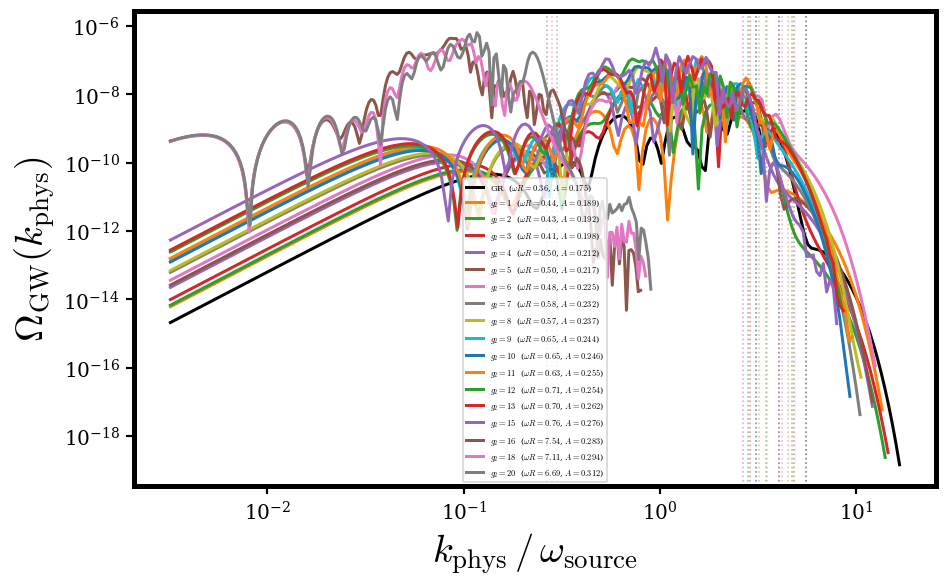


  GR: peak k/omega = 2.847,  Omega_max = 3.631e-09
  $g_2=1$: peak k/omega = 1.464,  Omega_max = 1.426e-08
  $g_2=2$: peak k/omega = 0.647,  Omega_max = 1.030e-08
  $g_2=3$: peak k/omega = 1.247,  Omega_max = 2.301e-08
  $g_2=4$: peak k/omega = 1.726,  Omega_max = 2.956e-08
  $g_2=5$: peak k/omega = 0.819,  Omega_max = 2.877e-08
  $g_2=6$: peak k/omega = 1.075,  Omega_max = 5.300e-08
  $g_2=7$: peak k/omega = 1.608,  Omega_max = 7.447e-08
  $g_2=8$: peak k/omega = 0.780,  Omega_max = 6.531e-08
  $g_2=9$: peak k/omega = 1.724,  Omega_max = 1.135e-07
  $g_2=10$: peak k/omega = 0.774,  Omega_max = 6.679e-08
  $g_2=11$: peak k/omega = 1.625,  Omega_max = 1.289e-07
  $g_2=12$: peak k/omega = 0.723,  Omega_max = 1.099e-07
  $g_2=13$: peak k/omega = 1.385,  Omega_max = 1.310e-07
  $g_2=15$: peak k/omega = 0.952,  Omega_max = 2.286e-07
  $g_2=16$: peak k/omega = 0.087,  Omega_max = 4.385e-07
  $g_2=18$: peak k/omega = 0.098,  Omega_max = 4.118e-07
  $g_2=20$: peak k/omega = 0.117,  Omega_max 

In [ ]:
# Panel 7 plot — GW spectrum for every run in PLOT7_KEYS, overlaid.

from matplotlib import cm

def _p7_params(run):
    return dict(A=run.A, R=run.R,
                omega_source=run.omega_source, H0=run.H0, w=0.0)

def _p7_fourier_modes(run):
    """Normalize raw FFT peaks so the dominant mode has the physical field amplitude."""
    peaks  = run.harmonics
    A_phys = run.A
    p_dom  = float(peaks[0, 1])
    return [(float(omega_n),
             float(A_phys * np.sqrt(float(power_n) / p_dom)),
             0.0)
            for omega_n, power_n in peaks]

def _p7_a_final(H0, tau_end, w=0.0, n=5000):
    t = np.linspace(0.0, tau_end, n)
    return float(background_a_of_t(t, w, H0)[-1])

def _p7_color(idx, key):
    """GR -> black; everything else cycles through tab10 in selection order."""
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "k"
    return cm.tab10(idx % 10)


if len(PLOT7_KEYS) == 0:
    print("No keys selected for Panel 7.")
else:
    p7_results = {}
    fig, ax = plt.subplots(figsize=(9, 5))

    skipped = []
    for idx, k in enumerate(PLOT7_KEYS):
        run    = p7_runs[k]
        params = _p7_params(run)

        # Guard against runs where OscillonRun couldn't extract a usable
        # background (typically H0=0 means no finite, positive H = -<K>/3
        # was found inside the stable window for K_avg).
        bad = [name for name in ("A", "R", "omega_source", "H0")
               if not (np.isfinite(params[name]) and params[name] > 0.0)]
        if bad:
            print(f"  [skip] {run.label}  {k}  -> non-positive/NaN "
                  f"{', '.join(f'{n}={params[n]}' for n in bad)}")
            skipped.append(k)
            continue

        modes  = _p7_fourier_modes(run)
        tau_w  = (0.0, P7_N_HUBBLE / params["H0"])
        a_f    = _p7_a_final(params["H0"], tau_w[1])
        oR     = params["omega_source"] * params["R"]
        color  = _p7_color(idx, k)

        k_max_phys = P7_KMAX_FAC * (2.0 / params["R"])
        k_grid = np.logspace(
            np.log10(0.01 * params["omega_source"]),
            np.log10(k_max_phys * a_f),
            P7_N_K,
        )

        print(f"Running spectrum for {run.label}  "
              f"(omega*R={oR:.3f}, a_f={a_f:.2f}) ...")
        res = Omega_GW(
            **params,
            Delta         = P7_DELTA,
            N             = P7_N_OSC,
            n_angles      = P7_N_ANGLES,
            n_tau         = P7_N_TAU,
            k_grid        = k_grid,
            tau_window    = tau_w,
            seed          = P7_SEED,
            harmonics     = "fourier",
            fourier_modes = modes,
        )
        p7_results[k] = dict(res=res, oR=oR, a_f=a_f, params=params, color=color)

        x = res["k_phys"] / params["omega_source"]
        ax.loglog(x, res["Omega_GW"], color=color, lw=1.8,
                  label=rf"{run.label}  ($\omega R={oR:.2f}$, $A={params['A']:.3f}$)")
        # UV cutoff line per run; unlabeled to keep the legend clean.
        ax.axvline(2.0 / oR, color=color, ls=":", lw=1.0, alpha=0.5)

    ax.set_xlabel(r"$k_{\rm phys}\,/\,\omega_{\rm source}$")
    ax.set_ylabel(r"$\Omega_{\rm GW}(k_{\rm phys})$")
    #ax.set_title(rf"GW spectrum  "rf"($\Delta={P7_DELTA}$, $N_H={P7_N_HUBBLE:.0f}$, Fourier harmonics)")
    #ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=5)

    fig.tight_layout()
    save_fig(fig, P7_NAME)
    plt.show()

    print()
    for k, r in p7_results.items():
        lbl = p7_runs[k].label
        print(f"  {lbl}: peak k/omega = "
              f"{r['res']['peak_k'] / r['params']['omega_source']:.3f},  "
              f"Omega_max = {r['res']['Omega_GW'].max():.3e}")
    if skipped:
        print(f"\n{len(skipped)} run(s) skipped due to bad extracted background:")
        for k in skipped:
            print(f"  {k}  -> {p7_runs[k].run_dir}")

  saved GW_peak_k_vs_g2.pdf and GW_peak_k_vs_g2.png


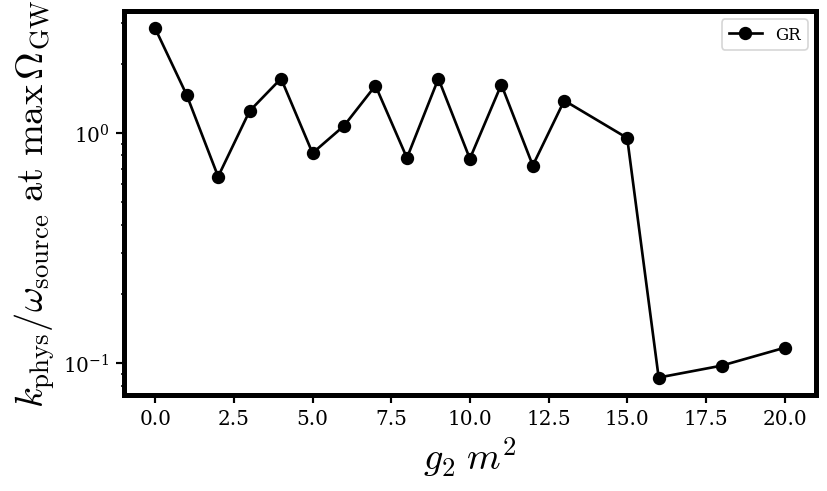

In [36]:
# Panel 7b — peak location k_phys / omega_source at max(Omega_GW) as a function of g2.
# Uses p7_results from the Panel 7 plot cell above. One curve per lambda_GB.
from collections import defaultdict

P7B_NAME = "GW_peak_k_vs_g2"

if not p7_results:
    print("No spectra in p7_results — run the Panel 7 plot cell first.")
else:
    g2_groups = defaultdict(list)
    for k, r in p7_results.items():
        lgb, mu, beta, amp, width, g2 = k
        x_peak = float(r["res"]["peak_k"] / r["params"]["omega_source"])
        g2_groups[lgb].append((g2, x_peak))

    fig, ax = plt.subplots(figsize=(7, 4.2))
    for lgb in sorted(g2_groups):
        pts = sorted(g2_groups[lgb], key=lambda p: p[0])
        xs  = np.array([p[0] for p in pts])
        ys  = np.array([p[1] for p in pts])
        label = "GR" if lgb == 0.0 else rf"$\lambda_{{\rm GB}}={lgb:g}$"
        color = "k"  if lgb == 0.0 else None
        ax.plot(xs, ys, marker="o", lw=1.6, ms=7, color=color, label=label)

    ax.set_xlabel(r"$g_2\;m^2$")
    ax.set_ylabel(
        r"$k_{\rm phys}/\omega_{\rm source}\ \mathrm{at}\ \max\,\Omega_{\rm GW}$"
    )
    ax.set_yscale("log")
    ax.legend(fontsize=10)
    fig.tight_layout()
    save_fig(fig, P7B_NAME)
    plt.show()

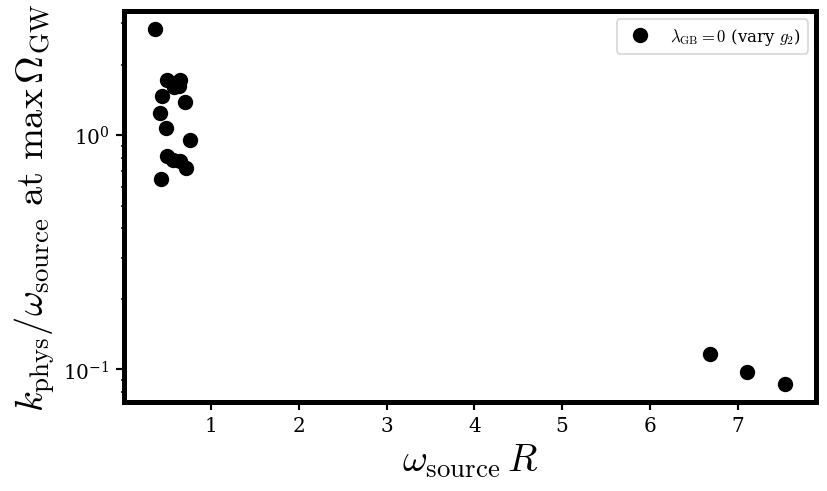

In [37]:
# Panel 7d — peak location k_phys / omega_source at max(Omega_GW) vs omega*R.
# Distinguish runs by which coupling is non-zero:
#   black circles : lambda_GB == 0          (g2-only, includes GR baseline at g2=0)
#   green triangles: g2 == 0  and lambda_GB != 0  (lambda-only, excludes GR)
#   red squares  : lambda_GB != 0 and g2 != 0    (both couplings non-zero)
P7D_NAME = "GW_peak_k_vs_omegaR"

if not p7_results:
    print("No spectra in p7_results — run the Panel 7 plot cell first.")
else:
    cats = {
        "g2_only":   dict(xs=[], ys=[], color="k", marker="o",
                          label=r"$\lambda_{\rm GB}=0$ (vary $g_2$)"),
        "lgb_only":  dict(xs=[], ys=[], color="green", marker="^",
                          label=r"$g_2=0$ (vary $\lambda_{\rm GB}$)"),
        "both":      dict(xs=[], ys=[], color="red", marker="s",
                          label=r"$\lambda_{\rm GB}\neq 0$ and $g_2\neq 0$"),
    }
    for k, r in p7_results.items():
        lgb, mu, beta, amp, width, g2 = k
        x_val = float(r["oR"])
        y_val = float(r["res"]["peak_k"] / r["params"]["omega_source"])
        if lgb == 0.0:
            tag = "g2_only"
        elif g2 == 0.0:
            tag = "lgb_only"
        else:
            tag = "both"
        cats[tag]["xs"].append(x_val)
        cats[tag]["ys"].append(y_val)

    fig, ax = plt.subplots(figsize=(7, 4.2))
    for tag, c in cats.items():
        if not c["xs"]:
            continue
        order = np.argsort(c["xs"])
        xs = np.asarray(c["xs"])[order]
        ys = np.asarray(c["ys"])[order]
        ax.plot(xs, ys, marker=c["marker"], color=c["color"], ls="none",
                ms=8, mew=1.2, mfc=c["color"], mec="k", label=c["label"])

    ax.set_xlabel(r"$\omega_{\rm source}\, R$")
    ax.set_ylabel(
        r"$k_{\rm phys}/\omega_{\rm source}\ \mathrm{at}\ \max\,\Omega_{\rm GW}$"
    )
    ax.set_yscale("log")
    ax.legend(fontsize=10, loc="best")
    fig.tight_layout()
    #save_fig(fig, P7D_NAME)
    plt.show()